<center>
 <p>116 Advanced Statistics</p>
 <h1></h1>
 <h1>Lecture 04: Generalized linear models</h1>
 <p>----</p>
 <p>Prof. Jochen Braun Ph.D.</p>
 <p>Institute of Biology</p>
 <p>Otto-von-Guericke University Magdeburg</p>
 <p>----</p>
 <p>Textbook:</p>
 <p> B Efron & T Hastie (2016) Computer Age Statistical Inference, </p>
 <p> Cambridge University Press.</p>
</center>

# **Abstract:**

Regression analysis, either in its classical in modern formulations, exploits the covariance of different variables x and y and attempts to establish some sort of geometrical relation ship. Regression is the statistician’s most powerful tool for relating “other” variables to a variable of primary interest

We **revisit linear regression** and present its more general formulation for multiple independent variables x and one dependent variable y.  **Ridge regression** can be useful when the number of x-variables get's large.

Generalized linear models take advantage of **known distributions** from the exponential family. They provide exact maximum likelihood results even when our observations are **not normally distributed**.

**Logistic regression** is the most intuitive generalization and covers situations with **binomially distributed observations** (e.g., counts of successes and failures)

The same principle works for other distributions from the exponential family, such as **Gamma distributions** or **Poisson distributions**.



# **Overview:**

**1. Linear regression**

**2. Ridge regression**

**3. Logistic regression**

**4. Generalized linear models**

**5. Gamma regression**

**6. Poisson regression**



# **1. Linear regression**

We make scalar observations $y_n$ over $N$ trials, and collect these observations in $N$-dimensional vector ${\bf y}\,(N\times 1)$. We assume that these observations are linarly modulated by experimental factors under our control.
Specifically, we devise a **design matrix**, denoted ${\bf X}\,(N\times P)$, that structures our experiment such that the experimental factors occur equally (or comparably) often in different combinations.

<br>

Our linear model is

$$
{\bf y} = {\bf X} \cdot \boldsymbol\beta + \boldsymbol\epsilon, \qquad\qquad \boldsymbol\epsilon \sim \mathscr{N}(0,\sigma^2)
$$

where $\boldsymbol\beta = \{ \beta_1, \ldots , \beta_P\}$ is a $(P\times 1)$ vector of unknown parameters and $\boldsymbol\epsilon = \{ \epsilon_1, \ldots , \epsilon_N\}$ is independent random noise with mean $0$ and variance $\sigma^2$.

<br>

The design matrix ${\bf X}$ must be chosen in such a way that the inner product matrix ${\bf S}$ is invertible!

$$
{\bf S} = {\bf X}^T \cdot {\bf X}, \qquad\qquad {\bf S}^{-1} \cdot {\bf S} = {\bf I}
$$

<br>

The least-squares estimate, which goes back to Gauss and Legendre in the early 18th century, is the parameter vector that minimizes the total sum of squared errors

$$
\hat {\,\boldsymbol\beta} = \mathrm{arg\,\, min}_{\boldsymbol\beta} \lVert {\bf y} - {\bf X} \cdot \boldsymbol\beta \rVert^2
$$

<br>

In other words, we wish to minimize the objective function

$$
\mathscr{L}(\boldsymbol\beta) = \lVert {\bf y} - {\bf X} \cdot \boldsymbol\beta \rVert^2 = \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right)^T \cdot \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right)
$$

with respect to $\boldsymbol\beta$. Note that we can expand the sum of squares in terms of a dot product $(1\times N)\cdot(N\times 1)$

<br>

Setting the derivative with respect to $\beta$ to zero

$$\begin{eqnarray}
0 \stackrel{!}{=} \frac{\partial \mathscr{L}(\boldsymbol\beta)}{\partial\boldsymbol\beta}&=& \frac{\partial }{\partial\boldsymbol\beta} \left[ \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right)^T \cdot \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right) \right] =
\\
&=& \frac{\partial }{\partial\boldsymbol\beta} \left[{\bf y}^T \cdot {\bf y} - 2 \boldsymbol\beta^T \cdot {\bf X}^T \cdot {\bf y} + {\bf \boldsymbol\beta}^T {\bf X}^T \cdot {\bf X} \cdot {\boldsymbol\beta} \right] =
\\
&=& -2 {\bf X}^T {\bf y} + 2 {\bf X}^T \cdot {\bf X} \cdot \boldsymbol\beta
\end{eqnarray}$$

and solving for $\boldsymbol\beta$

$$
\hat {\,\boldsymbol\beta} = \left({\bf X}^T \cdot {\bf X} \right)^{-1} \cdot {\bf X}^T \cdot {\bf y} = {\bf S}^{-1} \cdot {\bf X}^T \cdot {\bf y},\qquad\qquad {\bf S} \equiv {\bf X}^T \cdot {\bf X}
$$

These are called the **normal equations** and ${\bf S}$ is the $(P\times P)$ **inner product matrix**.

<br>

$\hat {\,\boldsymbol\beta}$ is an unbiased estimate for $\boldsymbol\beta$ and has the covariance matrix ${\bf S}^{-1} \sigma^2$

$$
\hat {\boldsymbol\beta} \sim \mathscr{N}\left(\boldsymbol\beta,{\bf S}^{-1} \sigma^2 \right)
$$

Thus, the $i$-th diagonal element of the covariance matrix estimates the variance of the individual $\beta_i$.

In [ ]:
from inspect import signature
# @title Linear regression {"vertical-output":true,"display-mode":"form"}
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from itertools import combinations, permutations
from scipy.linalg import inv
from scipy.linalg import svd
from scipy.linalg import lstsq

def MakeDesignMatrix( Nrepeat, Pparam, Kcombo ):

    # all permutations of choosing K from P
    result = []
    for combo in combinations(range(Pparam-1), Kcombo):
        result.extend(permutations(combo))

    # number of permutations
    Ncombo = np.shape(result)[0]

    # design matrix of zeros and ones
    X = np.zeros((Ncombo, Pparam-1))

    for i in range(Ncombo):
        for j in range(Kcombo):
            k = result[i][j]
            X[i,k] = 1

    # add a row of all zeros
    X = np.vstack([np.zeros((1,Pparam-1)), X])

    # replicate design matrix
    X = np.tile(X, (Nrepeat, 1))
    Ntrial = np.shape(X)[0]

    # shuffle design matrix
    ix = np.random.permutation(Ntrial)
    X = X[ix,:]

    # add constant factor in first column

    X = np.hstack([np.ones((Ntrial,1)), X])

    return Ntrial, X

def ShowDesignMatrixAndY( axs, X, Y ):

    # Get colors from a perceptually uniform colormap
    colors = plt.get_cmap('tab10').colors # Up to 10 good distinct colors

    # 'tab10', 'tab20', 'Set3' – designed for categories

    deltaX  = 1.0;
    deltaY  = 1.0;
    dx      = 0.45*deltaX*np.array([-1,1,1,-1]);
    dy      = 0.45*deltaY*np.array([1,1,-1,-1]);

    ymin    = np.min(Y);
    ymax    = np.max(Y);
    yrange  = 5
    yscale  = yrange*(Y-ymin)/(ymax-ymin);
    y0scale = yrange*(0-ymin)/(ymax-ymin);

    for i in range(np.shape(X)[0]):
        for j in range(np.shape(X)[1]):
            if X[i,j] == 1:
                axs.fill( 1+deltaX*j+dx, deltaY*i+dy, facecolor=colors[j], edgecolor='black' )

        x0 = 1+deltaX*np.shape(X)[1]
        y0 = deltaY*i
        x1 = x0 + y0scale
        x2 = x0 + yscale[i]

        axs.plot([x1, x2], [y0,y0], 'k-', linewidth=0.5 )
        axs.plot( x1, y0, 'k.', markersize=2 )

    axs.set_xlabel('Params')
    axs.set_ylabel('Trials')
    axs.set_xticks(np.arange(1,np.shape(X)[1]+1,1))
    axs.set_box_aspect(5/1)
    axs.set_xlim([0.5,np.shape(X)[1]+0.5+yrange])
    axs.set_ylim([0.5,np.shape(X)[0]+0.5],)
    axs.set_title('Design matrix & data', fontsize=18);

    return;

def ShowInnerProductMatrix( axs, X ):

    IPM = X.T@X

    axs.imshow(IPM, cmap='hot', interpolation='nearest')
    axs.set_box_aspect(1/1)
    axs.set_title('Inner product matrix', fontsize=18);

    return;


def plot_linear_regression(Pparam=6, Kcombo=2, Nrepeat=10, Sigma=0.5):
    """(Slide-25)"""

    (Ntrial, X) = MakeDesignMatrix( Nrepeat, Pparam, Kcombo );

    #ShowDesignMatrix( X )


    TrueBeta = np.random.uniform(-10,10,Pparam)

    # generate observations from TrueBeta

    Y = np.dot( X, TrueBeta ) + Sigma*np.random.randn(Ntrial)

    # inner product of design matrix
    S = np.dot(X.T, X)


    # least squares estimate
    EstBeta = np.dot( np.linalg.inv(S), np.dot(X.T, Y) )


    # residual variance
    VarBeta = Sigma**2 * np.diag(np.linalg.inv(S))

    # Plot results
    fig, axs = plt.subplots( 1, 1, figsize=(8,25))

    ShowDesignMatrixAndY( axs, X, Y )

    plt.show()

    # inner product matrix and fitted parameters

    fig, axs = plt.subplots( 1, 2, figsize=(8,5))

    ShowInnerProductMatrix( axs[0], X )

    axs[1].bar( np.arange(0,Pparam), EstBeta, yerr=np.sqrt(VarBeta), capsize=5, color='skyblue', edgecolor='black')
    for p in range(0,Pparam,1):
        axs[1].plot( [p-0.5,p+0.5], [TrueBeta[p],TrueBeta[p]], 'r:', linewidth=2 );

    axs[1].set_xlabel('params')
    axs[1].set_ylabel('beta value')
    axs[1].set_box_aspect(1/1)
    axs[1].set_title('Fitted params', fontsize=18);

    plt.tight_layout()
    plt.show()

# Creating sliders for concentrations and charge
interact(plot_linear_regression, Pparam=(2,12,1), Kcombo = (1,4,1), Nrepeat = (2,10,1) )


interactive(children=(IntSlider(value=6, description='Pparam', max=12, min=2), IntSlider(value=2, description=…

<function __main__.plot_linear_regression(Pparam=6, Kcombo=2, Nrepeat=10, Sigma=0.5)>

(6, 6)
True parameters: [ 2.   1.5 -0.5  0.8 -1.2  0.3]
Estimated parameters (scikit-learn): [ 1.85387526  1.55421281 -0.36448897  0.77870591 -1.03925278  0.29276855]
Estimated parameters (manual): [ 1.85387526  1.55421281 -0.36448897  0.77870591 -1.03925278  0.29276855]
Mean Squared Error: 0.8033


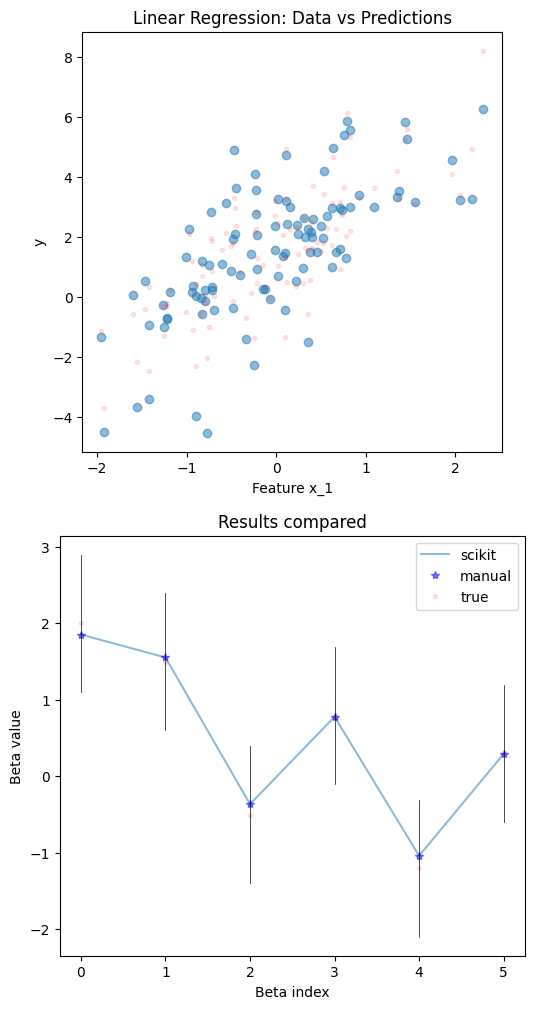

In [ ]:
# @title Linear regression, alternative code from Grok {"vertical-output":true,"display-mode":"form"}
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from scipy.linalg import inv
from scipy.linalg import svd
from scipy.linalg import lstsq

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_samples = 100 # Number of trials
n_features = 5 # Number of features (excluding intercept)
sigma = 1.0 # Noise standard deviation

# Step 1: Generate synthetic data
# True parameters:  [intercept, beta_1, beta_2, ..., beta_5],
beta_true = np.array([2, 1.5, -0.5, 0.8, -1.2, 0.3])

# parameter indices
nparam = len(beta_true);
prange = np.arange(nparam)

# Generate feature matrix X (n_samples x n_features)
X = np.random.randn(n_samples, n_features)

# Generate true response y = X * beta[1:] + beta[0] + noise
y_true = X @ beta_true[1:] + beta_true[0]
y = y_true + np.random.randn(n_samples) * sigma

# Step 2: Fit linear regression using scikit-learn
model = LinearRegression()
model.fit(X, y)

# Extract estimated parameters
beta_scikit = np.concatenate(([model.intercept_], model.coef_))

# Step 3: Manual computation (for illustration)
# Add column of ones to X for intercept
X_with_intercept = np.hstack([np.ones((n_samples, 1)), X])

# Normal equation: beta_hat = (X^T X)^(-1) X^T y
S = X_with_intercept.T @ X_with_intercept
Sinv = np.linalg.inv(S)
print( np.shape(Sinv) )
beta_manual = Sinv @ X_with_intercept.T @ y

# Step 4: Compute Mean Squared Error
y_pred = model.predict(X)
mse = np.mean((y - y_pred) ** 2)
ser = np.sqrt( mse )

# Step 5: Print results
print("True parameters:", beta_true)
print("Estimated parameters (scikit-learn):", beta_scikit)
print("Estimated parameters (manual):", beta_manual)
print(f"Mean Squared Error: {mse:.4f}")

# Step 6: Visualize predictions vs true values (for one feature)
# Plot results
fig, axs = plt.subplots( 2, 1, figsize=(6,12))

axs[0].scatter(X[:, 0], y, alpha=0.5, label="Data")
axs[0].plot(X[:, 0], y_pred, 'r.', alpha=0.1, label="Predictions")
axs[0].set_xlabel("Feature x_1")
axs[0].set_ylabel("y")
axs[0].set_box_aspect(1/1)
axs[0].set_title("Linear Regression: Data vs Predictions")

#Step 7: plot regression results
axs[1].plot( prange, beta_scikit, alpha=0.5, label="scikit")
axs[1].plot( prange, beta_manual, 'b*', alpha=0.5, label="manual")
axs[1].plot( prange, beta_true, 'r.', alpha=0.1, label="true")
for p in prange:
    axs[1].plot( [p,p], [beta_true[p]-ser,beta_true[p]+ser], 'k-', linewidth=0.5 );
axs[1].set_xlabel("Beta index")
axs[1].set_ylabel("Beta value")
axs[0].set_box_aspect(1/1)
axs[1].set_title("Results compared")

plt.legend()
plt.show()

# **2. Ridge regression**

When the number of predictors is large, we are often looking for a few interesting predictor variables in a haystack of uninteresting ones. The prior belief is that most of the $\boldsymbol\beta$ values lie near zero. We can take this into account with **ridge regression**, which biases the maximum likelihood estimates $\hat {\,\boldsymbol\beta}$ toward zero.

<br>

The downside is that ridge regression attenuates predictors that are genuinely outstanding (in a positive or negative sense). So if we do find some particularly strong predictors, their impact will likely be **underestimated**.

<br>

Specifically, we minimize the modified cost function

$$\begin{eqnarray}
\mathscr{L}(\boldsymbol\beta,\lambda) &=& \lVert {\bf y} - {\bf X} \cdot \boldsymbol\beta \rVert^2 + \lambda \lVert {\boldsymbol\beta}^2 \rVert =
\\
\\
&=& \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right)^T \cdot \left({\bf y} - {\bf X} \cdot \boldsymbol\beta \right) + \lambda \,\, {\boldsymbol\beta}^T \cdot \boldsymbol\beta
\end{eqnarray}$$

where $\lambda$ is the **ridge parameter**.

Setting the derivative with respect to $\boldsymbol\beta$ to zero and solving for $\boldsymbol\beta$ now produces

$$\begin{eqnarray}
0
&=& -2 \, {\bf X}^T {\bf y} + 2 \, {\bf X}^T \cdot {\bf X} \cdot \boldsymbol\beta + 2 \, \lambda \, \boldsymbol\beta
\\
\\
\hat {\,\boldsymbol\beta}(\lambda) &=& \left({\bf
S} + \lambda \, {\bf I} \right)^{-1} \cdot {\bf X}^T \cdot {\bf y}
\end{eqnarray}$$

where ${\bf S} = {\bf X}^T \cdot {\bf X}$ is the inner product matrix.

<br>



Comparing $\hat {\,\boldsymbol\beta}(\lambda)$ to the underlying $\boldsymbol\beta = {\bf S} \cdot {\bf X}^T \cdot {\bf y}$, we see that

$$
\hat {\,\boldsymbol\beta}(\lambda) = \left({\bf
S} + \lambda \, {\bf I} \right)^{-1} \cdot {\bf S}^{-1} \cdot {\beta}
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/RidgeRegressionIllu.png" width="400">

<br>

This corresponds to the conditional expectation of $\hat{\,\boldsymbol\beta}(\lambda)$, given $\boldsymbol\beta$, assuming normally distributed noise and

$$
\hat{\,\boldsymbol\beta}(\lambda) \sim \mathscr{N}(\boldsymbol\beta, \sigma^2 \, {\bf I}), \qquad\qquad \boldsymbol\beta \sim \mathscr{N}\left(0, \frac{\sigma^2}{\lambda}\, {\bf I}\right)
$$

Thus, ridge regression amounts to a prior belief that the $\boldsymbol\beta$ values lie near zero.




# Practicalities

As our predictor variables may come on different scales, we normalize each column of the design matrix $\bf X$ to zero mean and unit sum of squares. This ensures that all $\beta$ values are on comparable scales. In addition, we subtract the mean from our observations $\bf y$

$$
\sum_i X_{ij} = 0, \qquad \sum_i X_{ij}^2 = 1, \qquad \forall j
$$
$$
\sum_i y_i = 0
$$

$$
S_{jk} = \sum_i X_{ij} X_{ik}, \qquad S_{jj} = 1
$$

<br>

With these normalizations, the covariance matrix of $\hat {\,\boldsymbol\beta}$ follows from

$$\begin{eqnarray}
\hat {\,\boldsymbol\beta} &=& \left({\bf S} + \lambda \, {\bf I} \right)^{-1} \cdot {\bf X}^T {\bf y}
\end{eqnarray}$$

as

$$
\mathrm{Cov}_\lambda = \left({\bf S} + \lambda \, {\bf I} \right)^{-1} \cdot {\bf S} \cdot \left({\bf S} + \lambda \, {\bf I} \right)^{-1}
$$

The diagonal elements of this matrix provide the variance of our estimate $\hat{\boldsymbol\beta}(\lambda)$







# Diabetes example

In a diabetes study, 442 patients were assessed with respect to *age, sex, bmi* (body mass index), *map* (mean arterial blood pressure), and six blood serum measurements, *tc, ldl, hdl, tch, ltg, glu*. Additionally, disease progression *prog* was established one year after these measurements. We wish to know the comparative predictiveness of these ten measures for disease progression.

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/diabetes_study_table.png" width="600">





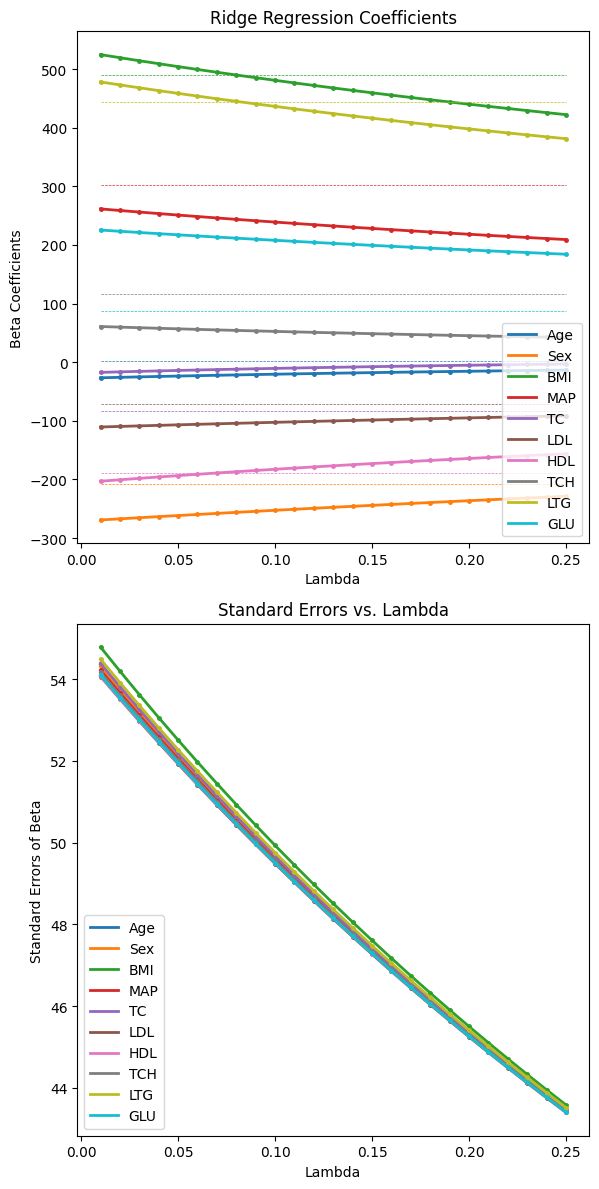

Beta (true): [   1.3 -207.2  489.7  301.8  -83.5  -70.8 -188.7  115.7  443.8   86.7]
Beta (SVD): [ -27.45750928 -271.09149264  529.97743612  264.15444782  -18.33142403
 -111.53530974 -205.64703198   61.84849271  483.07805804  227.43801714]


In [ ]:
# @title Ridge regression, diabetes example {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt

# Define data and observations

def DataAndObservations():

    # age, sex, bmi, map, tc, ldl, hdl, tch, ltg, tlu, prog

    X = np.array([
        [67, 1, 24.2, 90, 166, 94.8, 44, 3, 1.64, 84, -2.80],
        [34, 1, 20.6, 96, 143, 99.1, 62, 3, 1.67, 85, -35.86],
        [51, 1, 26.0, 87, 144, 79.7, 48, 5, 1.98, 87, 32.24],
        [54, 1, 21.1, 81, 164, 115.4, 47, 3, 1.71, 85, -34.65],
        [40, 1, 26.2, 94, 197, 124.1, 42, 4, 1.93, 76, 23.10],
        [40, 1, 24.4, 95, 171, 117.0, 64, 4, 1.63, 73, -109.55],
        [44, 0, 29.1, 93, 147, 109.9, 59, 3, 1.83, 67, -70.42],
        [31, 0, 19.4, 86, 189, 86.1, 61, 2, 1.74, 72, -90.58],
        [71, 0, 24.8, 90, 167, 64.9, 53, 4, 2.01, 74, 98.16],
        [45, 1, 26.3, 99, 188, 90.2, 29, 4, 1.91, 93, 7.63],
        [31, 0, 21.9, 93, 157, 129.2, 76, 3, 1.96, 88, -18.68],
        [39, 0, 25.3, 91, 173, 115.3, 41, 5, 1.70, 86, -29.06],
        [71, 0, 27.6, 88, 139, 92.0, 57, 4, 1.69, 91, -80.64],
        [12, 0, 20.4, 90, 151, 80.1, 69, 3, 1.68, 87, 7.70],
        [54, 0, 27.5, 92, 184, 78.3, 52, 3, 2.10, 77, 79.23],
        [60, 0, 31.1, 94, 181, 81.5, 49, 3, 2.02, 70, 45.08],
        [58, 1, 25.5, 87, 195, 96.0, 59, 2, 1.94, 85, -65.88],
        [20, 1, 17.6, 86, 180, 92.9, 46, 6, 1.77, 93, -6.09],
        [77, 1, 23.7, 92, 173, 83.6, 42, 1, 1.71, 66, -128.83],
        [39, 1, 32.5, 93, 185, 77.1, 24, 4, 2.09, 71, 49.46],
        [50, 0, 22.1, 92, 187, 100.1, 48, 4, 2.00, 66, 24.90],
        [33, 1, 29.7, 88, 194, 106.3, 52, 2, 1.71, 73, -78.48],
        [44, 1, 23.8, 81, 204, 97.6, 68, 3, 2.20, 71, -45.94],
        [20, 0, 21.9, 91, 186, 60.7, 59, 4, 1.59, 94, 12.92],
        [38, 0, 25.5, 98, 166, 65.1, 63, 5, 1.97, 74, 92.92],
        [30, 0, 23.9, 104, 140, 110.7, 48, 4, 2.03, 72, 72.59],
        [40, 0, 28.7, 96, 155, 93.5, 67, 4, 1.93, 86, 23.70],
        [51, 1, 23.9, 94, 151, 76.7, 61, 5, 1.73, 90, -12.02],
        [46, 0, 19.2, 95, 157, 154.8, 46, 3, 1.95, 69, -73.34],
        [62, 1, 23.5, 93, 201, 125.9, 51, 3, 1.87, 74, 66.46],
        [47, 0, 20.2, 87, 149, 115.5, 33, 2, 1.94, 74, -37.19],
        [15, 1, 32.0, 88, 184, 101.2, 40, 4, 1.85, 77, -9.39],
        [36, 1, 28.2, 85, 137, 98.4, 55, 3, 2, 79, 35.49],
        [65, 0, 27.7, 91, 163, 148.1, 41, 5, 1.82, 78, 9.04],
        [64, 1, 29.8, 93, 167, 81.0, 48, 4, 1.67, 79, 36.14],
        [80, 1, 25.5, 98, 157, 120.1, 65, 3, 2.07, 82, -20.87],
        [31, 0, 23.7, 89, 191, 113.2, 42, 3, 2.08, 81, 78.05],
        [69, 0, 16.3, 86, 162, 115.1, 49, 3, 2.06, 80, -8.40],
        [48, 1, 31.1, 94, 196, 99.7, 37, 2, 1.62, 87, 3.12],
        [57, 0, 23.5, 83, 155, 141.6, 59, 4, 1.99, 75, -43.16],
        [50, 0, 27.2, 85, 143, 125.8, 57, 3, 1.71, 82, -138.59],
        [52, 1, 25.1, 81, 183, 67.8, 32, 4, 2.07, 81, -73.13],
        [49, 1, 27.2, 93, 211, 108.6, 40, 2, 2.08, 64, 27.99],
        [37, 1, 24.3, 94, 199, 114.5, 44, 4, 2.09, 83, -37.16],
        [22, 1, 22.4, 85, 193, 97.7, 19, 3, 2.23, 75, -116.27],
        [22, 1, 28.2, 91, 183, 105.8, 35, 2, 1.65, 81, 6.86],
        [17, 0, 31.4, 96, 206, 130.5, 41, 3, 1.98, 76, 22.04],
        [36, 1, 19.9, 94, 199, 106.6, 57, 4, 2.19, 89, 48.81],
        [20, 0, 32.6, 90, 162, 139.3, 48, 5, 1.91, 72, 90.40],
        [51, 1, 33.4, 93, 172, 81.5, 37, 5, 1.91, 71, 40.28],
        [62, 0, 28.5, 91, 150, 91.4, 47, 3, 1.78, 75, -21.48],
        [18, 1, 29.5, 84, 166, 95.8, 59, 3, 2.11, 76, -41.20],
        [42, 0, 21.5, 96, 187, 112.1, 49, 7, 1.95, 85, 73.47],
        [35, 0, 28.5, 97, 178, 110.8, 35, 3, 2.12, 78, 70.96],
        [36, 1, 27.0, 94, 147, 122.4, 86, 3, 1.72, 64, 12.91],
        [59, 0, 30.9, 94, 197, 115.0, 53, 4, 1.76, 90, 53.08],
        [40, 0, 30.1, 95, 191, 108.8, 68, 3, 1.91, 77, 89.50],
        [34, 0, 25.2, 94, 195, 117.1, 82, 3, 1.94, 80, 12.73],
        [25, 0, 27.8, 89, 176, 131.3, 65, 2, 1.74, 76, 7.53],
        [46, 1, 28.4, 95, 190, 119.6, 49, 3, 1.97, 83, 65.65],
        [50, 1, 21.6, 95, 180, 65.4, 26, 2, 1.86, 78, -173.32],
        [46, 1, 28.7, 101, 181, 82.2, 32, 4, 2.14, 74, 42.51],
        [51, 0, 24.7, 81, 168, 58.9, 45, 4, 1.92, 75, -28.83],
        [58, 0, 25.6, 82, 161, 143.4, 52, 3, 1.95, 100, -71.88],
        [63, 0, 29.3, 96, 139, 94.1, 72, 3, 1.75, 79, 5.17],
        [34, 0, 27.4, 100, 167, 99.7, 79, 3, 1.61, 76, -53.59],
        [46, 1, 30.8, 94, 155, 62.2, 60, 4, 1.49, 75, 47.63],
        [53, 0, 22.6, 84, 153, 84.5, 35, 3, 2.27, 84, 3.24],
        [46, 0, 23.0, 88, 161, 122.6, 48, 4, 2.01, 77, -94.67],
        [51, 1, 23.8, 99, 178, 77.7, 77, 3, 2.17, 85, 98.46],
        [26, 1, 24.5, 100, 139, 140.4, 51, 4, 1.88, 83, -14.42],
        [56, 1, 26.0, 97, 173, 68.6, 50, 3, 1.63, 79, -98.46],
        [36, 1, 22.3, 82, 162, 74.1, 39, 2, 1.70, 72, -153.56],
        [41, 0, 35.2, 95, 132, 111.1, 54, 4, 1.69, 87, 46.56],
        [80, 1, 27.1, 79, 116, 67.9, 44, 4, 1.48, 86, -25.55],
        [43, 0, 32.2, 94, 189, 46.8, 55, 5, 2.03, 78, -0.73],
        [50, 1, 22.5, 91, 160, 112.7, 64, 4, 1.74, 70, -66.32],
        [20, 0, 21.2, 97, 184, 75.0, 71, 5, 1.96, 95, 23.28],
        [61, 1, 20.8, 91, 175, 90.4, 50, 4, 1.93, 91, 76.48],
        [74, 0, 27.7, 85, 157, 90.8, 80, 6, 1.79, 89, -34.89],
        [24, 1, 27.4, 90, 187, 129.1, 72, 4, 2.14, 79, -31.54],
        [41, 0, 21.7, 91, 187, 105.0, 40, 4, 1.96, 91, -1.66],
        [31, 0, 16.9, 82, 173, 102.9, 70, 4, 1.63, 90, 19.08],
        [18, 1, 19.5, 94, 191, 105.7, 56, 4, 1.89, 82, -73.32],
        [20, 0, 25.4, 86, 178, 56.1, 39, 4, 1.96, 80, -21.25],
        [44, 1, 28.5, 100, 185, 88.0, 65, 5, 1.82, 75, 16.97],
        [45, 1, 32.8, 95, 144, 103.0, 62, 3, 1.97, 76, 48.61],
        [57, 0, 28.3, 89, 193, 93.2, 57, 2, 2.14, 69, 73.08],
        [38, 1, 28.5, 85, 131, 86.0, 52, 5, 1.99, 95, 30.52],
        [39, 1, 24.5, 81, 159, 104.1, 37, 5, 2.11, 87, 63.86],
        [73, 0, 22.2, 98, 183, 45.6, 79, 3, 2.25, 83, 24.22],
        [31, 1, 16.9, 101, 159, 55.1, 66, 4, 2.21, 66, 24.39],
        [30, 0, 26.9, 94, 179, 96.4, 71, 5, 1.97, 90, 62.83],
        [54, 1, 19.6, 88, 182, 62.2, 56, 2, 2.20, 79, -34.54],
        [55, 1, 14.0, 95, 155, 87.9, 45, 4, 1.63, 83, 0.02],
        [44, 0, 30.5, 93, 186, 90.5, 64, 2, 1.91, 89, 80.47],
        [45, 0, 25.0, 94, 175, 94.0, 34, 4, 2.02, 86, 8.40],
        [32, 1, 27.0, 104, 170, 107.8, 56, 4, 1.97, 93, 93.89],
        [67, 0, 20.4, 91, 190, 103.2, 42, 3, 1.86, 67, 10.64],
        [48, 1, 24.4, 93, 165, 119.4, 51, 4, 1.53, 59, -122.93],
        [58, 1, 25.8, 84, 147, 98.0, 58, 3, 1.91, 74, 30.60],
        [65, 1, 34.9, 87, 183, 125.7, 61, 5, 1.68, 82, -77.66],
        [57, 1, 28.1, 99, 185, 119.7, 46, 5, 1.80, 71, 3.14],
        [17, 0, 22.2, 88, 152, 106.4, 47, 3, 2.06, 76, -31.08],
        [64, 1, 24.0, 80, 201, 144.6, 20, 4, 1.75, 78, -56.41],
        [35, 1, 20.5, 96, 145, 99.4, 33, 4, 2.06, 86, -17.53],
        [46, 1, 30.0, 96, 150, 112.6, 75, 5, 1.77, 76, -32.50],
        [48, 0, 23.6, 96, 181, 104.2, 55, 5, 2.26, 78, 96.39],
        [17, 0, 31.0, 98, 122, 130.8, 57, 4, 2.10, 81, 81.69],
        [72, 0, 24.0, 88, 140, 72.8, 35, 4, 1.71, 84, 34.00],
        [50, 1, 24.8, 95, 161, 81.7, 45, 3, 2.04, 73, 50.31],
        [57, 1, 20.6, 90, 195, 94.7, 26, 2, 2.31, 75, 71.01],
        [42, 1, 21.8, 95, 200, 98.7, 31, 5, 1.43, 72, -94.71],
        [54, 1, 30.0, 86, 151, 97.5, 32, 6, 1.82, 68, -20.20],
        [44, 0, 29.7, 94, 155, 90.7, 28, 4, 1.68, 84, 55.46],
        [40, 0, 25.0, 91, 178, 82.7, 34, 4, 1.97, 79, 43.60],
        [64, 1, 30.3, 105, 190, 67.7, 35, 4, 2.07, 85, 165.12],
        [43, 0, 26.4, 91, 225, 65.6, 41, 2, 1.94, 82, 33.74],
        [25, 1, 19.4, 95, 177, 118.9, 65, 3, 1.91, 95, -36.13],
        [55, 1, 21.3, 95, 187, 55.2, 74, 2, 1.97, 75, -35.84],
        [31, 0, 22.0, 89, 160, 108.4, 41, 4, 1.72, 78, -83.30],
        [33, 1, 23.7, 100, 148, 103.1, 54, 4, 1.73, 92, -17.55],
        [35, 1, 26.2, 95, 172, 111.9, 48, 4, 2.05, 89, 59.43],
        [65, 0, 26.1, 99, 175, 77.8, 36, 3, 1.81, 60, 43.79],
        [47, 0, 22.5, 88, 152, 106.9, 38, 2, 2.18, 88, 3.71],
        [24, 1, 26.6, 87, 195, 101.8, 28, 5, 2.09, 93, 125.29],
        [39, 1, 20.9, 96, 200, 119.9, 61, 3, 1.73, 81, -164.69],
        [55, 0, 26.7, 97, 178, 88.2, 50, 4, 1.97, 78, -3.48],
        [41, 1, 17.3, 96, 199, 142.9, 63, 5, 2.04, 83, -38.76],
        [36, 1, 24.6, 99, 158, 125.3, 41, 4, 1.94, 70, 71.08],
        [19, 0, 29.2, 93, 140, 105.7, 45, 3, 1.80, 84, 62.19],
        [23, 1, 25.9, 91, 141, 102.2, 57, 3, 2.09, 69, -34.51],
        [44, 1, 31.3, 85, 178, 80.6, 50, 3, 2.47, 78, 94.22],
        [17, 0, 24.2, 93, 162, 115.1, 67, 5, 1.92, 86, 15.51],
        [36, 0, 26.1, 96, 179, 113.7, 40, 5, 2.00, 84, -77.10],
        [35, 0, 23.4, 100, 193, 120.5, 68, 3, 2.20, 60, -21.62],
        [32, 1, 24.1, 87, 181, 101.2, 46, 3, 1.83, 79, -40.22],
        [28, 0, 28.3, 95, 182, 121.7, 49, 4, 1.75, 75, 12.75],
        [60, 0, 27.0, 97, 132, 88.1, 45, 4, 1.94, 76, -40.34],
        [19, 1, 18.7, 99, 158, 67.0, 44, 4, 1.52, 78, -46.57],
        [58, 1, 24.9, 91, 164, 79.0, 70, 3, 1.75, 74, -77.85],
        [39, 1, 27.5, 85, 203, 134.4, 41, 2, 1.74, 77, -141.67],
        [40, 0, 23.2, 89, 173, 115.9, 66, 3, 2.09, 75, -14.32],
        [56, 0, 20.9, 87, 135, 73.9, 49, 5, 1.82, 76, -48.35],
        [53, 1, 26.2, 92, 205, 96.1, 49, 4, 1.74, 87, -44.74],
        [81, 1, 28.3, 81, 180, 109.1, 52, 3, 1.82, 80, -5.18],
        [19, 0, 29.6, 88, 170, 95.6, 49, 3, 1.81, 75, 24.22],
        [59, 1, 35.9, 88, 159, 136.5, 34, 2, 2.13, 77, 64.98],
        [64, 1, 30.1, 97, 196, 100.5, 38, 4, 1.84, 85, 27.02],
        [57, 1, 27.4, 99, 151, 94.5, 55, 4, 1.73, 86, -103.55],
        [48, 0, 27.7, 96, 217, 89.2, 47, 3, 2.04, 86, 119.67],
        [56, 1, 28.8, 88, 165, 91.9, 52, 4, 1.98, 85, -6.60],
        [22, 0, 27.9, 88, 148, 99.0, 58, 4, 2.04, 76, 65.24],
        [59, 1, 24.1, 81, 140, 56.3, 52, 4, 1.80, 89, 4.37],
        [51, 0, 17.8, 101, 162, 120.8, 45, 5, 1.66, 60, -9.40],
        [62, 1, 25.4, 80, 170, 97.9, 49, 2, 1.96, 77, -11.51],
        [39, 0, 18.9, 98, 161, 138.1, 66, 3, 1.90, 82, -40.55],
        [46, 1, 24.5, 85, 154, 126.7, 58, 3, 1.90, 89, 46.18],
        [43, 1, 23.1, 92, 182, 75.8, 60, 2, 1.82, 79, -150.65],
        [18, 1, 24.6, 91, 152, 114.1, 61, 3, 1.97, 79, -37.14],
        [74, 1, 32.1, 97, 175, 77.8, 62, 4, 1.92, 84, 73.87],
        [17, 0, 30.4, 101, 163, 78.6, 41, 3, 1.87, 93, 81.12],
        [45, 0, 33.8, 90, 183, 93.6, 80, 2, 1.84, 75, 91.48],
        [31, 1, 23.5, 101, 135, 69.1, 48, 3, 1.47, 79, -50.70],
        [58, 1, 17.6, 83, 190, 76.3, 51, 4, 2.13, 83, 25.07],
        [46, 0, 30.9, 83, 147, 104.9, 32, 3, 2.04, 84, -9.16],
        [19, 0, 27.4, 96, 151, 72.8, 63, 4, 1.90, 82, -33.57],
        [69, 0, 26.1, 96, 191, 66.4, 57, 3, 2.32, 86, 94.94],
        [31, 1, 19.8, 93, 207, 133.0, 53, 4, 2.13, 70, -72.50],
        [18, 1, 25.6, 81, 160, 124.6, 58, 3, 1.81, 79, -104.99],
        [31, 1, 21.5, 97, 174, 126.7, 61, 4, 1.62, 76, -101.49],
        [56, 1, 24.5, 100, 143, 113.3, 55, 2, 1.71, 88, -15.94],
        [38, 1, 22.1, 93, 134, 100.0, 20, 5, 1.70, 82, -65.37],
        [19, 0, 23.0, 91, 195, 130.9, 49, 3, 2.00, 69, -1.09],
        [71, 0, 32.3, 85, 186, 138.6, 48, 3, 1.92, 84, 34.26],
        [38, 1, 33.8, 91, 169, 90.1, 55, 2, 2.17, 81, 64.25],
        [62, 1, 23.0, 99, 158, 146.6, 47, 4, 1.69, 84, -20.91],
        [64, 1, 23.0, 93, 142, 64.7, 52, 4, 1.96, 75, -32.90],
        [53, 0, 28.3, 92, 157, 66.2, 51, 2, 1.94, 72, 26.05],
        [46, 0, 28.7, 96, 202, 88.6, 48, 4, 1.83, 86, 12.72],
        [70, 1, 18.5, 87, 164, 90.0, 58, 6, 1.68, 80, -152.66],
        [19, 0, 22.0, 90, 182, 112.9, 51, 5, 2.09, 77, 124.79],
        [33, 0, 20.4, 84, 171, 117.5, 61, 4, 2.27, 70, -16.50],
        [21, 0, 27.3, 82, 140, 85.9, 43, 4, 2.07, 72, 29.68],
        [36, 0, 30.8, 90, 132, 122.7, 69, 4, 2.03, 88, 82.32],
        [18, 0, 23.7, 98, 192, 117.1, 40, 4, 1.69, 80, 21.67],
        [68, 0, 27.9, 89, 174, 69.4, 47, 2, 2.02, 78, 54.67],
        [48, 1, 22.1, 98, 231, 114.6, 33, 3, 2.18, 70, 86.06],
        [54, 0, 23.4, 87, 166, 125.5, 43, 3, 2.06, 86, 32.20],
        [55, 0, 30.8, 91, 183, 79.0, 65, 4, 1.93, 70, 68.38],
        [75, 1, 26.2, 87, 172, 89.3, 56, 4, 1.86, 82, -64.12],
        [33, 1, 27.7, 95, 155, 123.7, 39, 3, 2.01, 74, 60.86],
        [19, 1, 29.1, 96, 151, 150.3, 56, 1, 1.72, 80, -32.05],
        [24, 0, 20.7, 89, 147, 93.9, 42, 2, 1.66, 75, -10.40],
        [55, 1, 28.9, 86, 191, 94.4, 25, 5, 1.60, 67, -16.20],
        [48, 0, 22.1, 73, 157, 113.3, 44, 4, 1.85, 72, -124.67],
        [50, 0, 29.5, 82, 148, 95.9, 74, 4, 1.76, 71, 13.82],
        [49, 0, 29.1, 98, 165, 82.5, 53, 3, 2.12, 102, 140.67],
        [39, 1, 31.1, 106, 155, 73.9, 27, 6, 1.88, 88, 113.82],
        [17, 0, 27.2, 95, 167, 64.8, 59, 3, 2.06, 73, -39.56],
        [48, 0, 28.6, 92, 129, 143.2, 74, 3, 1.51, 93, -100.84],
        [74, 1, 23.4, 96, 143, 110.7, 50, 4, 1.79, 95, 43.69],
        [23, 1, 19.0, 81, 171, 108.6, 49, 5, 1.74, 76, -44.25],
        [63, 1, 23.1, 99, 152, 109.1, 57, 3, 2.05, 73, -39.75],
        [69, 0, 28.3, 93, 155, 84.0, 40, 5, 2.00, 59, 55.15],
        [29, 0, 23.3, 87, 210, 113.5, 54, 5, 2.43, 77, 21.28],
        [44, 0, 25.8, 92, 197, 128.0, 81, 4, 2.26, 75, -40.41],
        [49, 1, 29.9, 93, 164, 65.5, 40, 2, 2.17, 94, 129.29],
        [64, 0, 32.0, 93, 143, 109.6, 51, 4, 1.83, 73, 16.67],
        [64, 1, 25.0, 98, 149, 105.3, 55, 4, 1.42, 88, -51.74],
        [47, 1, 21.7, 93, 218, 108.3, 56, 5, 2.01, 66, -88.94],
        [47, 1, 22.3, 93, 166, 101.4, 61, 3, 1.90, 76, -91.07],
        [35, 1, 33.4, 102, 175, 110.4, 48, 4, 1.86, 76, 54.64],
        [48, 1, 17.4, 77, 170, 77.1, 41, 3, 2.21, 82, -109.20],
        [21, 0, 26.2, 95, 194, 112.7, 50, 2, 1.36, 79, -95.21],
        [54, 1, 23.9, 83, 152, 105.9, 27, 3, 1.82, 65, 92.28],
        [76, 1, 24.9, 94, 153, 93.7, 48, 2, 1.53, 76, 0.28],
        [65, 1, 17.7, 103, 130, 112.4, 77, 5, 1.68, 81, -196.95],
        [18, 1, 19.0, 81, 136, 89.8, 44, 4, 1.98, 67, -108.65],
        [68, 0, 32.1, 93, 175, 91.1, 55, 4, 2.09, 71, 135.09],
        [17, 1, 17.8, 87, 167, 111.7, 56, 4, 1.85, 89, -111.08],
        [68, 0, 31.8, 98, 186, 92.0, 55, 5, 1.76, 84, 12.49],
        [46, 1, 24.0, 94, 158, 67.2, 51, 5, 2.20, 89, 78.25],
        [18, 0, 24.3, 84, 179, 66.0, 43, 3, 1.99, 74, 29.41],
        [25, 1, 23.7, 96, 186, 84.2, 55, 3, 2.07, 63, 6.90],
        [48, 0, 21.3, 97, 211, 143.0, 53, 5, 2.11, 78, 6.91],
        [62, 1, 28.3, 86, 167, 152.5, 52, 6, 2.15, 77, 54.24],
        [31, 0, 23.8, 88, 165, 100.1, 58, 3, 2.37, 83, 48.59],
        [24, 0, 26.9, 101, 171, 67.1, 48, 3, 2.04, 89, 74.33],
        [33, 0, 29.4, 90, 171, 101.7, 36, 4, 2.03, 86, 70.21],
        [58, 1, 26.8, 98, 166, 116.9, 41, 3, 1.97, 90, -3.15],
        [61, 0, 25.2, 102, 210, 158.7, 59, 3, 2.01, 81, -14.08],
        [46, 1, 30.9, 98, 196, 139.9, 63, 4, 1.90, 80, 11.92],
        [71, 0, 20.3, 101, 158, 92.7, 43, 3, 1.91, 85, 10.38],
        [42, 0, 21.1, 89, 187, 75.0, 34, 4, 1.95, 88, -61.26],
        [56, 1, 24.5, 98, 196, 90.7, 38, 3, 1.50, 78, -34.02],
        [27, 0, 17.4, 102, 149, 76.5, 63, 4, 2.12, 87, -50.90],
        [50, 0, 27.8, 100, 146, 131.1, 61, 4, 2.03, 74, -29.98],
        [49, 1, 22.8, 104, 162, 92.2, 60, 4, 1.96, 77, -42.45],
        [36, 0, 23.8, 81, 174, 97.6, 62, 5, 2.05, 83, 37.53],
        [38, 1, 22.8, 97, 172, 82.2, 50, 4, 1.81, 81, -26.33],
        [57, 0, 33.8, 93, 167, 116.2, 52, 2, 1.73, 59, -43.39],
        [61, 1, 22.7, 94, 174, 81.1, 59, 5, 2.02, 93, 1.40],
        [23, 1, 25.2, 100, 148, 117.7, 61, 2, 2.11, 87, 45.02],
        [35, 1, 23.2, 92, 150, 79.5, 81, 2, 2.01, 86, -46.51],
        [69, 1, 26.0, 96, 177, 107.8, 39, 5, 1.85, 80, 97.56],
        [56, 0, 25.5, 86, 165, 90.9, 52, 3, 1.63, 81, -13.68],
        [81, 1, 28.5, 93, 160, 118.0, 56, 2, 2.07, 71, -28.96],
        [38, 0, 20.2, 96, 132, 85.4, 36, 4, 2.01, 82, 19.56],
        [41, 0, 23.8, 92, 174, 85.6, 32, 5, 2.15, 84, 74.38],
        [41, 0, 17.5, 89, 178, 79.4, 52, 4, 2.00, 84, 14.81],
        [42, 0, 26.4, 99, 139, 98.7, 42, 4, 1.84, 74, 10.72],
        [65, 0, 29.3, 103, 165, 90.5, 50, 3, 1.99, 80, 34.85],
        [63, 0, 27.1, 95, 169, 89.3, 39, 3, 1.95, 81, -30.30],
        [79, 1, 21.7, 84, 187, 122.3, 49, 4, 1.65, 79, -116.76],
        [69, 1, 27.5, 92, 153, 130.3, 52, 5, 1.84, 63, -6.09],
        [26, 1, 23.0, 91, 155, 93.8, 23, 5, 1.79, 85, -14.94],
        [33, 0, 24.6, 75, 151, 144.0, 60, 4, 1.82, 83, -92.69],
        [49, 1, 27.4, 90, 130, 120.4, 26, 3, 1.86, 84, 53.25],
        [32, 1, 18.3, 96, 171, 140.0, 53, 3, 1.74, 76, 78.78],
        [39, 0, 21.5, 97, 176, 79.3, 51, 5, 1.95, 86, -21.05],
        [43, 0, 23.4, 79, 152, 90.4, 53, 5, 1.97, 77, -57.36],
        [37, 1, 26.4, 90, 148, 122.4, 69, 4, 1.83, 72, -40.30],
        [32, 0, 24.3, 98, 144, 116.4, 32, 4, 1.83, 72, 2.04],
        [45, 0, 24.6, 88, 165, 131.5, 42, 4, 2.24, 91, -22.32],
        [27, 1, 23.2, 97, 193, 109.2, 41, 3, 2.16, 75, 43.93],
        [50, 0, 33.2, 85, 108, 109.7, 69, 4, 1.71, 74, 86.89],
        [25, 1, 26.7, 98, 120, 94.5, 66, 4, 2.02, 87, -21.15],
        [47, 1, 21.1, 102, 192, 89.4, 59, 4, 1.82, 70, -88.81],
        [41, 0, 27.1, 98, 154, 115.9, 31, 3, 1.84, 78, 77.11],
        [51, 1, 16.1, 91, 168, 105.8, 45, 4, 1.77, 78, -111.97],
        [35, 1, 29.2, 92, 195, 100.8, 57, 3, 1.64, 73, -26.10],
        [25, 0, 16.0, 88, 203, 112.7, 55, 5, 2.12, 88, 14.98],
        [42, 0, 27.9, 89, 170, 84.9, 42, 3, 1.56, 81, 98.82],
        [49, 0, 18.1, 96, 184, 79.3, 69, 4, 1.89, 86, 41.89],
        [28, 0, 24.4, 93, 173, 116.3, 43, 2, 1.95, 73, -75.25],
        [25, 0, 19.7, 93, 180, 107.9, 55, 5, 1.61, 77, -12.47],
        [37, 1, 26.3, 98, 161, 62.6, 75, 3, 2.06, 87, 7.07],
        [28, 1, 22.4, 96, 136, 85.1, 71, 4, 1.94, 68, -54.34],
        [41, 1, 23.4, 94, 182, 57.2, 48, 3, 1.87, 78, 65.41],
        [50, 1, 32.7, 99, 183, 116.8, 59, 4, 1.81, 80, 18.06],
        [40, 0, 21.0, 93, 160, 111.9, 71, 3, 1.85, 84, -97.75],
        [48, 0, 28.9, 84, 157, 105.0, 39, 3, 2.02, 83, 21.23],
        [46, 1, 22.0, 92, 138, 112.3, 62, 3, 1.57, 70, -114.86],
        [53, 0, 23.6, 105, 158, 86.8, 73, 2, 1.99, 65, -141.85],
        [53, 1, 30.7, 91, 156, 91.1, 63, 4, 1.65, 83, -80.68],
        [56, 0, 27.4, 84, 161, 102.7, 65, 5, 1.89, 76, 8.26],
        [41, 0, 27.2, 93, 205, 125.4, 50, 4, 2.11, 81, 94.04],
        [35, 1, 30.3, 89, 177, 113.8, 35, 3, 2.09, 89, 82.20],
        [68, 0, 22.8, 98, 160, 100.4, 41, 2, 1.75, 80, -6.77],
        [66, 0, 24.6, 100, 176, 126.5, 69, 3, 1.96, 81, -84.75],
        [53, 0, 27.0, 92, 176, 100.6, 51, 5, 1.68, 90, 29.28],
        [28, 1, 26.3, 99, 195, 88.5, 60, 4, 1.89, 88, -18.55],
        [57, 1, 29.2, 90, 188, 121.7, 38, 3, 2.14, 85, 60.48],
        [51, 0, 17.8, 89, 191, 108.6, 29, 2, 1.57, 73, -35.67],
        [83, 0, 21.4, 83, 173, 77.2, 25, 3, 2.22, 79, 2.93],
        [46, 1, 19.9, 89, 177, 77.4, 54, 3, 2.04, 75, 54.27],
        [32, 1, 18.7, 102, 192, 85.4, 24, 6, 1.67, 83, -10.36],
        [28, 1, 27.8, 94, 171, 121.6, 68, 4, 2.23, 86, 97.85],
        [39, 0, 23.4, 88, 135, 115.0, 64, 2, 2.02, 69, 23.37],
        [37, 1, 20.8, 88, 173, 102.8, 54, 3, 2.07, 78, -117.61],
        [64, 0, 24.4, 89, 149, 97.6, 63, 3, 1.96, 82, -9.54],
        [86, 1, 17.8, 98, 168, 105.9, 49, 5, 1.90, 83, -43.28],
        [22, 1, 20.1, 92, 159, 131.5, 28, 6, 2.12, 81, 90.82],
        [41, 1, 26.6, 93, 154, 118.3, 49, 5, 1.70, 66, -131.25],
        [41, 1, 17.9, 93, 194, 89.7, 42, 3, 1.60, 77, -18.12],
        [32, 0, 31.8, 91, 161, 97.5, 65, 5, 1.87, 86, 29.35],
        [48, 1, 19.7, 81, 169, 113.5, 54, 4, 1.90, 96, -33.67],
        [35, 0, 25.1, 101, 171, 93.2, 55, 3, 1.73, 86, 57.37],
        [34, 0, 22.2, 82, 138, 126.6, 46, 3, 1.95, 67, 76.28],
        [66, 1, 24.6, 75, 195, 109.4, 40, 3, 2.03, 83, 41.54],
        [57, 0, 27.1, 89, 166, 133.4, 54, 3, 2.08, 89, 114.64],
        [31, 0, 30.5, 97, 187, 96.3, 45, 3, 2.14, 85, 179.43],
        [60, 0, 30.5, 92, 175, 92.7, 67, 3, 1.88, 72, 10.27],
        [38, 0, 23.5, 90, 194, 145.9, 46, 3, 1.82, 76, -0.17],
        [33, 0, 24.5, 91, 153, 66.7, 41, 2, 1.88, 83, -13.64],
        [44, 1, 26.3, 95, 132, 85.0, 48, 4, 1.83, 91, 51.73],
        [26, 1, 32.4, 95, 158, 120.1, 63, 2, 1.89, 79, -18.00],
        [37, 1, 29.2, 97, 155, 130.4, 44, 4, 2.09, 80, 10.79],
        [35, 0, 18.3, 87, 143, 75.6, 49, 3, 1.89, 90, 66.92],
        [39, 1, 22.2, 86, 194, 119.7, 33, 3, 1.91, 90, 33.37],
        [42, 0, 20.5, 98, 190, 119.4, 52, 2, 1.65, 83, 49.02],
        [80, 1, 21.3, 90, 187, 131.1, 46, 3, 1.74, 70, -96.49],
        [59, 0, 28.4, 87, 130, 118.7, 45, 4, 2.26, 76, 133.63],
        [36, 0, 23.3, 85, 131, 109.5, 52, 5, 1.83, 85, -7.50],
        [62, 1, 32.2, 85, 203, 83.7, 51, 4, 1.50, 88, -23.45],
        [59, 0, 27.6, 90, 171, 130.5, 50, 2, 1.86, 85, 71.33],
        [62, 0, 26.7, 96, 181, 118.0, 86, 3, 1.69, 76, -32.20],
        [45, 1, 34.3, 85, 162, 81.1, 63, 5, 1.77, 82, 9.00],
        [20, 0, 23.6, 102, 132, 115.9, 70, 4, 1.99, 69, -6.58],
        [56, 0, 26.9, 102, 168, 85.2, 70, 3, 2.16, 87, 79.57],
        [51, 0, 27.9, 100, 163, 72.3, 47, 4, 2.12, 75, 185.79],
        [27, 0, 22.5, 93, 228, 91.9, 44, 4, 1.60, 95, -47.33],
        [78, 0, 26.1, 89, 144, 102.7, 30, 3, 2.22, 76, 99.94],
        [38, 0, 19.2, 99, 161, 127.8, 39, 3, 1.61, 77, -23.91],
        [60, 0, 29.7, 92, 148, 96.7, 47, 3, 2.22, 76, 63.37],
        [26, 0, 33.4, 94, 213, 104.3, 49, 4, 1.75, 97, 12.74],
        [70, 0, 26.6, 99, 185, 109.3, 54, 4, 1.86, 84, -0.08],
        [40, 1, 15.9, 80, 143, 75.7, 52, 3, 2.39, 67, -165.11],
        [35, 0, 33.4, 100, 176, 95.1, 36, 2, 2.02, 69, 56.76],
        [60, 1, 19.8, 89, 141, 94.2, 46, 4, 2.24, 89, -39.11],
        [40, 1, 19.9, 81, 162, 85.6, 71, 3, 1.96, 82, 11.78],
        [75, 0, 21.6, 90, 236, 75.1, 47, 4, 2.35, 86, -5.90],
        [78, 1, 24.1, 86, 177, 77.1, 39, 5, 1.95, 70, 6.48],
        [47, 0, 19.3, 86, 146, 94.1, 47, 4, 1.85, 74, -57.45],
        [69, 1, 38.4, 86, 174, 87.2, 54, 3, 1.52, 83, 17.41],
        [34, 1, 21.3, 96, 155, 134.0, 46, 6, 2.15, 65, -50.49],
        [29, 1, 29.1, 87, 147, 85.7, 45, 3, 2.00, 80, -24.52],
        [21, 0, 28.2, 88, 149, 102.2, 46, 3, 1.86, 84, -1.50],
        [22, 0, 21.7, 93, 172, 93.3, 65, 4, 2.21, 72, -32.14],
        [52, 1, 21.4, 83, 186, 136.8, 60, 2, 2.22, 77, -112.47],
        [37, 1, 32.5, 98, 168, 133.6, 41, 4, 1.73, 90, 22.77],
        [58, 0, 28.4, 75, 141, 89.2, 41, 4, 1.85, 92, 43.54],
        [50, 1, 20.6, 90, 153, 117.6, 29, 6, 1.67, 71, -64.96],
        [33, 0, 24.1, 88, 208, 87.3, 64, 5, 2.08, 83, -44.77],
        [37, 1, 24.8, 97, 155, 121.9, 49, 4, 1.86, 81, -75.98],
        [29, 1, 28.0, 95, 159, 149.6, 47, 3, 1.97, 71, -47.16],
        [48, 0, 29.5, 96, 197, 93.8, 52, 4, 1.83, 88, 35.61],
        [40, 0, 29.6, 89, 140, 84.3, 35, 3, 2.07, 76, 55.72],
        [60, 1, 29.5, 104, 185, 74.8, 39, 3, 1.95, 85, 56.90],
        [30, 1, 26.6, 89, 160, 126.9, 52, 2, 1.98, 70, -23.75],
        [78, 0, 32.5, 92, 153, 114.2, 46, 1, 2.14, 80, 46.93],
        [24, 1, 21.7, 88, 190, 120.3, 26, 4, 1.88, 86, 9.42],
        [60, 0, 34.2, 101, 172, 96.4, 41, 4, 1.50, 84, 37.49],
        [41, 0, 28.2, 86, 176, 81.6, 53, 3, 2.07, 76, 29.67],
        [57, 0, 31.6, 83, 177, 88.5, 63, 4, 1.99, 85, 9.33],
        [23, 1, 24.4, 90, 174, 87.9, 51, 4, 2.00, 74, -15.73],
        [77, 1, 22.0, 106, 151, 82.0, 52, 2, 2.00, 71, -9.49],
        [45, 0, 27.6, 90, 144, 101.9, 45, 2, 2.06, 83, -38.70],
        [46, 0, 27.3, 87, 181, 95.3, 53, 5, 2.13, 86, -1.37],
        [30, 1, 27.4, 92, 157, 126.0, 57, 4, 1.93, 84, -62.01],
        [38, 0, 26.2, 94, 206, 90.6, 39, 3, 1.78, 72, -6.18],
        [45, 1, 28.2, 90, 163, 119.4, 63, 3, 2.14, 85, 22.24],
        [45, 1, 27.4, 95, 178, 79.3, 30, 4, 1.83, 81, 25.97],
        [41, 0, 22.0, 82, 210, 144.2, 50, 4, 1.74, 80, -139.01],
        [20, 0, 19.4, 83, 168, 105.3, 48, 2, 2.07, 78, 41.97],
        [23, 1, 27.3, 69, 177, 101.0, 70, 4, 2.08, 78, -6.09],
        [52, 0, 26.0, 93, 165, 92.6, 47, 4, 1.82, 88, 25.05],
        [52, 0, 27.4, 102, 203, 89.7, 89, 4, 2.11, 75, 108.09],
        [29, 0, 18.9, 94, 175, 90.8, 47, 2, 1.96, 74, -55.52],
        [76, 0, 22.5, 93, 195, 93.8, 42, 5, 2.25, 81, -4.81],
        [45, 1, 26.2, 98, 161, 130.2, 78, 4, 1.91, 84, 6.01],
        [71, 1, 31.1, 90, 134, 113.5, 50, 3, 1.90, 78, 45.90],
        [32, 1, 20.2, 88, 169, 101.8, 47, 3, 1.92, 93, -33.04],
        [74, 0, 25.9, 94, 196, 79.3, 52, 3, 2.31, 88, 98.05],
        [49, 0, 26.2, 97, 186, 64.0, 38, 4, 1.82, 90, 62.44],
        [56, 0, 26.5, 99, 164, 141.9, 33, 4, 1.87, 90, 61.85],
        [21, 0, 21.8, 85, 169, 98.4, 43, 4, 1.97, 78, -6.59],
        [46, 1, 21.8, 91, 149, 98.5, 51, 4, 2.00, 57, -72.30],
        [79, 1, 22.9, 80, 185, 76.5, 64, 4, 1.71, 91, -157.30],
        [45, 0, 25.6, 91, 152, 115.2, 65, 3, 1.81, 76, -4.52],
        [46, 1, 27.4, 87, 177, 81.5, 56, 4, 1.62, 96, -44.49],
        [62, 1, 34.2, 95, 145, 121.2, 65, 3, 1.77, 82, 79.28],
        [57, 1, 18.4, 95, 171, 49.3, 82, 4, 1.88, 71, -98.75],
        [43, 1, 29.6, 99, 204, 110.9, 58, 3, 1.81, 69, -1.28],
        [50, 1, 29.8, 101, 172, 105.7, 62, 5, 1.51, 75, -54.84],
        [58, 1, 24.9, 102, 178, 112.7, 47, 4, 1.86, 79, -99.18],
        [45, 0, 21.2, 79, 163, 94.3, 65, 4, 1.70, 84, -26.57],
        [26, 0, 23.8, 92, 142, 48.1, 37, 3, 1.72, 72, -71.54],
        [65, 0, 23.9, 84, 197, 80.3, 46, 4, 1.91, 92, 26.23],
        [49, 1, 27.8, 97, 202, 161.8, 40, 3, 1.87, 88, -48.09],
        [46, 0, 26.3, 88, 177, 123.3, 44, 3, 1.89, 77, -120.22],
        [65, 1, 28.4, 88, 178, 83.9, 74, 3, 1.94, 62, -49.87],
        [32, 0, 25.0, 88, 176, 112.3, 48, 4, 1.94, 79, 115.32],
        [66, 0, 27.8, 86, 139, 111.9, 45, 5, 1.80, 82, 3.20],
        [48, 0, 24.9, 90, 172, 46.9, 63, 3, 2.10, 87, 101.71],
        [54, 0, 33.0, 99, 185, 94.5, 47, 3, 2.27, 76, 145.82],
        [62, 0, 22.3, 97, 142, 56.6, 54, 4, 1.67, 73, 28.49],
        [26, 0, 28.4, 93, 193, 127.4, 57, 3, 1.69, 86, 79.97],
        [79, 1, 35.0, 90, 150, 122.6, 40, 5, 1.87, 88, 31.62],
        [42, 1, 22.8, 71, 167, 134.5, 46, 5, 1.52, 76, -137.03],
        [37, 0, 25.6, 88, 150, 146.9, 73, 4, 1.80, 84, 18.66],
        [35, 0, 28.6, 94, 162, 103.4, 52, 3, 1.50, 79, -34.13],
        [68, 1, 25.7, 95, 190, 89.9, 61, 2, 1.74, 81, -59.67],
        [48, 1, 29.4, 94, 150, 108.2, 66, 3, 1.67, 80, 2.93],
        [44, 0, 26.6, 85, 179, 106.5, 57, 4, 1.95, 72, 1.40],
        [50, 0, 31.2, 92, 165, 97.9, 52, 3, 1.84, 72, 95.16],
        [27, 0, 24.4, 87, 174, 97.6, 66, 4, 1.97, 81, -20.76],
        [51, 0, 17.9, 100, 160, 79, 35, 3, 2.05, 83, 31.98],
        [35, 1, 28.7, 101, 196, 102.6, 65, 4, 2.07, 70, 71.69],
        [49, 1, 23.8, 98, 203, 71.7, 25, 3, 1.70, 85, -7.82],
        [74, 1, 25.5, 91, 171, 107.5, 35, 4, 2.12, 73, -72.48],
        [56, 0, 28.0, 96, 127, 115.3, 45, 2, 1.87, 90, 94.31],
        [70, 0, 17.0, 86, 171, 116.5, 49, 5, 2.14, 78, -30.50],
        [66, 1, 23.8, 101, 199, 121.5, 31, 3, 2.10, 75, 12.08],
        [46, 1, 27.8, 97, 173, 113.3, 60, 4, 1.83, 88, -72.94],
        [41, 1, 15.5, 90, 161, 121.1, 49, 5, 2.24, 78, -105.88],
        [57, 1, 20.5, 96, 167, 101.3, 37, 4, 2.11, 80, -33.24],
        [23, 1, 21.8, 92, 104, 93.1, 36, 5, 1.96, 64, 10.46],
        [42, 0, 23.2, 96, 164, 132.5, 39, 3, 1.83, 68, 6.53],
        [54, 0, 28.2, 88, 159, 60.7, 40, 5, 1.96, 84, 15.12],
        [55, 1, 19.6, 94, 161, 77, 49, 4, 2.20, 73, 21.96],
        [34, 1, 24.8, 88, 168, 83.9, 50, 4, 1.77, 82, -74.64],
        [49, 1, 28.0, 83, 139, 114.6, 43, 3, 1.74, 84, -12.59],
        [45, 0, 27.3, 88, 135, 71.2, 49, 4, 1.97, 65, 19.71],
        [24, 0, 25.6, 89, 182, 100.6, 42, 3, 1.99, 86, -37.65],
        [28, 1, 27.7, 97, 154, 112.7, 52, 3, 2.05, 85, 92.09],
        [37, 0, 32.1, 85, 159, 94.2, 69, 5, 2.01, 76, 45.40],
        [64, 0, 25.8, 96, 185, 116.6, 61, 4, 1.72, 87, 2.60],
        [58, 0, 32.3, 86, 162, 115.7, 45, 4, 2.30, 70, 101.03],
        [69, 0, 33.0, 99, 185, 154.5, 52, 3, 2.04, 91, 182.43],
        [61, 1, 23.2, 93, 174, 70.4, 48, 4, 1.98, 78, -40.75]
    ])

    age_  = X[:,0];
    sex_  = X[:,1];
    bmi_  = X[:,2];
    map_  = X[:,3];
    tc_   = X[:,4];
    ldl_  = X[:,5];
    hdl_  = X[:,6];
    tch_  = X[:,7];
    ltg_  = X[:,8];
    glu_  = X[:,9];
    prog_ = X[:,10];

    return age_, sex_, bmi_, map_, tc_, ldl_, hdl_, tch_, ltg_, glu_, prog_

# Define the Normalize function (equivalent to MATLAB's Normalize)
def normalize(vari):
    vari = vari.flatten()  # Ensure vari is a 1D array
    nvari = vari - np.mean(vari)  # Subtract mean
    nvari2 = np.sum(nvari**2)  # Sum of squares
    nvari = nvari / np.sqrt(nvari2)  # Normalize by sqrt(sum of squares)
    return nvari

# Main RidgeRegression equivalent
def ridge_regression():
    # Define true parameters (beta) and noise standard deviation (sigma)
    beta_true = np.array([1.3, -207.2, 489.7, 301.8, -83.5, -70.8, -188.7, 115.7, 443.8, 86.7],)
    sigma = 54.1

    # Load diabetes data
    (age_, sex_, bmi_, map_, tc_, ldl_, hdl_, tch_, ltg_, glu_, prog_) = DataAndObservations();

    # Number of observations
    nobs = len(age_)

    # Normalize predictors
    age_ = normalize(age_)
    sex_ = normalize(sex_)
    bmi_ = normalize(bmi_)
    map_ = normalize(map_)
    tc_  = normalize(tc_)
    ldl_ = normalize(ldl_)
    hdl_ = normalize(hdl_)
    tch_ = normalize(tch_)
    ltg_ = normalize(ltg_)
    glu_ = normalize(glu_)

    # Design matrix X
    X = np.column_stack([age_, sex_, bmi_, map_, tc_, ldl_, hdl_, tch_, ltg_, glu_])
    nparam = X.shape[1]

    # plot labels
    labels = ['Age', 'Sex', 'BMI', 'MAP', 'TC', 'LDL', 'HDL', 'TCH', 'LTG', 'GLU']

    # Generate observations from model
    # or use those from input, makes little difference
    prog = X @ beta_true + np.random.normal(0, sigma, nobs)

    # Subtract the mean
    prog = prog_ - np.mean(prog_)

    # Solve with SVD
    U, Sgm, Vt = np.linalg.svd(X, full_matrices=True)
    # MATLAB's svd(X) returns V, not V^T, so Vt.T is V
    V = Vt.T
    # Invert singular values (non-zero only)
    Sgm_inv = np.zeros_like(X.T)
    Sgm_inv[:nparam, :nparam] = np.diag(1 / Sgm)
    # Compute beta using SVD: beta_svd = V * Sgm^-1 * U^T * prog
    beta_svd = V @ Sgm_inv @ U.T @ prog

    # With ridge regression
    S = X.T @ X
    lambda_vals = np.linspace(0.01, 0.25, 25)
    beta_lambda = np.full((nparam, len(lambda_vals)), np.nan)
    sig_beta_lambda = np.full((nparam, len(lambda_vals)), np.nan)

    for i, lam in enumerate(lambda_vals):
        # Add ridge penalty
        S_lambda = S + lam * np.diag(np.ones(nparam))
        # Inverse of S_lambda
        S_lambda_inv = np.linalg.inv(S_lambda)
        # Compute beta
        beta_lambda[:, i] = S_lambda_inv @ X.T @ prog
        # Compute covariance and standard errors
        cov_beta_lambda = S_lambda_inv @ S @ S_lambda_inv
        sig_beta_lambda[:, i] = np.sqrt(np.diag(cov_beta_lambda)) * sigma

    # get set of colors
    n_colors = 10
    cmap = plt.get_cmap('tab10')  # 'tab20', 'Set3', or other qualitative colormaps

    # Visualize results
    fig, axs = plt.subplots( 2, 1, figsize=(6,12))

    # Plot 1: Beta coefficients vs. lambda
    for i in range(nparam):
        axs[0].plot([lambda_vals[0], lambda_vals[-1]], [beta_true[i], beta_true[i]], '--', color=cmap(i), linewidth=0.5)
        axs[0].plot(lambda_vals, beta_lambda[i, :], '-', color=cmap(i), linewidth=2, label=labels[i])
        axs[0].plot(lambda_vals, beta_lambda[i, :], '.', color=cmap(i), markersize=5)
    axs[0].set_box_aspect(1/1)
    axs[0].legend(loc='lower right')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Beta Coefficients')
    axs[0].set_title('Ridge Regression Coefficients')

    # Plot 2: Standard errors vs. lambda
    for i in range(nparam):
        axs[1].plot(lambda_vals, sig_beta_lambda[i, :], '-', color=cmap(i), linewidth=2, label=labels[i])
        axs[1].plot(lambda_vals, sig_beta_lambda[i, :], '.', color=cmap(i), markersize=5)
    axs[1].legend(loc='lower left')
    axs[1].set_box_aspect(1/1)
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Standard Errors of Beta')
    axs[1].set_title('Standard Errors vs. Lambda')

    plt.tight_layout()
    plt.show()

    return beta_true, beta_svd, beta_lambda, sig_beta_lambda

# Run the function
beta_true, beta_svd, beta_lambda, sig_beta_lambda = ridge_regression()

# Print beta_svd for verification
print("Beta (true):", beta_true)
print("Beta (SVD):", beta_svd)

# Conclusion

When the number of predictors is large, it can be helpful to introduce a prior for predictors to be near zero. This reduces the variability of predictor estimates, but does not guarantee that the ridged prediction

$$
\boldsymbol\mu(\lambda) = {\bf X} \cdot {\hat{\,\boldsymbol\beta}(\lambda)}
$$

is better than the ordinary least-squares prediction

$$
\boldsymbol\mu = {\bf X} \cdot {\hat{\,\boldsymbol\beta}}
$$

Note that there is no theoretical guidance for choosing the ridge parameter $\lambda$, so that this choice is a matter of experience. For a normalized design matrix $\bf X$ (column sum is zero, column sum of squares is unity), values between $0$ and $0.25$ are conventional.


# **3. Logistic regression**

Imagine that we conduct a bioassay or dose-response experiment, where we inject mice with something nasty in different doses. In this case, we would observer the proportion of surviving mice as a function of dose.

Or we could perform a behavioural experiment that counts the proportion of successes and failures as a function of stimulus condition (task difficulty).

In such cases, our data are discrete counts or proportions: survivors of some number of animals, successes in some number of trials trials, and so on. Logistic regression is a specialized technique for handling such observations.

We define a **logit parameter** $\lambda\in [-\infty, +\infty]$ as a logarithmic function of probability $\pi\in[0,1]$

$$
\lambda = \ln\left(\frac{\pi}{1-\pi} \right)
$$

and assume that it depends linearly on predictors $x$

$$
\lambda = a_0 + a_1 x_1 + a_2 x_2 + \ldots
$$

Consequences of this definition are

$$e^\lambda = \frac{\pi}{1-\pi}\qquad \Leftrightarrow \qquad \pi = \frac{e^\lambda}{1+e^\lambda} = \frac{1}{1+ e^{-\lambda}}, \quad 1-\pi = \frac{1}{1+e^\lambda}
$$
<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_logitparameter.png" width="600">

The term **logistic regression** reflects this use of a **logistic function** for mapping between real numbers $\lambda\in [-\infty, +\infty]$ and probabilities $\pi\in[0,1]$.

<br>




# Maximum likelihood fitting

Suppose we have observed $y_i$ 'successes' in $n_i$ trials, where index $i$ runs over $N$ experimental 'conditions'.  Suppose further that each 'condition' is associated with several 'predictors' $x_{ij}$, where index $j$ runs over the number of predictors.

<br>

Our model assumes a linear dependence of the logit parameter on predictors $x_{ij}$

$$
\lambda_i = a_0 + a_1 x_{i1} + \ldots,\qquad\Leftrightarrow\qquad \pi_i = \left[1+e^{-(a_0 + a_1 x_{i1} + \ldots)} \right]^{-1}
$$

with the derivatives

$$
\frac{\partial\lambda_i}{\partial a_0} = 1, \qquad \frac{\partial\lambda_i}{\partial a_1} = x_{i1}, \qquad \frac{\partial\lambda_i}{\partial a_2} = x_{i2}, \qquad \ldots
$$

<br>

Next we connect the $\pi$'s of this model to the likelihood of different possible observation. The structure of our data --  integer numbers of successes in an integer number of trials -- imposes a  **binomial distribution**.  For example, if there are $n_i$ trials in 'condition' $i$ and the proportion of successes is $\pi_1$, the probability of alternative outcomes $y_i$ is

$$
P(y_i,n_i|\pi_i) = \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i}
$$

<br>

Similarly, given success proportions $\pi_i$ specified by our model, the joint log likelihood of obtaining our observations $y_i$ on all $N$ conditons is

$$\begin{eqnarray}
LL(a_0, a_1, \ldots ) = \ln \prod_i  &=& \sum_i \log\left[ \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} \right] =
\\
&=&\sum_i \log\left[ \binom{n_i}{y_i} \right] + \sum_i y_i \log\left(\frac{\pi_i}{1-\pi_i}\right) + \sum_i n_i \log (1-\pi_i) =
\\
&=& \sum_i \log\left[ \binom{n_i}{y_i} \right]  + \sum_i y_i \lambda_i  -  \sum_i n_i \log (1+e^{\lambda_i})
\end{eqnarray}$$

In the last line, we replaced the model probabilities $\pi_i$ with the corresponding logit parameters $\lambda_i$.

<br>

To perform maximum likelihood fitting of linear coefficients $a_0$, $a_1$, $\ldots$ we set the partial derivatives to zero

$$
0 \stackrel{!}{=} \frac{\partial LL}{\partial a_0},\qquad\qquad 0 \stackrel{!}{=} \frac{\partial LL}{\partial a_1}, \qquad\qquad \ldots
$$

<br>

$$\begin{eqnarray}
0 \stackrel{!}{=} \frac{\partial LL(a_0, a_1, \ldots ) }{\partial a_k} &=&  \sum_i \frac{\partial}{\partial\lambda_i}\left[y_i \lambda_i  -  N_i \log (1+e^{\lambda_i})\right]\frac{\partial\lambda_i}{\partial a_k}=
\\
&=&\sum_i \left[y_i   -  n_i \frac{e^{\lambda_i}}{1+e^{\lambda_i}} \right] \frac{\partial\lambda_i}{\partial a_k} =
\\
&=&\sum_i \left[y_i   -  n_i \frac{e^{\lambda_i}}{1+e^{\lambda_i}} \right] x_{ik} \qquad\qquad \forall \,\, k
\end{eqnarray}$$

or

$$\begin{eqnarray}
0  =  \sum_i\left( y_i - n_i  \, \pi_i \right) \, x_{ik} \qquad\qquad \forall \,\, k
\end{eqnarray}$$

in other words, the predictor-weighted differences between observed fractions $n_i$ and predicted fractions $ N_i  \, \pi_i$ must sum to zero.  The $N$ predicted fractions $\pi_i = \pi_i(a_k, x_{ik})$ are functions of unknown parameters $a_0, a_1, \ldots$ and known predictors $x_{ki}$.

<br>

This means, of course, that the solution for $a_0, a_1, \ldots$ must be obtained numerically.

# Sufficient statistic (optional)

We can gain some further insight by re-expressing the joint likelihood of observations with a helper function $\Psi(\lambda_i)$

<br>

$$
\Psi({\lambda_i}) = \ln\left( 1 + e^{\lambda_i}\right) \qquad \Leftrightarrow \qquad e^{\Psi(\lambda_i)} = 1 + e^\lambda_i
$$

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_psioflambda.png" width="600">

The binomial likelihood of observing trial outcome $y_i$, given prediction $\pi_i$, is
$$\begin{eqnarray}
\binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} &=& \binom{n_i}{y_i} \left(\frac{\pi_i}{1-\pi_i} \right)^{y_i} \left(1-\pi_i \right)^{n_i} =
\\
&=&
\binom{n_i}{y_i} e^{\lambda_i y_i}\left[ 1+e^{\lambda_i}\right]^{-n_i} =
\\
&=&  \binom{n_i}{y_i} \exp\left[\lambda_i y_i - n_i \Psi( \lambda_i)\right]
\end{eqnarray}$$

<br>

The joint likelihood of observations $\bf y$ as a function of predictors $\bf x$ and the to-be-optimized parameters $(a_0, a_1, \ldots )$ and

$$\begin{eqnarray}
L_{(a_0, a_1, \ldots )}({\bf y}) &=& \prod_{i=1}^N  \binom{n_i}{y_i} \exp\left[\lambda_i y_i  - n_i \Psi( \lambda_i) \right] =
\\
&=& \exp\left[\sum_i\lambda_i y_i \right] \exp\left[-\sum_i\Psi(\lambda_i) n_i \right] \prod_{i=1}^N  \binom{n_i}{y_i}
\end{eqnarray}$$

With

$$\begin{eqnarray}
\exp\left[\sum_i\lambda_i y_i \right] = \exp\left[\sum_i (a_0+a_1 x_{i1} + \ldots) y_i \right] = \exp\left[a_0 \sum_i y_i +a_1 \sum_i y_i x_i + \ldots \right] = \exp\left[ a_0 S_0 + a_1 S_1 + \ldots \right]
\end{eqnarray}$$

we obtain

$$\begin{eqnarray}
L_{(a_0, a_1, \ldots)}({\bf y}) &=& \exp\left[ a_0 S_0 + a_1 S_1 + \ldots \right]  \cdot
\exp\left[-\sum_i\Psi(a_0+a_1 x_i + \ldots ) n_i \right] \cdot
\prod_{i=1}^N  \binom{n_i}{y_i}
\end{eqnarray}$$

Only the first of these three factors depends on **both** observations $\bf y$ and predictors ${\bf x}$. This implies that $S_0$, $S_1$, $S_2$, $\ldots$ are **sufficient statistics** for optimizing $(a_0, a_1, a_2, \ldots)$.

The second factor depends only on predictors $\bf x$, and the third factor depends only on observations $\bf y$.

The implication is that the numbers $S_0$, $S_1$, $S_2$, $\ldots$  alone contain all of the experiment's information.  It is the logistic parametrization that makes this happen.


# Cell infusion example

In this example, human muscle cell colonies were infused with mouse nuclei in five different ratios, cultured over time periods ranging from one to five days, and observed to see whether they thrived. For example, of the 126 colonies having the third ratio and shortest time period, 48 thrived.

<br>




<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/cell_infusion_data.png" width="600">

<br>

Let $\pi_{ij}$ denote the (unknown) true probability of thriving for ratio $i$ during time period $j$, and $\lambda_{ij}$ the **logits**

$$
\lambda_{ij} = \log\frac{\pi_{ij}}{1-\pi_{ij}}
$$

Our model for $\lambda_{ij}$ is a two-additive regression, with $\alpha$s changing over times and $\beta$s changing over ratios, as follows

$$
\lambda_{ij} = \mu + \alpha_i + \beta_j, \qquad i,j = 1, 2, \ldots , 5
$$

with constraints

$$
\sum_i \alpha_i = \sum_j \beta_j = 0
$$

to avoid redundancies. Accordingly, we have nine free parameters overall (four $\alpha$'s, four $\beta$'s, and $\mu$).

<br>

The binomial standard error of the 'thriving' proportions is

$$
SE_\pi = \sqrt{\frac{\pi_i (1-\pi_i)}{n_i}}
$$

based on the observed proportions $\pi_i$ (i.e., considering all conditions separately), and

$$
SE_{\hat{\,\pi}} = \sqrt{\frac{\hat{\,\pi_i} (1-\hat{\,\pi_i})}{n_i}},
$$

base on the fitted proportions $\hat{\,\pi_i}$ (i.e., considering all conditions jointly).


# Practicalities

The design matrix ${\bf X}=x_{ij,k}$ is of size $(25 \times 9)$

$$\begin{eqnarray}
\left(\begin{array}{ccccccc}
x_{11,1} & x_{11,2} & \ldots & x_{11,5} & x_{11,6} & \ldots & x_{11,9}\\
x_{21,1} & x_{21,2} & \ldots & x_{21,5} & x_{21,6} & \ldots & x_{21,9}\\
x_{31,1} & x_{31,2} & \ldots & x_{31,5} & x_{31,6} & \ldots & x_{31,9}\\
x_{41,1} & x_{41,2} & \ldots & x_{41,5} & x_{41,6} & \ldots & x_{41,9}\\
x_{51,1} & x_{51,2} & \ldots & x_{51,5} & x_{51,6} & \ldots & x_{51,9}\\
x_{12,1} & x_{12,2} & \ldots & x_{12,5} & x_{12,6} & \ldots & x_{12,9}\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
x_{15,1} & x_{15,2} & \ldots & x_{15,5} & x_{15,6} & \ldots & x_{15,9}\\
x_{25,1} & x_{25,2} & \ldots & x_{25,5} & x_{25,6} & \ldots & x_{25,9}\\
x_{35,1} & x_{35,2} & \ldots & x_{35,5} & x_{35,6} & \ldots & x_{35,9}\\
x_{45,1} & x_{45,2} & \ldots & x_{45,5} & x_{45,6} & \ldots & x_{45,9}\\
x_{55,1} & x_{55,2} & \ldots & x_{55,5} & x_{55,6} & \ldots & x_{55,9}\\
\end{array}
\right)
\quad = \quad
\left(\begin{array}{ccccccc}
1 & 1 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & -1 & \ldots & -1 & 1 & \ldots & 0\\
1 & 1 & \ldots & 0 & 0 & \ldots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & 1 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 1 & 0 & \ldots & 1\\
1 & -1 & \ldots & -1 & -1 & \ldots & -1\\
\end{array}
\right)
\end{eqnarray}$$

<br>

Multiplication with the parameter vector $\beta$ gives

<br>

$$\begin{eqnarray}
\lambda_{ij} = \left(\begin{array}{c}
\mu+\alpha_1+\beta_1 \\
\mu+\alpha_2+\beta_1 \\
\mu+\alpha_3+\beta_1 \\
\mu+\alpha_4+\beta_1 \\
\mu-\alpha_1-\alpha_2-\alpha_3-\alpha_4+\beta_1 \\
\mu+\alpha_1+\beta_2 \\
\vdots \\
\mu+\alpha_1-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_2-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_3-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_4-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu-\alpha_1-\alpha_2-\alpha_3-\alpha_4-\beta_1-\beta_2-\beta_3-\beta_4 \\
\end{array}
\right)
\quad = \quad
\left(\begin{array}{ccccccc}
1 & 1 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & -1 & \ldots & -1 & 1 & \ldots & 0\\
1 & 1 & \ldots & 0 & 0 & \ldots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & 1 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 1 & 0 & \ldots & 1\\
1 & -1 & \ldots & -1 & -1 & \ldots & -1\\
\end{array}
\right)
\cdot
\left(\begin{array}{c}
\mu\\
\alpha_1\\
\alpha_2\\
\alpha_3\\
\alpha_4\\
\beta_1\\
\beta_2\\
\beta_3\\
\beta_4
\end{array}\right)
\end{eqnarray}$$

<br>

The joint binomial likelihood of trial outcomes $y_i$, given predictions $\pi_i$, is

$$\begin{eqnarray}
\prod_i \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} &=& \prod_i \binom{n_i}{y_i} \left(\frac{\pi_i}{1-\pi_i} \right)^{y_i} \left(1-\pi_i \right)^{n_i} =
\\
&=&
\prod_i \binom{n_i}{y_i} \left[e^{\lambda_i}\right]^{y_i}\left[ 1+e^{\lambda_i}\right]^{-n_i} =
\end{eqnarray}$$

and the negative logarithm is

$$\begin{eqnarray}
-\sum_i \log \binom{n_i}{y_i} - \sum_i y_i  \lambda_i + n_i \sum_i \log \left( 1+e^{\lambda_i}\right)
\end{eqnarray}$$

The parameter-dependent terms that need to be considered in the minimization are

$$\begin{eqnarray}
LL = -\sum_i \left[ y_i  \lambda_i - n_i \log \left( 1+e^{\lambda_i}\right)\right]
\end{eqnarray}$$


Estimated pi's: [[0.11295619 0.25360615 0.41995125 0.53924515 0.74728736]
 [0.23573104 0.45145221 0.63684408 0.73922999 0.87748892]
 [0.37716653 0.61770798 0.77492429 0.84769117 0.93360916]
 [0.31857136 0.55504558 0.72662694 0.81120416 0.9156567 ]
 [0.17953804 0.36863968 0.55439399 0.6679035  0.83556746]]
Estimated beta's: [ 0.41281869 -1.61652678 -0.63510338  0.12139407  0.60167176 -0.85718627
  0.0274798   0.70211573  0.44336307]


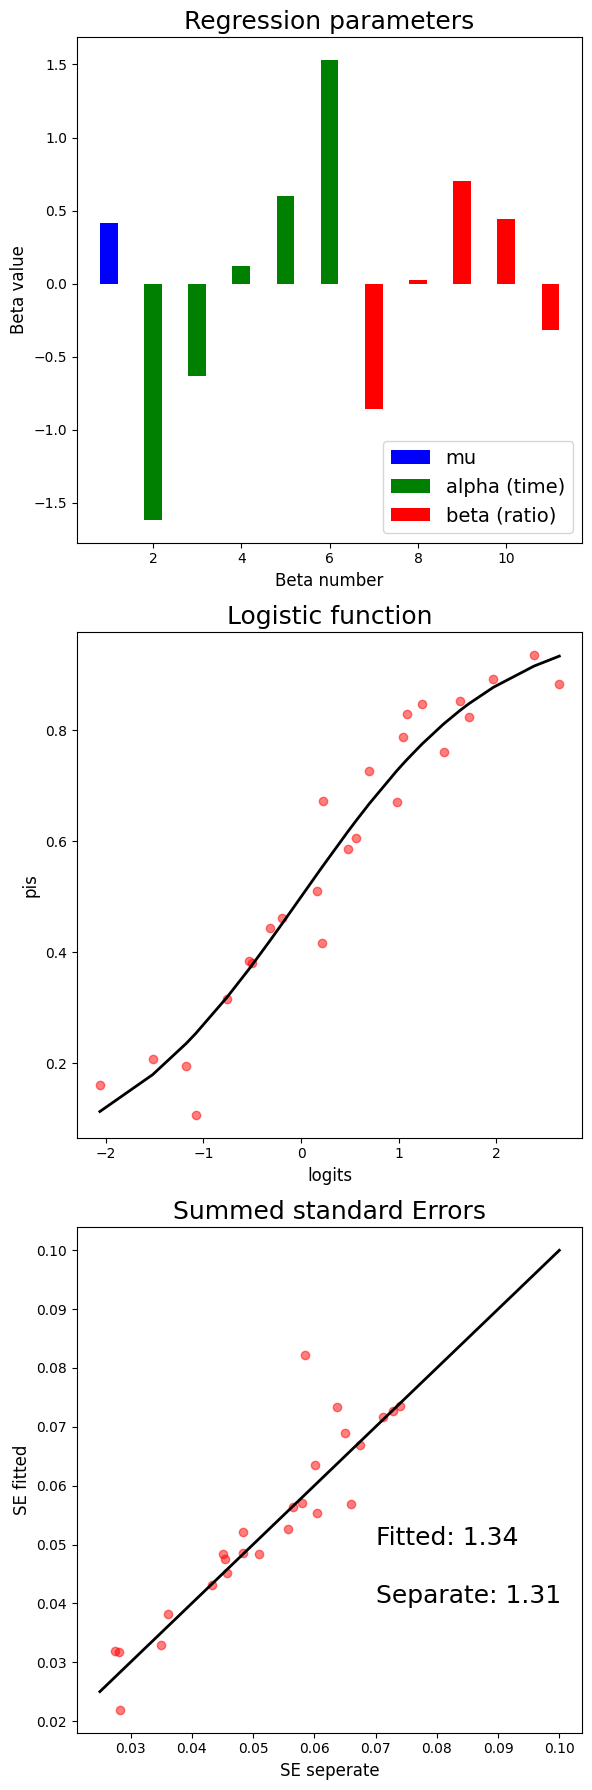

In [ ]:
# @title Logistic regression, cell infusion example {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit # logistic sigmoid function
from scipy.stats import binom

# define data
Nratio = 5;
Ntime  = 5;

thrived = np.array([
    [5,3,20,24,29],
    [15,36,43,56,66],
    [48,68,145,98,114],
    [29,35,57,38,72],
    [11,20,20,40,52]
])

colonies = np.array([
    [31,28,45,47,35],
    [77,78,71,71,74],
    [126,116,171,119,129],
    [92,52,85,50,77],
    [53,52,48,55,61]
])

design = np.array([
    [1,1,0,0,0,1,0,0,0],
    [1,0,1,0,0,1,0,0,0],
    [1,0,0,1,0,1,0,0,0],
    [1,0,0,0,1,1,0,0,0],
    [1,-1,-1,-1,-1,1,0,0,0],
    [1,1,0,0,0,0,1,0,0],
    [1,0,1,0,0,0,1,0,0],
    [1,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,1,0,0],
    [1,-1,-1,-1,-1,0,1,0,0],
    [1,1,0,0,0,0,0,1,0],
    [1,0,1,0,0,0,0,1,0],
    [1,0,0,1,0,0,0,1,0],
    [1,0,0,0,1,0,0,1,0],
    [1,-1,-1,-1,-1,0,0,1,0],
    [1,1,0,0,0,0,0,0,1],
    [1,0,1,0,0,0,0,0,1],
    [1,0,0,1,0,0,0,0,1],
    [1,0,0,0,1,0,0,0,1],
    [1,-1,-1,-1,-1,0,0,0,1],
    [1,1,0,0,0,-1,-1,-1,-1],
    [1,0,1,0,0,-1,-1,-1,-1],
    [1,0,0,1,0,-1,-1,-1,-1],
    [1,0,0,0,1,-1,-1,-1,-1],
    [1,-1,-1,-1,-1,-1,-1,-1,-1]
])

# collect matrix and observations

n = colonies.flatten()
X = design
y = thrived.flatten();

n_obs = n;
pis_obs = y / n;

# Negative log-likelihood for logistic regression
def neg_log_likelihood(beta, X, y, n):
 logits = X @ beta
 log_likelihood = y * logits - n * np.log(1 + np.exp(logits))
 return -np.sum(log_likelihood)

# Initial guess
beta_init = np.zeros(X.shape[1])

# Minimize negative log-likelihood
result = minimize(neg_log_likelihood, beta_init, args=(X, y, n), method='BFGS')

beta_fit = result.x;

logits_fit = X @ beta_fit
pis_fit = expit(logits_fit)

# Output results
print( "Estimated pi's:", pis_fit.reshape(Nratio,Ntime) )

print("Estimated beta's:", beta_fit)


# Visualize results
fig, axs = plt.subplots( 3, 1, figsize=(6,18))

# Plot 1: Coefficients mu, alpha, beta
mu    = beta_fit[0]
alpha = beta_fit[1:5]
beta  = beta_fit[5:10]

alphasum = np.sum(alpha)
betasum  = np.sum(beta)

alpha = np.append( alpha, -alphasum)
beta  = np.append( beta,  -betasum)

labels = ['mu', 'alpha', 'beta']

axs[0].bar( [1], mu, width=0.4, color='blue', label='mu' )
axs[0].bar( np.arange(2,7), alpha, width=0.4, color='green', label='alpha (time)' )
axs[0].bar( np.arange(7,12), beta, width=0.4, color='red', label='beta (ratio)' )
axs[0].set_box_aspect(1/1)
axs[0].legend(loc='lower right', fontsize=14)
axs[0].set_xlabel('Beta number', fontsize=12)
axs[0].set_ylabel('Beta value', fontsize=12)
axs[0].set_title('Regression parameters', fontsize=18)

# Plot 2: Logistic fit

indices = np.argsort(logits_fit)
logits_fit = logits_fit[indices]
pis_fit = pis_fit[indices]
pis_obs = pis_obs[indices]
n_obs = n_obs[indices]

axs[1].plot(logits_fit, pis_fit, 'k-', linewidth=2 )
axs[1].scatter(logits_fit, pis_obs, marker='o', color='red', alpha=0.5)
axs[1].set_box_aspect(1/1)
axs[1].set_xlabel('logits', fontsize=12)
axs[1].set_ylabel('pis', fontsize=12)
axs[1].set_title('Logistic function', fontsize=18)


# Plot 3: Squared standard errors

SE_fit = np.sqrt( pis_fit * (1-pis_fit) / n_obs )
SE_obs = np.sqrt( pis_obs * (1-pis_obs) / n_obs )

axs[2].scatter(SE_obs, SE_fit, marker='o', color='red', alpha=0.5)
axs[2].plot([0.025,0.1], [0.025,0.1], 'k-', linewidth=2 )
axs[2].set_box_aspect(1/1)
axs[2].set_xlabel('SE seperate', fontsize=12)
axs[2].set_ylabel('SE fitted', fontsize=12)
axs[2].text( 0.07, 0.05,  f"Fitted: {np.sum(SE_fit):.2f}", fontsize=18)
axs[2].text( 0.07, 0.04, f"Separate: {np.sum(SE_obs):.2f}", fontsize=18)
axs[2].set_title('Summed standard Errors', fontsize=18)


plt.tight_layout()
plt.show()


# **4. Generalized linear models**

Logistic regression is a special case of Generalized Linear Models (GLMs).  GLMs extend ordinary linear regression, that is least squares curve-fitting, to situations where the response variables are binomial, Poisson, gamma, beta, or in fact any exponential family form.

<br>

A one-parameter distribution in the exponential family is

<br>

$$
\left\{f_\lambda(y) = e^{\lambda y - \gamma(y)} \, f_0(y), \qquad \lambda \in \Lambda \right\}
$$

<br>

where $y$ is a data point from our experiment, $\lambda$ is the **natural parameter** of the distribution, $\gamma(\lambda)$ is the **normalizing function**, and $f_0(y)$ is the distribution for $\lambda=0$. For example, in case of the normal distribution, where $\sigma$ is assumed to be known

$$
f_\lambda(y) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left[-\frac{(y-\mu)^2}{2\sigma^2} \right]  =  \exp\left[ \frac{\mu y}{\sigma^2} - \frac{\mu^2}{2\sigma^2}\right] \, f_{\lambda_0}(y) = \exp\left[{\lambda y - \gamma(y)}\right] \, f_{\lambda_0}(y)
$$

where we have defined

$$
\lambda = \frac{\mu}{\sigma^2}, \qquad \gamma(\lambda) = \frac{\sigma^2\lambda^2}{2} = \frac{\mu^2}{2\sigma^2},\qquad f_0(y) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{y^2}{2\sigma^2} \right)
$$

<br>

We assume that each point from our data set ${\bf y} = (y_1, y_2, \ldots , y_N)$ independently samples members from this family of distributions, with corresponding natural parameters ${\boldsymbol \lambda} = (\lambda_1, \lambda_2, \ldots , \lambda_N)$

$$
y_i \sim f_\lambda( \lambda_i ), \qquad\qquad \mathrm{independently} \,\, i = 1, 2, \ldots , N
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_exponential_family.png" width="600">

<br>

# Maximum likelihood fitting

The $N$ natural parameters $\lambda_i$ are fitted with a linear regression

$$
\boldsymbol\lambda = {\bf X} \cdot \boldsymbol\alpha
$$

where ${\bf X}$ is an $N\times P$ design matrix and $\boldsymbol\alpha$ is a $P\times i$ parameter vector, with $P\ll N$.

<br>

The likelihood distribution of the observations, given our model and its parameters, is then

<br>

$$
L(\boldsymbol\alpha) = \prod_i f_{\lambda_i}(y_i) = \exp\left[{\sum_i \left[\lambda_i y_i  - \gamma(\lambda_i) \right]}\right] \, \prod_i f_{0}(y_i)
$$

where the dot-product

$$
\sum_i y_i \lambda_i = \underbrace{{\bf y} \cdot {\bf X}}_{\bf z} \cdot \boldsymbol\alpha
$$

includes the sufficient statistic ${\bf z} = {\bf y} \cdot {\bf X}$ and the sum of gamma-terms

$$
\sum_i \gamma( \lambda_i ) = \sum_i \gamma\left({\bf x}_i \cdot \boldsymbol\alpha \right)
$$

involves the dot-products between rows of $\bf X$ and parameter vector $\boldsymbol\alpha$.

<br>

The univariate likelihood distributions are characterized by their respective means $\mu_\lambda$ and variances $\sigma^2_\lambda$

$$
y\sim \left(\mu_\lambda , \sigma^2_\lambda \right)
$$

and the multivariate distribution has mean $\boldsymbol\mu$ and variance $\boldsymbol\Sigma$, which is diagonal due to independence

$$
\boldsymbol y \sim \left(\boldsymbol\mu(\boldsymbol \alpha) , {\boldsymbol\Sigma} (\boldsymbol \alpha)  \right)
$$

The MLE $\hat{\,\boldsymbol\alpha}$ satisfies

$$
0 = {\bf X}^T \left[ {\bf y} - {\boldsymbol\mu}(\hat{\,\boldsymbol\alpha})\right]
$$

and is destributed as with mean and covariance

$$
\hat{\,\boldsymbol\alpha} \sim \left[\boldsymbol\alpha, \left({\bf X}^T \cdot {\boldsymbol\Sigma}(\boldsymbol\alpha) \cdot {\bf X} \right)^{-1} \right]
$$

and its numerical solution is facilitated by the convexity of $\bf L(\boldsymbol\alpha)$,

<br>

The MLE $\hat{\,\boldsymbol\alpha}$ minimizes the total divergence

$$
\sum_i D\left[y_i, \mu_i(\boldsymbol\alpha)\right], \qquad\qquad D\left[f_1, f_2\right] \equiv \int_y f_1(y) \log\frac{f_1(y)}{f_2(y)} dy
$$

# Conclusion

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_three_levels.png" width="600">



The inner circle of represents parametric statistics of normally distributed variables. Exact inferences—t-tests, F distributions, and multivariate analysis are feasible there.

The middle circle comprises some exact results relating
to a few special families: the binomial, Poisson, gamma, beta, and so on. Exponential family theory unifies this middle circle into a coherent whole. Even the approximations are more robust and convincing that in the outer circle ('general theory').

# **5. Gamma regression**

Gamma distributions arise from accumulations of multiple events, each of whch occurs with exponentially distributed waiting times.

Examples include:

- Multistable perception: visual, auditory, and somatosensory perceptions and typically unstable, in the sense that they are eventually replaced with alternative perceptions, even when stimulation remains constant. The persistence duration of such perceptions is Gamma distributed.

- Gene Expression Levels: measured as mRNA or protein abundance, due to the stochastic nature of transcription and translation, where bursts of molecular synthesis occur at random intervals.


- Time to Cell Division: The time it takes for a cell to complete its cycle and divide (intermitotic time) can be gamma-distributed. This reflects the accumulation of multiple stochastic biochemical steps (e.g., DNA replication, checkpoint signaling) that must occur before division.

- Enzyme Kinetics: The time taken for an enzyme to catalyze a reaction or the number of substrate molecules processed in a given time can follow a gamma distribution. This is because enzymatic reactions often involve multiple intermediate steps, each with exponential-like waiting times.

- DNA Mutation Accumulation: The number of mutations accumulated in a genome over time, especially in rapidly dividing cells or under mutagenic stress, can follow a gamma distribution due to the independent occurrence of mutation events modulated by repair mechanisms.


# Binocular rivalry rexample

We investigated binocular rivalry in human observers at five different image contrasts. This produced five sets of 'perceptual dominance' periods (approximately 800 periods per set). We be believe that the different sets sample Gamma distributions with different rate parameters, but all with the same shape parameter $\nu \approx 3.5$.

Let $\bf n$ be a $(N_\mathit{sample}\times 1)$ vector of ones and $\bf c$ be a $(N_\mathit{sample}\times 1)$ vector of contrast values $c=1,2,\ldots,5$. Then we can define a design matrix

$$
\bf X = \left[\begin{array}{ccc} {\bf n}&  {\bf c} & {\bf n} \end{array}\right]
$$

for three unknown parameters ${\boldsymbol\alpha} = [\alpha_0, \alpha_1, \alpha_2]$.

<br>

The natural parameters $\lambda_{1,2} = \left(\frac{1}{\theta},\nu\right)$ of the Gamma distribution are the inverse scale (or rate) parameter $\frac{1}{\boldsymbol\theta}$ and shape parameter $\nu$, which we fit as

$$
\lambda_1  = X_0 \alpha_0 + X_1 \alpha_1, \qquad\qquad \lambda_2 = X_2 \alpha_2
$$

<br>

The Gamma distribution is defined as

$$\begin{eqnarray}
f_{\lambda}(y) &=& \frac{1}{ \Gamma(\nu)} \, \frac{y^{\nu-1}}{\theta^\nu} \, \exp\left(-\frac{y}{\theta}\right) =
\\
&=& \exp\left[-\frac{y}{\theta} + (\nu-1) \log y +  \nu \log \left(\frac{1}{\theta}\right)   - \log\Gamma(\nu) \right]=
\\
&=& \exp{\left[-\lambda_1 y +  (\lambda_2-1) \log y + \Psi \right]}
\end{eqnarray}$$

$$ \lambda_1 = \frac{1}{\theta}, \qquad \lambda_2=\nu,\qquad \Psi = \lambda_2 \log(\lambda_1) - \log\Gamma(\lambda_2)
$$

so that the parameter-dependent part of the log likelihood of observations, given parameters $(\alpha_0, \alpha_1, \alpha_2)$, is

$$
LL(\boldsymbol\alpha) = \sum_i \left[ -y_i \lambda_{1i}  +  (\lambda_{2i}-1) \log y_i + \lambda_{2i} \log(\lambda_{1i}) - \log\Gamma(\lambda_{2i})\right]
$$

The **negative** log-likelihood is what we want to **minimize**.

Estimated parameters: [0.61723285 0.77314406 3.5       ]


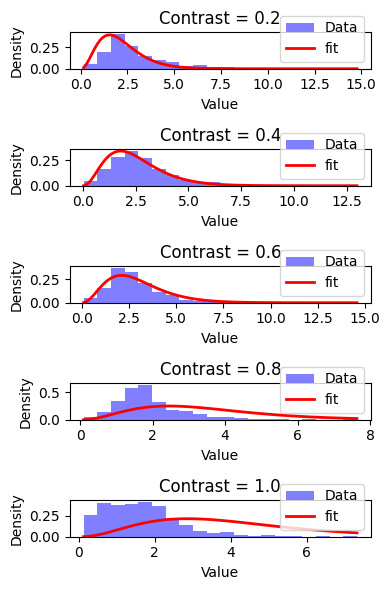

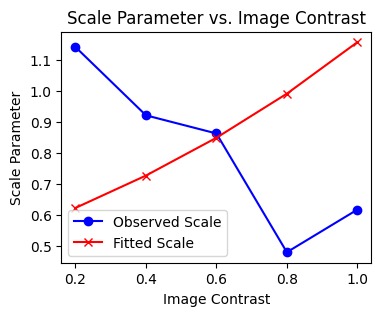

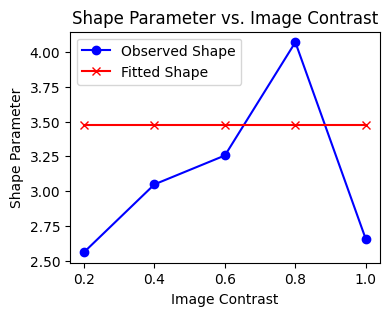

In [ ]:

# @title Gamma regression with binocular rivalry data, BUGGY ATTEMPT by hand {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import gamma

def RivalryData():

    sample_size = np.zeros(5,dtype='int')

    sample_size[0] = 740;

    sample_0 = ([5.5853, 3.9241, 5.1557, 1.2603, 4.2964, 2.5778, 1.4178, 1.6756, 1.9620, 4.7117, 2.3630, 2.1052, 3.3941, 1.9763, 1.0025, 0.6731, 2.2485, 2.6352, 2.7067, 2.7497, 1.3462, 1.6899, 1.3605, 6.3730, 1.2747, 0.4296, 1.7902, 4.9552, 2.1482, 3.7665, 1.4178, 3.0505, 1.3032, 1.8474, 1.8045, 1.4465, 1.1027, 2.9072, 1.1027, 2.4924, 1.6494, 1.6127, 1.2095, 3.3354, 2.7856, 2.7490, 1.7962, 2.1992, 1.7594, 1.8326, 1.7958, 2.4191, 2.1992, 2.2358, 3.1155, 1.6860, 1.4296, 1.7958, 1.6862, 1.9793, 1.7594, 1.7593, 1.7227, 2.2358, 2.4924, 2.1992, 2.5657, 3.6286, 2.4191, 2.0892, 1.8693, 1.9793, 2.1992, 2.4191, 2.6392, 8.4669, 2.4191, 2.6757, 2.4924, 1.7960, 2.1992, 2.3459, 1.8328, 4.6183, 2.3825, 1.9794, 2.0892, 6.2677, 1.2462, 1.6860, 0.9896, 1.1363, 1.0996, 2.1991, 2.5291, 1.7227, 1.5394, 1.5394, 1.5394, 1.9426, 1.9793, 2.5291, 4.4717, 2.0892, 4.1783, 4.6183, 7.6972, 3.2621, 2.0526, 2.0893, 3.8486, 2.7121, 2.3091, 3.1888, 4.3984, 2.4924, 1.3561, 1.3195, 1.7593, 1.7593, 1.2096, 1.7228, 1.4295, 8.2836, 2.3824, 1.6860, 5.1681, 2.7122, 1.8327, 2.3091, 2.0159, 1.7227, 1.5394, 1.4294, 1.7594, 2.0157, 2.0526, 1.6127, 1.7594, 1.7961, 1.5394, 1.6860, 1.3195, 1.6860, 1.6494, 1.5394, 1.7960, 2.0892, 3.6651, 6.2308, 5.7912, 4.1785, 2.0892, 2.0892, 1.7593, 1.7593, 1.6860, 1.6128, 2.7490, 1.7593, 1.4661, 1.8693, 1.8693, 2.1992, 2.7856, 1.0263, 1.1731, 0.9896, 1.8694, 1.1729, 1.7593, 2.6390, 1.6494, 1.4296, 1.8326, 1.6494, 1.7592, 1.9794, 3.2621, 1.6494, 1.3195, 1.4295, 1.3930, 1.6494, 4.9114, 1.7593, 1.4295, 1.4294, 1.2096, 2.5290, 1.6860, 1.0263, 0.9530, 1.1729, 1.6494, 1.6127, 1.6129, 1.3928, 1.7593, 1.7593, 4.2884, 1.5028, 1.7960, 2.9689, 1.5397, 2.5291, 1.6494, 2.0526, 2.7490, 4.5450, 3.8486, 2.8589, 3.3721, 3.5899, 6.8561, 4.9481, 3.2017, 7.3412, 5.2068, 4.7540, 7.3736, 3.6221, 5.7242, 1.4877, 5.6919, 1.6170, 1.6494, 3.6221, 9.1199, 2.4255, 1.8434, 2.0698, 1.6494, 6.1123, 1.5847, 4.6570, 6.4034, 2.2315, 3.7191, 5.6272, 3.4604, 3.8808, 2.1991, 3.4604, 4.3336, 2.4255, 2.6196, 1.0672, 3.8808, 5.1421, 3.9132, 3.8485, 5.0127, 6.0476, 8.1174, 3.1370, 1.4553, 4.4306, 1.8434, 4.7217, 4.7540, 3.5251, 3.3310, 2.4255, 3.9132, 2.0372, 1.3583, 0.6792, 2.6519, 2.1991, 3.4281, 1.1644, 2.1021, 1.7787, 7.6970, 1.4876, 0.2587, 2.0374, 2.8136, 3.0076, 3.7838, 4.1395, 3.0723, 2.8460, 1.6303, 1.5397, 1.0718, 3.1399, 3.6683, 6.0836, 2.5662, 1.1171, 3.9853, 1.6757, 1.8115, 0.3321, 1.7209, 4.3476, 2.1134, 3.3211, 4.0759, 3.9853, 2.6871, 2.5814, 2.9890, 3.4871, 2.0077, 0.2264, 1.9474, 2.8078, 1.7662, 0.6340, 2.4757, 1.7209, 5.9176, 2.0832, 4.4382, 2.1738, 2.0379, 4.4231, 1.5247, 2.5814, 3.6683, 4.8321, 1.9329, 3.9480, 3.5162, 2.2002, 1.9534, 7.9165, 4.6882, 0.9253, 1.4805, 3.3517, 1.8095, 1.6861, 6.4977, 0.8636, 3.7218, 4.1330, 2.5497, 1.9329, 5.4902, 2.7142, 1.6861, 5.7780, 3.5367, 4.3798, 0.7197, 3.5573, 3.0844, 3.3517, 0.5132, 3.7289, 0.6414, 5.4565, 9.8525, 6.7308, 3.0532, 2.4460, 1.7533, 2.0783, 1.1289, 1.5138, 0.1539, 1.4368, 0.2993, 5.2170, 4.3019, 3.0447, 0.3678, 4.3789, 0.6928, 3.1559, 1.5037, 2.3630, 1.4178, 2.0480, 1.2889, 0.6874, 3.3226, 1.0311, 3.2939, 1.6326, 2.0623, 1.4608, 4.3107, 2.4919, 3.5660, 3.0361, 0.4726, 6.0579, 4.2105, 1.8904, 1.8904, 0.6445, 2.4346, 1.2030, 2.6924, 5.6569, 2.5922, 2.7927, 3.3942, 0.8593, 1.4751, 0.1575, 1.2603, 1.7329, 0.9882, 3.2223, 1.3195, 2.3458, 1.7593, 2.3091, 6.6709, 6.4509, 3.6287, 5.0213, 3.1888, 3.7752, 2.4193, 2.6024, 3.9585, 2.1992, 2.2725, 2.7123, 2.4557, 2.3826, 2.8223, 2.4923, 2.1992, 2.0892, 1.9060, 2.3092, 1.9793, 2.3091, 2.3092, 5.2781, 2.0526, 1.7593, 2.3091, 3.7386, 2.7490, 2.6390, 2.5289, 2.0892, 1.9793, 2.3091, 2.2358, 1.9426, 2.7490, 1.8692, 2.7489, 2.6757, 3.8486, 3.1887, 2.1992, 7.7338, 1.7594, 2.1625, 2.0526, 2.8589, 1.5028, 2.9689, 2.5287, 9.4198, 5.0581, 3.0789, 3.5553, 4.7283, 2.7856, 2.2725, 5.2047, 4.0685, 5.7545, 4.5083, 4.1784, 12.4254, 13.5983, 5.0948, 6.5243, 5.8278, 3.3353, 2.9322, 3.2257, 3.8486, 14.7712, 10.4095, 2.8956, 0.6964, 1.0630, 4.0685, 1.9793, 1.3562, 1.6127, 3.5553, 1.7592, 2.0892, 2.4191, 3.1888, 2.4191, 1.9794, 2.4558, 4.5083, 5.2781, 2.4191, 1.8693, 2.1993, 2.6757, 2.1626, 3.0789, 3.4454, 2.8956, 3.5187, 2.0891, 4.6916, 2.6024, 4.8382, 2.7123, 2.0892, 3.0788, 0.9530, 1.6496, 2.4193, 2.0159, 2.8956, 3.1522, 2.3091, 6.3043, 5.5713, 4.6183, 3.7386, 2.4923, 4.4716, 2.0892, 2.8589, 5.0215, 2.7490, 2.9689, 2.7123, 0.8797, 1.3195, 1.8691, 3.8486, 1.6860, 1.6494, 1.6860, 2.7123, 2.1992, 1.9058, 1.8693, 1.4296, 1.9060, 2.4190, 2.1992, 1.8693, 1.6860, 1.4661, 1.7592, 2.0160, 7.3673, 2.1992, 1.4662, 1.9426, 4.7283, 6.1211, 5.4613, 3.8486, 2.4558, 2.9689, 2.1259, 2.5291, 3.3352, 6.3776, 2.6390, 2.4191, 3.6653, 2.1259, 2.8223, 2.4191, 6.5973, 12.2054, 7.9537, 2.3458, 3.2621, 9.5298, 4.5083, 7.8437, 3.6867, 2.0374, 1.7140, 6.5004, 2.5225, 1.7140, 3.2987, 7.2442, 6.1123, 6.4034, 2.0051, 8.5378, 5.1421, 4.8510, 3.7838, 2.6843, 1.0672, 2.8783, 1.5200, 1.7140, 0.3234, 7.0825, 2.4902, 3.3957, 5.3038, 1.1966, 6.2093, 4.7540, 3.9132, 1.4553, 3.9778, 3.7515, 2.1345, 1.1643, 5.2068, 5.2391, 2.4902, 3.1370, 7.2766, 7.5028, 3.2987, 5.5302, 3.3633, 7.1795, 4.5600, 4.6893, 2.7489, 3.6868, 4.5600, 2.6519, 1.7140, 1.3260, 1.1966, 2.5225, 1.9081, 1.2613, 1.8757, 2.2315, 4.2689, 1.4553, 1.8111, 2.0373, 2.1345, 4.4953, 4.3659, 3.0400, 4.3659, 4.5600, 5.0774, 3.1047, 2.3283, 3.1852, 2.0077, 0.5887, 2.1436, 0.4076, 2.8682, 4.7401, 3.9098, 2.5059, 1.9474, 2.4002, 2.8984, 2.9890, 2.3248, 3.6382, 2.2493, 3.2909, 5.2383, 2.5361, 3.1097, 1.5851, 2.7927, 0.6944, 2.3097, 0.4982, 2.7927, 3.6230, 3.0041, 2.5210, 2.4002, 2.1134, 2.9286, 2.4757, 0.5887, 2.7022, 0.3774, 2.7776, 2.7965, 3.6807, 0.5552, 1.5422, 1.4188, 7.1763, 4.1947, 4.1330, 1.6861, 2.0974, 2.7759, 2.8582, 1.8506, 0.9870, 2.5497, 2.1590, 7.3613, 3.0638, 4.6882, 2.2619, 4.9966, 2.4058, 4.2564, 4.2564, 4.8116, 2.7348, 2.2493, 2.6427, 4.3618, 3.5835, 3.0618, 2.4888, 1.7960, 0.7783, 1.1460, 0.8125, 1.8901, 5.2170, 1.6421, 3.0789, 2.6513, 1.4112, 2.3177, 1.0349]);

    sample_size[1] = 764;

    sample_1 = np.array([2.3487, 5.2703, 0.0430, 1.6326, 3.3082, 5.1557, 2.0480, 4.1675, 3.9813, 2.6638, 0.7017, 3.3369, 3.3512, 6.5019, 1.2603, 3.9097, 6.8313, 0.9166, 6.9602, 3.5087, 3.6806, 5.5710, 0.6015, 0.7304, 5.5710, 0.8736, 0.1718, 2.2341, 3.2366, 2.1339, 3.4371, 1.2889, 3.7808, 2.1768, 1.0629, 1.3196, 1.3195, 1.8327, 1.7594, 2.0526, 4.1785, 1.9426, 2.1992, 5.4979, 2.2725, 4.1784, 2.6024, 4.9481, 3.1155, 2.6390, 2.7490, 2.1992, 2.8589, 4.6549, 3.8852, 3.1888, 3.2988, 2.3458, 5.4980, 3.1155, 2.4191, 3.3354, 1.1362, 3.2988, 2.2725, 1.5761, 5.0215, 1.9059, 2.6390, 4.4717, 2.4924, 2.7490, 3.4087, 2.5657, 7.9904, 3.0421, 2.0526, 1.9793, 1.0996, 1.8327, 1.6860, 1.7960, 1.8693, 1.8327, 2.0159, 2.0159, 2.3458, 1.7960, 2.3092, 2.8589, 2.1259, 3.3354, 2.0526, 2.2358, 2.8589, 2.3458, 2.9322, 3.0422, 2.8956, 2.8589, 1.7593, 2.3091, 2.0892, 2.6390, 1.8693, 1.8693, 2.4558, 2.6390, 3.2988, 2.7490, 3.1888, 3.5920, 6.1577, 1.9793, 2.1992, 2.3091, 2.5291, 1.9426, 1.8693, 1.8693, 1.0996, 1.2828, 1.4661, 1.3562, 1.8693, 1.8693, 1.6858, 1.6860, 1.5761, 1.6860, 1.8693, 1.8327, 1.6127, 1.6127, 1.7593, 2.8956, 2.3091, 2.2358, 2.3458, 2.7491, 1.8324, 2.4558, 2.2358, 1.7227, 1.9793, 1.7594, 2.1992, 3.1888, 2.1992, 2.4190, 2.7490, 3.7386, 4.2518, 1.4295, 1.7227, 4.3984, 2.4188, 2.5291, 2.2361, 1.7593, 1.7227, 3.2988, 8.9433, 1.3928, 1.6494, 1.5028, 1.4295, 1.4295, 1.3928, 1.5394, 1.4295, 1.4661, 1.2829, 1.8693, 2.6390, 2.1625, 1.7227, 2.0892, 2.3091, 1.5761, 1.3928, 2.0892, 1.7960, 1.7593, 2.0159, 2.7856, 1.9793, 1.9793, 1.9426, 2.4924, 2.1625, 2.2358, 3.0788, 2.2358, 1.8327, 2.3092, 1.8326, 1.6861, 1.7960, 2.3825, 1.4295, 2.3458, 2.3091, 2.4924, 2.4191, 3.3354, 2.7490, 2.7490, 2.1668, 3.8485, 3.0076, 1.4552, 2.0374, 1.7787, 6.5004, 0.9055, 2.2315, 4.2689, 3.4604, 4.4306, 3.0077, 3.3310, 3.7838, 2.3285, 6.6944, 3.5898, 4.3659, 5.8859, 3.5574, 0.5821, 1.0672, 1.2613, 1.2289, 2.3932, 2.0374, 2.9106, 0.8085, 1.2936, 3.9455, 3.5898, 3.0723, 2.4902, 2.7166, 2.1021, 1.5847, 2.8136, 1.9081, 2.1668, 2.7489, 2.0374, 2.2962, 3.6868, 2.7166, 2.5549, 1.1644, 0.9379, 1.7142, 5.4331, 3.0723, 0.9379, 1.5200, 1.7464, 1.7787, 2.1021, 2.6196, 1.4553, 2.9430, 3.1370, 4.3983, 0.8732, 4.2689, 3.8808, 3.1047, 4.0749, 1.2613, 0.8732, 4.6893, 1.0996, 1.2613, 2.1021, 0.8732, 2.7489, 1.6170, 3.2340, 2.5227, 0.3234, 1.2613, 4.0749, 2.7813, 1.9404, 1.1643, 1.8111, 4.6247, 2.5549, 2.6719, 3.6834, 4.3929, 2.3549, 3.3965, 1.8719, 2.0228, 2.4756, 3.9400, 1.1926, 0.9510, 2.9739, 3.5022, 0.4830, 5.2986, 5.3892, 2.2342, 1.6304, 1.3133, 1.3888, 1.2982, 0.4982, 1.6304, 1.5398, 1.2681, 4.1665, 6.0685, 2.4908, 3.7136, 1.0416, 1.2954, 4.5032, 1.8506, 2.3235, 0.6580, 4.3387, 4.2564, 1.0898, 0.7608, 1.9329, 3.0021, 1.3777, 0.9664, 2.5292, 0.8431, 2.3235, 1.3777, 4.8527, 1.6244, 0.9048, 0.2879, 3.3311, 1.4805, 1.6244, 3.0844, 2.2617, 3.2283, 1.3982, 2.6320, 1.0076, 3.3928, 0.2468, 4.7499, 0.8842, 2.5292, 3.5367, 2.7142, 2.4058, 3.4339, 0.5140, 3.8572, 10.9985, 4.3190, 5.0289, 0.3592, 1.6421, 3.0276, 3.3697, 1.5908, 2.9250, 5.4650, 3.2927, 5.6960, 1.5737, 2.8565, 3.8572, 3.1986, 2.8480, 2.0909, 3.1937, 2.5635, 3.0934, 3.0075, 3.1221, 2.2198, 2.2055, 2.5062, 0.6731, 1.9763, 1.4608, 0.6874, 3.1364, 3.0361, 0.5988, 1.1743, 1.0455, 2.4060, 1.0455, 0.9882, 0.9452, 2.4060, 2.1766, 1.2460, 1.5467, 0.2148, 2.1482, 0.5156, 1.8188, 0.7697, 1.6860, 2.0525, 1.1362, 2.4191, 1.9426, 4.7282, 2.1259, 2.4191, 2.5657, 2.6390, 1.5761, 3.6287, 1.5394, 3.6287, 2.1625, 3.8486, 2.3458, 2.3824, 6.8175, 4.7649, 2.3824, 2.6390, 1.7227, 1.1729, 2.6390, 3.1522, 2.3091, 3.5920, 4.6183, 2.8589, 6.4143, 3.2621, 2.8956, 3.3721, 3.1155, 3.1155, 2.7490, 5.1681, 2.6390, 2.3091, 5.4247, 1.7960, 2.0892, 1.4661, 1.8693, 1.8326, 1.9793, 2.3091, 2.0892, 2.3824, 2.1625, 2.2725, 2.3824, 3.4087, 3.0789, 4.5816, 2.9689, 3.6653, 3.9585, 3.5920, 12.9752, 2.8956, 2.5291, 5.0215, 4.9482, 1.8693, 1.0996, 3.8486, 4.0685, 4.0685, 2.6757, 3.7019, 4.3984, 3.0788, 6.5976, 4.8749, 5.4980, 3.3354, 6.3410, 4.7282, 8.7967, 8.5402, 3.1155, 3.6286, 0.9896, 1.6861, 1.8693, 1.9426, 2.1625, 2.5291, 2.0894, 2.8223, 6.4509, 2.9322, 2.1625, 2.6757, 2.4558, 3.2988, 3.6287, 7.2573, 4.9482, 4.4717, 6.4876, 2.0526, 3.1522, 6.0845, 3.1888, 4.6916, 4.1785, 2.4557, 4.5083, 5.8278, 2.6757, 2.1992, 2.1260, 3.8119, 3.4820, 5.4980, 5.3880, 2.0892, 2.6393, 3.2988, 4.4350, 4.0315, 2.2358, 0.7697, 4.5083, 3.0422, 0.8064, 2.3091, 3.5554, 2.3091, 2.3091, 3.0789, 5.1681, 2.4924, 6.2677, 9.0166, 2.7490, 2.3091, 2.0159, 2.7856, 4.2151, 3.0422, 7.0374, 3.9585, 2.7856, 2.6024, 6.3776, 2.0892, 2.6024, 4.2517, 2.3091, 2.3458, 2.5657, 4.8749, 2.5290, 3.0789, 5.3513, 8.0270, 3.2988, 2.6757, 1.6494, 4.0684, 3.5187, 6.3776, 3.4087, 3.7020, 7.6238, 6.8541, 2.8223, 4.4717, 2.5291, 1.5847, 1.1319, 0.9055, 2.1345, 1.4876, 1.8111, 2.1668, 1.4876, 1.9404, 2.6842, 4.4628, 2.8459, 2.8459, 2.6519, 2.8459, 3.6221, 1.8434, 2.4579, 2.4578, 3.5898, 3.3957, 3.4927, 0.9702, 1.2288, 0.9702, 2.4255, 0.8408, 3.0076, 1.0672, 1.1642, 2.3285, 1.2289, 2.7489, 2.5549, 2.4255, 1.2936, 1.4230, 1.4553, 2.1345, 1.3583, 1.2613, 2.5872, 1.2613, 1.9081, 0.9702, 1.0672, 2.1991, 2.8783, 3.5898, 2.8136, 0.5820, 1.4877, 2.5225, 3.3957, 6.7915, 2.8459, 2.0698, 3.6868, 2.8136, 1.5847, 2.8459, 2.5226, 2.8136, 0.2911, 4.5600, 2.7166, 2.8783, 3.0076, 3.5251, 3.7191, 4.1396, 2.6196, 3.1047, 0.7762, 1.6493, 1.3583, 1.7787, 6.2740, 4.3013, 3.1047, 4.9480, 3.1370, 7.5999, 2.4578, 3.4281, 9.3140, 2.4579, 2.6196, 3.1370, 6.5004, 4.2042, 4.3336, 4.7540, 1.9404, 3.7136, 4.9816, 6.4761, 4.4231, 1.3133, 0.3019, 0.5284, 3.1852, 2.7474, 1.9323, 0.3623, 0.9963, 0.9360, 2.0379, 3.2154, 3.2154, 7.6385, 1.4945, 2.6116, 0.2264, 3.8192, 2.2342, 10.0085, 1.2680, 2.7474, 2.1285, 0.2566, 4.4533, 3.7438, 3.2305, 1.5398, 5.9327, 8.4386, 3.0796, 2.4002, 5.0583, 1.6039, 1.7478, 2.1590, 5.6341, 4.5854, 4.5443, 2.5497, 1.7272, 2.0357, 4.4003, 1.3982, 3.0844, 1.5422, 1.4805, 0.8019, 2.9404, 3.0021, 0.4729, 3.5162, 3.9068, 2.8377, 4.4415, 2.6937, 2.8993, 3.7012, 4.5648, 2.8787, 1.0898, 4.9350, 2.3852, 0.8636, 3.4339, 0.7402, 5.3282, 6.8848, 4.2591, 0.8467, 3.1986, 1.5138, 2.9848, 3.8315, 3.0276, 3.5236, 3.1302, 1.5822, 1.6677, 2.3605, 2.2579]);

    sample_size[2] = 776;

    sample_2 = np.array([3.1650, 3.2366, 2.7497, 0.6301, 4.2821, 2.4919, 3.4371, 3.8238, 1.8045, 2.2055, 3.3369, 2.0193, 0.6015, 1.4035, 1.2746, 3.6949, 2.0193, 2.2485, 3.0504, 2.8356, 6.1868, 0.8163, 0.5156, 2.4919, 0.4440, 5.9720, 3.7952, 3.8668, 4.5112, 3.5947, 5.3991, 3.7522, 4.4682, 1.6899, 5.5710, 3.1364, 1.6127, 1.8693, 1.8327, 1.9059, 1.7227, 1.9060, 1.6494, 2.6390, 2.6390, 3.0422, 3.1888, 3.0788, 2.8589, 2.7490, 3.7020, 2.6390, 2.9322, 1.9426, 2.6024, 2.5657, 1.5394, 1.8693, 1.9425, 2.0892, 2.0892, 2.8589, 2.2725, 4.9848, 2.7490, 2.6757, 7.2573, 2.2358, 3.5187, 3.4087, 3.4821, 4.1051, 2.4924, 3.2621, 5.7179, 8.8334, 3.6286, 1.2097, 1.3195, 1.9426, 1.5761, 1.8327, 1.7593, 1.8327, 1.7593, 1.5394, 2.2725, 2.7490, 2.5291, 2.0892, 2.0892, 2.6024, 2.5291, 1.7594, 2.4924, 1.6860, 1.6860, 1.7227, 1.9793, 2.0526, 2.1992, 1.9426, 1.8693, 1.5395, 1.6860, 2.6757, 2.1259, 1.7594, 1.9426, 2.3091, 2.0892, 2.0159, 3.4454, 3.9585, 4.6183, 2.1992, 1.6860, 2.3458, 2.7856, 1.9793, 2.6389, 1.2095, 1.2829, 1.6494, 1.6127, 2.1259, 1.5761, 1.4295, 1.9060, 2.1625, 3.5187, 1.7958, 1.9793, 1.5761, 1.4296, 2.0892, 1.6860, 2.6024, 2.9689, 1.7593, 6.4876, 3.1888, 3.1888, 3.0789, 2.3458, 3.0789, 1.8693, 1.6494, 2.1992, 4.4717, 2.3824, 1.7594, 2.3458, 1.9426, 2.8956, 2.1259, 1.9793, 2.6024, 1.8693, 2.6757, 4.1784, 1.9792, 2.6390, 1.2096, 2.7490, 3.2988, 3.6286, 2.4924, 2.3091, 1.5028, 1.6494, 1.9793, 1.6494, 1.5761, 1.5763, 1.5394, 1.3195, 1.5394, 2.1992, 2.1259, 1.7227, 2.1259, 2.1992, 3.1522, 2.7123, 2.9689, 2.9322, 2.3824, 2.5657, 1.4295, 2.4191, 2.4924, 1.3195, 3.8852, 1.3192, 1.6860, 1.5394, 1.6494, 2.5291, 3.4087, 2.6024, 2.7856, 2.1992, 1.4295, 1.7227, 1.8693, 1.9426, 1.7960, 2.4191, 2.3091, 2.4191, 2.1992, 3.6287, 1.8327, 2.8223, 1.7227, 1.5523, 2.3285, 2.2638, 1.7464, 2.0374, 2.6519, 4.4953, 3.3957, 4.4306, 2.7489, 2.5225, 1.2936, 2.2962, 3.2017, 4.2366, 1.9727, 3.1047, 1.9081, 1.0672, 1.4553, 4.5923, 4.6570, 4.2366, 4.1072, 2.2315, 3.1693, 1.9081, 1.5847, 0.9055, 2.6519, 6.6944, 3.2987, 3.5898, 3.6868, 0.1940, 2.2961, 1.2613, 3.6221, 2.2315, 3.2340, 2.1345, 4.2042, 5.1097, 2.5872, 3.6868, 4.0749, 0.7438, 0.9702, 2.7166, 14.5855, 6.0153, 5.8859, 9.7344, 6.9208, 4.8511, 6.0476, 9.0229, 4.5600, 4.5600, 6.3710, 4.4630, 4.9804, 0.6791, 0.2264, 0.7762, 0.5174, 1.6817, 0.8732, 2.5225, 0.5498, 4.1719, 1.6170, 2.7167, 2.7166, 1.5847, 1.1643, 6.4034, 1.0349, 1.8434, 1.1641, 2.3285, 1.0349, 1.9404, 1.4230, 1.5200, 1.7464, 0.8732, 0.9058, 0.8303, 0.7548, 1.2530, 0.8152, 2.1738, 2.5210, 3.9098, 1.9927, 0.4529, 2.0077, 3.8042, 2.0379, 2.8682, 2.1436, 4.4231, 1.2379, 0.3472, 3.1248, 4.7703, 0.7246, 3.7589, 0.8001, 1.6002, 4.1815, 1.7360, 1.9323, 4.5740, 3.7589, 3.7740, 3.9400, 3.1852, 4.9212, 2.9739, 2.2413, 3.3928, 0.9664, 3.8863, 4.8527, 2.1179, 2.9610, 2.6525, 1.2954, 2.0974, 1.6245, 1.6244, 7.5465, 2.2207, 2.4880, 1.5833, 0.4318, 1.8506, 3.0227, 1.3571, 3.2694, 2.4264, 3.7424, 1.6861, 2.7348, 2.1590, 2.9610, 1.6039, 2.8052, 4.1480, 4.2677, 2.2835, 4.4644, 1.4881, 4.1309, 2.9934, 0.3079, 2.8223, 3.6263, 1.6421, 1.1802, 4.5927, 2.1809, 3.5407, 1.1118, 2.0098, 2.8309, 1.4112, 1.9500, 1.6934, 3.2157, 3.0019, 1.4608, 2.9788, 3.2366, 2.5922, 2.1912, 3.5087, 1.5897, 2.8929, 1.6756, 2.7497, 1.9334, 1.2889, 2.6208, 2.0050, 3.4228, 2.7354, 1.3319, 1.8904, 3.4228, 2.6638, 3.0504, 2.7354, 0.5012, 2.1482, 3.2223, 1.7329, 2.4489, 0.0859, 2.3344, 3.2254, 1.6494, 1.6860, 1.7593, 1.6494, 5.0581, 2.4924, 2.5291, 2.5657, 2.7856, 3.2988, 3.9952, 3.4820, 5.8645, 2.6390, 3.2988, 3.3354, 3.6653, 2.4191, 4.5450, 3.1522, 3.0055, 1.8693, 1.8327, 0.7697, 2.0892, 1.7594, 3.0789, 2.4557, 2.4191, 2.1625, 2.1992, 3.1888, 4.5816, 1.6494, 2.5657, 2.9689, 3.1155, 2.3458, 4.0318, 2.6024, 3.7017, 2.0891, 3.0055, 3.6286, 2.7490, 2.3091, 2.4557, 3.1888, 2.1992, 2.0159, 3.0789, 2.3091, 3.1888, 2.8589, 4.9848, 5.2780, 2.3091, 3.9952, 5.0581, 5.1314, 2.7856, 2.8589, 3.2255, 4.5083, 7.7338, 6.4876, 3.6287, 4.5082, 4.3617, 4.9115, 3.2621, 2.4557, 3.9585, 2.3091, 2.4557, 4.6916, 4.8382, 3.5920, 3.7386, 2.7490, 2.3824, 8.5402, 3.7386, 3.4088, 5.6446, 1.5761, 1.8693, 2.1259, 2.5291, 1.8327, 2.0159, 2.2725, 1.9793, 2.9689, 2.6392, 2.0892, 5.1681, 2.0892, 1.8325, 4.1785, 5.3880, 3.5187, 2.0892, 3.6287, 2.9689, 2.6757, 2.7856, 2.6024, 5.0215, 3.4087, 2.0892, 2.1258, 1.9793, 2.5657, 1.8693, 2.4191, 2.9689, 3.2988, 8.6501, 2.0892, 2.6757, 4.3250, 2.7490, 2.3091, 2.1625, 2.7490, 0.6597, 0.9163, 2.2725, 1.6494, 2.5657, 1.9792, 1.0263, 1.4295, 1.7594, 2.0159, 2.4191, 4.0318, 5.1312, 3.4087, 3.2988, 3.6287, 3.7386, 2.6024, 2.3091, 3.8119, 2.7856, 3.2255, 3.5187, 2.4558, 2.4558, 2.5291, 2.7856, 2.7856, 3.1522, 3.6286, 3.1888, 11.5091, 1.8327, 1.8693, 2.5291, 2.4191, 2.1992, 8.7601, 3.0055, 3.2255, 3.9585, 3.9952, 2.8589, 3.1522, 2.8589, 3.1888, 2.9689, 3.6287, 2.6390, 2.6757, 3.8852, 4.0685, 1.1966, 1.3906, 1.4553, 1.6170, 1.5523, 2.2638, 3.2987, 1.7142, 4.5600, 1.1643, 5.4332, 4.2689, 2.9106, 2.8136, 4.4630, 1.4553, 3.0076, 3.0076, 3.5573, 2.1345, 8.1821, 4.3659, 3.7838, 5.9183, 1.5523, 1.9727, 2.8136, 1.6494, 1.5523, 3.5898, 3.2017, 5.3361, 3.4927, 1.2938, 4.4630, 1.9404, 1.2613, 3.5898, 1.0026, 3.0076, 1.5200, 3.2987, 2.8136, 3.4281, 1.0026, 2.8783, 1.0672, 3.8485, 4.9481, 4.1072, 2.0374, 4.2042, 0.7762, 8.0527, 4.0102, 5.1098, 4.4630, 5.5302, 3.1370, 4.5923, 4.3983, 1.9404, 8.6348, 5.6595, 1.4877, 2.6196, 5.2391, 3.8485, 2.3285, 2.2638, 9.9285, 0.6791, 0.9379, 0.9702, 1.3583, 0.8732, 1.9404, 3.6868, 2.9106, 3.4281, 2.6519, 9.1523, 3.7515, 1.3260, 2.2315, 2.8783, 2.8136, 1.4877, 1.0025, 2.1021, 2.6519, 2.1345, 1.2228, 1.2228, 1.2681, 2.2493, 0.8152, 2.2946, 2.9739, 3.5022, 2.4606, 2.5814, 0.4982, 3.7890, 4.6193, 1.4945, 1.2681, 2.8229, 1.5851, 2.8531, 2.8984, 2.6267, 4.3174, 1.9927, 2.4002, 2.7173, 2.5059, 1.8568, 1.8719, 3.8494, 5.6308, 3.8041, 4.6344, 2.8078, 5.8723, 0.6793, 0.4529, 4.8527, 3.7835, 3.3928, 3.5162, 6.1481, 1.4599, 1.3982, 1.9123, 3.2694, 2.5292, 3.6190, 0.9664, 7.5875, 6.2304, 3.4339, 4.6265, 4.9966, 4.6265, 2.2824, 6.6622, 3.8863, 2.4881, 3.6395, 3.3517, 2.1179, 2.7554, 3.5573, 2.9815, 2.1590, 4.1330, 1.8730, 2.4375, 0.2138, 3.5578, 2.1894, 1.5394, 1.0605, 1.4112, 2.1723, 4.0368, 1.4710, 1.1546, 0.8210, 2.0269, 0.5474, 1.5223, 1.0263, 0.7184, 1.7019, 1.4368, 2.7796, 1.4881]);

    sample_size[3] = 1159;

    sample_3 = np.array([0.5729, 2.5778, 3.8811, 1.0311, 2.7927, 2.2485, 0.9882, 2.9931, 0.6445, 1.8904, 3.2080, 3.3512, 0.8450, 3.4801, 1.6326, 1.9620, 2.0766, 1.2889, 2.3918, 1.0311, 1.7615, 1.5181, 2.2485, 4.0100, 0.9882, 2.3057, 6.1009, 5.1557, 5.4278, 0.9452, 1.3748, 6.1439, 2.1482, 2.8356, 3.7952, 2.1339, 1.5324, 2.7497, 1.0263, 1.2096, 1.4295, 1.3194, 1.3928, 1.4661, 1.2830, 1.3928, 1.6863, 1.7960, 1.5394, 1.7227, 1.4295, 1.5394, 1.5761, 1.6860, 1.5394, 1.5394, 1.6127, 1.7593, 1.8693, 1.4295, 1.4295, 1.3562, 1.5394, 1.8327, 1.3195, 1.2462, 1.4661, 1.5761, 1.5394, 1.6494, 1.5394, 1.7960, 1.8327, 1.2096, 1.6860, 3.5553, 1.7593, 1.5761, 1.5028, 1.7227, 1.6494, 1.5394, 1.4295, 1.3562, 1.7593, 1.8693, 1.6494, 1.7593, 1.9060, 2.0159, 1.9426, 1.9059, 2.0892, 1.6494, 1.9793, 1.8693, 1.8326, 1.8693, 1.8327, 2.0526, 1.5761, 1.9793, 1.8693, 1.4295, 1.5761, 1.8693, 1.5395, 0.7697, 0.7697, 1.2096, 1.0996, 1.0263, 1.5028, 1.0265, 1.1729, 1.3928, 1.0996, 1.2096, 1.4295, 1.3928, 1.0996, 1.2096, 1.3562, 1.4294, 1.1729, 1.4295, 1.0263, 1.5028, 3.4820, 1.5028, 1.4295, 1.3195, 1.3928, 1.3195, 1.6494, 1.2462, 1.6494, 1.4298, 1.3195, 1.7593, 1.7593, 1.4661, 1.8327, 1.5028, 1.5761, 1.7960, 1.6494, 1.7593, 1.4661, 0.6598, 1.5028, 1.2829, 1.5028, 1.1362, 0.6598, 1.5028, 1.1362, 1.5761, 1.3928, 1.1362, 1.3195, 1.7593, 2.1625, 1.8693, 1.9793, 1.9793, 1.9793, 1.9060, 1.9793, 2.0159, 1.3195, 1.4661, 1.2829, 0.8064, 1.0263, 0.8797, 1.0996, 1.0629, 1.0263, 1.0996, 1.0996, 1.3195, 1.5394, 1.4661, 1.2095, 1.2095, 1.0996, 1.3195, 1.2096, 1.2095, 1.2096, 1.6494, 1.6494, 1.3195, 0.9896, 1.3195, 1.5028, 1.2095, 1.3562, 1.3195, 1.5394, 1.9793, 1.2096, 1.2462, 1.3562, 1.2095, 1.2095, 1.0996, 1.2829, 1.0996, 2.3091, 1.2095, 1.1729, 1.3928, 1.5394, 1.7960, 1.0263, 0.8797, 1.4661, 1.2462, 1.6860, 1.4295, 2.1992, 3.0788, 1.6127, 1.9793, 1.5394, 0.8797, 2.7490, 1.0996, 0.8064, 1.2096, 1.4295, 1.2096, 0.5498, 1.3928, 1.1729, 2.0892, 2.1625, 1.4295, 1.9793, 1.0996, 1.1362, 1.3562, 1.2829, 1.2462, 1.5028, 1.4295, 1.0996, 1.5394, 1.5394, 1.3195, 1.4661, 1.2462, 1.4661, 1.5394, 1.4295, 1.2829, 1.2095, 1.2095, 1.0996, 1.3195, 1.6860, 1.6494, 1.7227, 1.6494, 1.4661, 1.5394, 1.7593, 1.6494, 1.4662, 1.5394, 1.3195, 1.5394, 1.9793, 1.9793, 2.7856, 1.7960, 0.8064, 1.7960, 2.0526, 1.8327, 1.7227, 1.4661, 1.5394, 1.5028, 1.3928, 1.6860, 1.3195, 1.5028, 1.5761, 1.6494, 1.5394, 1.6494, 1.7593, 1.7227, 1.7227, 1.6127, 1.7227, 1.7227, 1.9060, 1.9426, 1.7593, 2.3458, 1.9793, 1.4295, 1.7227, 1.5394, 2.0892, 2.0159, 2.0892, 1.5394, 1.7227, 2.0892, 1.6127, 1.9060, 1.9793, 1.8327, 1.9793, 2.1992, 1.6494, 1.9793, 1.9060, 2.1259, 2.0051, 2.1668, 1.4876, 1.6170, 3.7838, 1.4553, 0.9702, 3.0723, 2.2315, 3.0076, 1.7141, 2.5872, 2.1668, 1.3259, 3.8808, 1.8757, 1.9728, 0.6791, 2.1668, 2.3285, 1.3583, 2.2962, 1.8757, 2.1668, 3.1370, 2.7166, 3.1694, 1.0025, 1.4553, 0.8409, 1.5200, 1.5523, 1.8111, 2.2315, 1.9728, 1.4553, 2.1345, 1.3259, 2.7163, 2.5225, 1.3260, 2.2638, 1.6817, 1.2613, 1.9081, 4.1719, 2.6195, 2.5549, 2.2315, 2.7489, 1.5523, 1.1966, 3.2987, 2.2962, 2.6519, 3.2664, 1.3260, 2.7489, 3.2987, 3.2987, 4.5923, 3.4604, 2.6842, 2.4255, 0.7438, 1.0025, 3.2987, 3.7838, 2.8136, 4.5276, 3.1047, 4.9481, 2.2315, 1.4553, 1.0996, 1.7787, 0.7762, 1.2289, 1.5523, 1.9404, 1.9081, 3.1047, 3.0076, 1.7140, 0.9702, 3.6868, 2.6844, 4.1716, 0.8732, 3.7515, 1.1643, 2.5549, 2.0374, 2.0374, 3.0076, 1.3906, 2.8136, 2.9753, 3.9778, 1.6493, 1.6493, 2.7166, 2.3285, 2.1021, 3.3633, 2.0698, 2.1991, 3.2017, 2.7813, 1.4553, 5.2715, 3.2664, 4.3659, 2.9106, 1.9404, 2.6519, 3.1370, 4.7540, 1.6817, 4.6247, 4.2689, 2.7813, 0.9055, 0.3557, 0.6791, 0.4528, 0.7762, 0.9702, 1.1643, 1.6493, 1.3583, 2.2638, 1.0349, 1.0672, 1.4553, 2.1021, 1.2613, 0.9379, 0.7761, 0.8408, 3.9778, 1.1966, 1.0349, 2.4255, 2.7166, 1.8434, 2.3608, 0.9702, 2.0698, 1.8434, 3.1047, 2.8459, 1.1171, 1.5398, 2.1285, 3.1248, 1.7964, 3.2607, 1.6907, 2.4002, 1.3133, 2.9890, 1.9927, 2.2191, 2.5361, 1.4492, 0.5434, 1.3586, 3.1248, 2.1436, 3.0343, 0.2415, 1.2077, 0.5284, 0.7699, 0.3774, 1.2228, 3.0343, 0.4227, 1.6002, 4.9363, 6.1591, 1.5851, 0.6340, 0.6793, 1.4190, 0.2717, 0.9058, 1.3435, 2.2644, 2.4757, 0.6038, 2.9588, 2.6569, 1.1104, 0.9253, 1.1926, 1.2954, 3.2077, 3.1666, 1.1104, 1.5216, 1.0487, 2.1590, 1.6244, 1.3571, 3.1872, 2.0357, 1.4807, 0.3701, 1.7683, 3.1872, 3.2927, 1.4625, 2.3862, 0.8467, 3.4124, 2.3519, 2.8993, 1.8559, 1.7704, 1.8644, 0.6158, 0.9493, 0.9836, 0.7954, 1.1375, 1.6421, 3.2243, 2.8736, 2.1210, 2.8822, 3.9256, 1.4796, 1.1289, 1.2059, 1.1717, 1.7105, 0.8980, 1.0520, 1.1375, 1.8987, 0.3849, 0.5901, 0.9664, 0.9452, 3.4371, 1.3749, 2.0766, 1.8475, 0.3867, 1.9763, 1.5181, 3.4371, 2.3057, 1.3032, 1.1742, 1.1887, 2.1052, 1.9477, 0.6445, 0.8306, 0.6158, 0.2005, 1.8475, 2.6065, 4.6831, 1.2889, 2.6781, 1.3319, 1.2030, 1.8188, 3.9527, 2.4060, 4.2964, 1.1600, 2.8786, 1.4178, 0.6597, 1.1729, 1.5394, 1.8694, 1.7960, 1.8693, 1.8693, 1.7958, 1.5394, 1.7225, 1.5394, 2.3458, 1.8693, 2.1259, 2.0526, 1.8327, 1.9426, 1.6860, 2.4191, 1.9793, 1.8693, 2.0892, 2.3091, 2.5291, 2.4924, 3.9951, 3.5187, 1.7593, 2.0526, 2.1625, 1.7593, 1.9426, 1.9059, 2.0892, 2.3091, 5.4979, 2.9689, 4.5816, 0.7331, 1.9793, 2.6390, 1.7960, 1.7593, 2.0892, 1.7594, 1.7593, 1.8327, 1.6494, 1.8693, 1.7593, 1.8693, 1.9426, 2.1992, 1.9793, 2.5291, 2.4191, 1.8693, 2.6757, 2.5291, 2.0892, 1.7960, 2.0159, 1.3195, 1.6127, 2.3458, 2.3824, 1.8693, 2.0892, 1.8326, 0.9163, 1.3928, 1.2096, 1.6494, 1.7593, 1.8693, 1.8693, 1.8691, 1.7960, 1.7593, 1.7593, 1.7593, 2.0159, 1.7960, 2.2725, 1.8693, 2.2725, 2.0159, 1.9060, 1.5394, 1.7594, 2.2358, 2.0159, 4.2151, 2.1625, 2.0159, 2.3091, 2.5291, 1.7227, 2.4924, 2.8589, 1.6494, 2.4188, 2.0892, 1.7960, 1.9426, 2.3091, 2.1259, 1.9793, 2.2725, 3.9219, 2.6390, 2.1992, 2.9322, 1.6860, 2.2725, 3.9952, 1.9793, 3.9219, 3.0055, 2.0892, 2.2725, 3.0789, 2.5291, 2.9322, 2.4191, 2.6757, 2.3091, 2.8589, 2.3091, 2.4191, 2.7490, 2.4191, 2.9322, 2.3458, 2.5657, 3.9219, 2.3091, 2.4191, 0.8430, 1.8326, 1.7227, 1.6494, 1.4661, 1.8693, 1.5028, 1.6494, 1.7593, 1.5394, 1.6494, 1.5028, 2.0892, 1.8693, 1.7593, 1.9792, 1.5394, 1.4661, 1.8326, 1.6494, 1.4661, 1.3928, 1.9060, 1.6494, 1.5394, 1.7593, 1.7593, 1.6494, 2.6390, 1.7593, 1.5394, 2.0526, 2.0526, 1.8693, 1.7960, 2.4191, 1.7593, 1.8693, 1.7593, 1.7960, 1.9059, 1.5761, 1.6127, 1.7227, 1.5028, 1.3195, 1.5028, 1.3928, 1.3928, 1.5394, 1.5394, 1.7227, 1.5761, 2.3825, 1.5394, 1.9793, 1.0263, 2.4191, 1.7593, 2.1992, 1.9426, 2.4191, 2.4191, 2.1259, 1.5761, 1.6494, 2.8956, 1.7593, 2.1259, 1.7227, 1.3928, 1.4295, 1.8693, 2.1992, 2.3458, 2.1259, 1.7593, 2.7490, 1.4295, 1.3928, 1.5028, 1.6494, 1.5028, 1.5761, 1.3562, 1.3195, 0.9896, 2.0892, 1.5394, 1.3928, 1.5761, 1.7960, 1.6127, 2.0526, 1.7960, 1.7227, 1.8693, 1.7226, 1.8693, 1.6494, 2.0892, 2.1992, 2.3091, 2.0526, 2.2725, 1.5028, 2.5291, 3.7753, 1.5394, 2.1625, 2.6390, 1.9793, 1.5761, 1.8693, 2.2725, 3.9952, 2.0892, 1.7227, 1.8693, 2.0892, 1.6494, 1.9793, 1.3561, 1.4661, 1.7960, 1.5761, 2.0892, 1.5394, 1.6494, 1.5761, 1.8693, 1.4295, 1.4295, 1.4661, 1.4295, 1.8693, 1.9793, 1.9792, 1.7227, 1.4661, 1.6494, 1.5761, 1.7593, 2.1625, 1.9060, 2.0892, 1.8693, 1.6494, 1.9793, 1.7593, 1.7227, 2.7493, 1.3583, 2.4255, 1.6170, 1.5523, 2.6519, 1.7464, 2.1991, 2.5549, 1.0349, 1.7787, 2.9106, 2.1991, 1.5523, 4.5923, 1.2936, 3.4281, 3.3634, 3.3634, 2.0051, 1.6817, 2.5225, 2.4255, 2.6196, 2.1344, 3.0400, 3.7838, 3.4281, 0.9055, 1.5200, 1.2936, 4.8510, 1.0996, 2.2638, 1.0996, 1.7464, 2.1991, 1.2613, 3.2987, 2.1345, 2.1021, 1.5523, 2.0374, 4.8510, 1.7464, 2.1991, 0.9379, 0.1617, 2.3285, 2.1021, 1.9404, 2.6842, 2.7166, 1.1643, 1.8434, 2.6196, 2.9106, 2.0698, 1.1966, 3.9132, 1.9727, 3.5251, 1.6817, 0.6791, 1.2613, 2.8136, 1.6494, 2.5226, 3.5574, 1.3259, 3.0076, 1.8111, 2.2638, 3.5574, 3.2987, 3.6546, 4.0749, 4.0749, 2.4579, 3.0076, 3.2664, 0.9055, 1.1319, 1.0025, 1.6494, 1.3583, 2.4255, 1.6494, 1.7464, 2.8136, 2.1345, 2.0374, 2.8783, 3.7838, 4.0749, 3.5898, 1.0349, 3.1047, 0.8085, 2.6196, 0.5820, 5.0451, 4.5276, 3.2017, 2.0374, 2.0051, 4.8510, 6.5327, 0.6792, 1.3260, 3.0723, 2.7489, 2.7489, 2.1668, 2.9430, 0.8408, 3.1047, 1.3583, 1.5847, 2.3608, 0.0970, 4.4953, 3.2017, 2.9106, 1.1319, 3.0076, 3.2987, 2.8136, 4.2042, 3.3957, 1.1319, 2.5225, 2.8136, 2.9430, 2.2315, 0.3881, 0.8085, 0.3234, 0.5821, 0.7438, 1.0025, 1.0996, 1.2936, 0.5821, 0.8408, 0.9702, 1.0672, 0.4204, 0.9702, 1.1966, 2.7166, 2.1345, 2.8783, 4.0749, 1.0673, 2.7489, 1.6170, 1.2613, 2.3285, 2.4255, 1.7464, 2.3932, 1.4877, 3.5251, 2.7166, 1.5700, 1.0416, 3.7136, 3.0343, 4.4232, 3.8947, 3.2305, 2.5059, 3.0947, 1.1020, 1.6304, 3.8494, 1.9776, 1.5549, 1.1775, 0.4378, 0.9058, 0.6793, 0.4076, 1.0718, 1.3133, 3.3512, 1.9021, 0.4831, 1.0416, 1.3888, 1.4039, 1.4945, 1.6454, 5.2534, 4.2117, 7.6385, 1.3435, 1.0416, 1.4492, 1.3133, 1.3133, 1.3586, 1.6153, 0.7246, 3.7437, 0.9963, 0.6793, 1.0416, 0.9510, 0.9870, 2.4880, 0.9459, 1.4599, 7.0323, 7.3613, 5.3668, 1.4188, 2.1590, 3.3311, 2.8170, 0.6374, 3.5162, 4.0096, 4.3798, 1.8506, 5.0583, 5.1817, 4.6060, 0.7402, 0.6786, 1.3777, 1.0898, 0.8636, 0.4935, 0.8431, 0.3496, 1.1722, 1.0006, 1.6677, 1.0947, 2.8993, 0.6756, 1.1888, 2.4033, 1.4283, 0.8724, 0.5645, 2.1210, 0.5388, 0.4105, 1.6677, 1.3598, 0.6243, 1.4881, 1.0776, 3.3355, 4.9605, 1.8302, 3.0532, 1.1802, 1.4454, 2.0013, 0.9835, 1.1289, 2.6684, 1.5309, 1.6335]);

    sample_size[4] = 958;

    sample_4 = np.array([0.4296, 0.8163, 0.7590, 1.0311, 1.7186, 1.0168, 2.6208, 1.2030, 2.2341, 1.0311, 0.8163, 0.6015, 1.9620, 1.5753, 1.2030, 2.1768, 1.3462, 2.7783, 3.8381, 2.7497, 3.8524, 1.9763, 3.6519, 0.8593, 4.6401, 0.9022, 0.4726, 2.9788, 2.0623, 1.2030, 4.0959, 3.7808, 0.7733, 1.9763, 1.6756, 1.2460, 3.7665, 3.8811, 2.9502, 2.8356, 1.4894, 2.0480, 0.7161, 3.1937, 1.5037, 3.8668, 3.5230, 1.3195, 1.0263, 0.9896, 1.3195, 1.8327, 1.5394, 1.3928, 1.9793, 2.2725, 1.9793, 1.8693, 2.6024, 1.6127, 1.4295, 1.9060, 1.6127, 1.3562, 1.4295, 1.3928, 1.5394, 1.2095, 1.4661, 1.3562, 1.7593, 2.3091, 1.6860, 1.2462, 1.9060, 1.2828, 1.3195, 2.0526, 0.8797, 1.4295, 1.6860, 2.2725, 0.8797, 1.2095, 1.3193, 1.3562, 1.3928, 1.2097, 1.6127, 1.8693, 1.6860, 1.4295, 2.3091, 2.0159, 1.6860, 1.6494, 3.8486, 1.4661, 1.6494, 2.0159, 1.5394, 0.8797, 1.8327, 1.5394, 1.4294, 1.3195, 2.1259, 1.6494, 1.5394, 1.8693, 1.1729, 1.5394, 1.3195, 1.4295, 1.2096, 1.5028, 1.4295, 1.6494, 1.5394, 1.2095, 1.2096, 1.5028, 1.3928, 1.6860, 1.7960, 1.7593, 1.5395, 1.5761, 1.5394, 1.6494, 1.7225, 1.8326, 1.5761, 1.6127, 1.6860, 1.9793, 1.9426, 1.7960, 2.0892, 1.6857, 1.9793, 1.9793, 2.6390, 1.9426, 1.9792, 2.8585, 2.0526, 1.9792, 2.0892, 1.8693, 2.6390, 2.3091, 2.9689, 2.5291, 2.8589, 3.8486, 3.5187, 1.7593, 1.6494, 1.7960, 2.0892, 2.2358, 2.3824, 2.0892, 1.7960, 1.6860, 1.7593, 1.9792, 1.6857, 2.2358, 1.7593, 1.6494, 4.0318, 1.9793, 1.5394, 1.4661, 2.4924, 1.9792, 2.1992, 1.7960, 1.8693, 2.7490, 2.0159, 2.2725, 1.9793, 2.0892, 2.4191, 1.6494, 1.3561, 1.7593, 1.2462, 2.0892, 2.1992, 1.2829, 0.2199, 1.4295, 2.0159, 2.1259, 1.9426, 3.3354, 2.4557, 2.4191, 1.0263, 1.1362, 1.4661, 1.6127, 1.3195, 1.4661, 3.1888, 3.3720, 2.6757, 3.0055, 3.8852, 3.7020, 1.2462, 1.7960, 1.6494, 1.7227, 1.9059, 1.6127, 1.6494, 1.5394, 1.1362, 1.0629, 1.6860, 4.1051, 1.9793, 3.7386, 1.6494, 2.0526, 5.6079, 1.7593, 1.9793, 2.1259, 2.0526, 2.0892, 1.7591, 2.3091, 2.6024, 2.4191, 2.3458, 2.1259, 1.8693, 2.0892, 1.8693, 2.7490, 3.1888, 2.6390, 2.8589, 3.2988, 3.2988, 3.3354, 1.9793, 3.1522, 2.5291, 1.8693, 2.4924, 2.3091, 4.5449, 2.4191, 3.3721, 2.6756, 2.6390, 4.6183, 1.8757, 2.1668, 1.2613, 1.3259, 1.5847, 0.9702, 1.5523, 0.8732, 0.7115, 0.6792, 2.3932, 1.8757, 1.5200, 1.2289, 0.4851, 0.6468, 1.4553, 0.8732, 0.6468, 0.6468, 0.4851, 0.5174, 0.9379, 1.0349, 0.9055, 1.2613, 0.8085, 0.5498, 0.6467, 1.4877, 0.4204, 0.3234, 0.3234, 0.4851, 0.4851, 0.4851, 0.5821, 0.8408, 0.8409, 0.8085, 1.0672, 1.0349, 1.3259, 0.7115, 0.5175, 0.7438, 0.8409, 0.5498, 0.8085, 1.1319, 1.2289, 0.4204, 0.3558, 0.3234, 0.3881, 0.2911, 0.6468, 0.5821, 0.3234, 0.7761, 1.0672, 0.6145, 0.6145, 0.4528, 0.6791, 0.5498, 0.6468, 0.7762, 0.4528, 0.6145, 0.9702, 0.7115, 1.0025, 1.1020, 0.8907, 0.9058, 1.0416, 0.9058, 0.9510, 0.5435, 1.2983, 1.2681, 1.1775, 1.4039, 1.6454, 1.2379, 0.8605, 1.3133, 1.8115, 1.1775, 1.8568, 1.8719, 1.0567, 1.1171, 1.7661, 0.4831, 1.0869, 1.0869, 0.8454, 0.6038, 1.5247, 1.2530, 2.7022, 0.8152, 1.1473, 1.3586, 1.0567, 1.1775, 1.1473, 1.1473, 0.7095, 0.7850, 2.2191, 1.2228, 0.7699, 1.1473, 1.2077, 0.7095, 3.6381, 1.2379, 1.3133, 0.4680, 0.2264, 0.7397, 2.0379, 2.4455, 2.0832, 1.7813, 0.1510, 2.2191, 1.9474, 0.4982, 0.8605, 1.4341, 0.2717, 0.3019, 2.0379, 2.8531, 1.1322, 0.3701, 0.6786, 0.2056, 2.1385, 0.4729, 0.5963, 0.8225, 1.1104, 0.9322, 0.6414, 0.7868, 1.1802, 1.2914, 0.7954, 0.9237, 3.3697, 2.5230, 1.7533, 1.9842, 2.0954, 1.4026, 0.8552, 1.2059, 3.5664, 2.2921, 1.0006, 1.4112, 0.2993, 0.8553, 1.1118, 0.7184, 0.4533, 0.5388, 0.3506, 0.5987, 0.4875, 0.4362, 0.3507, 0.3849, 0.2908, 0.3507, 0.2993, 0.3592, 0.4618, 0.4105, 0.4105, 0.5303, 0.5901, 0.4618, 0.3592, 0.5474, 0.2822, 0.3335, 0.7441, 0.4704, 0.8809, 0.7441, 0.8895, 0.4447, 0.4362, 1.0434, 0.5729, 1.7759, 2.4490, 0.1289, 2.0336, 1.3605, 2.3057, 1.0025, 1.9763, 2.7927, 1.5037, 1.1600, 2.3773, 1.2460, 2.9216, 2.2914, 2.1625, 1.7615, 1.3748, 1.6040, 0.5156, 1.1600, 1.3748, 2.7783, 0.9309, 0.9452, 2.8786, 0.8163, 1.0741, 0.4726, 0.7734, 2.5492, 1.8475, 1.9047, 0.9309, 0.7304, 2.1482, 0.3437, 1.7329, 1.6613, 1.2889, 1.8045, 1.7329, 1.5394, 1.7593, 1.6127, 2.4191, 1.7960, 1.8693, 1.5761, 1.7593, 1.7960, 1.7593, 2.3091, 2.5657, 2.1259, 1.7593, 1.9793, 1.8693, 2.4191, 2.2725, 2.1259, 2.1992, 1.7594, 1.9793, 2.8223, 2.0892, 1.9426, 2.0892, 2.0892, 1.7227, 1.8694, 1.9792, 2.7856, 1.5394, 3.4454, 4.9115, 6.2676, 2.2358, 1.9426, 1.8693, 1.9795, 1.9793, 1.9793, 2.0159, 2.0891, 1.5761, 2.4191, 1.9060, 2.0526, 1.5761, 1.9793, 2.2725, 2.3091, 2.3824, 2.6390, 2.1625, 2.1992, 1.6494, 1.2095, 2.1259, 1.6494, 1.7594, 1.9793, 3.7386, 3.5920, 2.7490, 2.7856, 0.9163, 2.1992, 2.3091, 2.2358, 2.6023, 2.4557, 2.8589, 3.0789, 3.2988, 2.7856, 2.0526, 2.8222, 1.7960, 2.3091, 2.3824, 3.9219, 3.7752, 2.4923, 3.1521, 4.1784, 2.7858, 3.1155, 3.0788, 2.4191, 0.4398, 1.9426, 2.0159, 2.4191, 2.5290, 2.8226, 2.9322, 2.6390, 2.1992, 2.7856, 2.3091, 2.5295, 3.5920, 2.4191, 2.4191, 2.6390, 1.3195, 1.8693, 2.6390, 2.6390, 3.4087, 3.2988, 2.6390, 2.8589, 2.5291, 1.5761, 2.2725, 7.0007, 3.1888, 4.2151, 2.3091, 1.1362, 3.6653, 1.6127, 1.8326, 1.8693, 1.8697, 2.3824, 2.0526, 1.7593, 2.4557, 2.3091, 1.5394, 1.9793, 1.5394, 2.1259, 2.1625, 1.9793, 2.0526, 2.0892, 0.8797, 1.4295, 1.6494, 1.8693, 5.1314, 2.0526, 1.3195, 1.6127, 1.7594, 1.3928, 2.0892, 1.7960, 1.9426, 4.9481, 2.7123, 1.2829, 5.6079, 1.9793, 1.7227, 1.9426, 3.0788, 4.6183, 2.1625, 1.8693, 0.9530, 2.3458, 1.6860, 2.0526, 3.1521, 3.8852, 5.8278, 3.0422, 7.3306, 2.5290, 2.7490, 1.8327, 1.6127, 1.5761, 2.4191, 1.9793, 1.9793, 1.7593, 1.8693, 3.0789, 2.3091, 5.2780, 2.9322, 1.7960, 2.3824, 2.4557, 3.3354, 2.1992, 2.1625, 2.1992, 2.6390, 1.9059, 2.3094, 3.8119, 3.3354, 2.6390, 2.9689, 2.1625, 2.0892, 1.8693, 2.8589, 3.5187, 2.4191, 2.6390, 2.7490, 2.9689, 3.8486, 2.1992, 4.1051, 1.9059, 1.8326, 3.0055, 1.5028, 2.9322, 2.6757, 5.1681, 5.3880, 4.8382, 3.0055, 1.9404, 3.8808, 1.0996, 2.0374, 1.4877, 1.8757, 1.1642, 1.2613, 2.9106, 1.2289, 1.5523, 1.9404, 1.5523, 1.3260, 1.5200, 0.9379, 1.3260, 1.2289, 0.7115, 0.6792, 0.3881, 0.3234, 0.9702, 1.0349, 1.7464, 1.3583, 0.5821, 0.4852, 0.6468, 0.5498, 0.3232, 0.7762, 0.5821, 0.8732, 0.1940, 1.1642, 1.0025, 1.0025, 1.0349, 1.1319, 1.0026, 1.0025, 0.6791, 0.4851, 0.8732, 0.7115, 0.7762, 1.1642, 1.4877, 0.3881, 0.3557, 0.3234, 0.1940, 0.3557, 0.3881, 0.4851, 0.5821, 0.6145, 0.7115, 0.7762, 0.7115, 0.7762, 1.1642, 1.1642, 0.9055, 0.6791, 0.5821, 0.6791, 1.1643, 0.6791, 0.5175, 0.7762, 0.6467, 1.0672, 0.9055, 0.8732, 0.9379, 1.4553, 0.3881, 0.3234, 0.3557, 0.2264, 0.2587, 0.3557, 0.2911, 0.4851, 0.4851, 0.4204, 0.4204, 0.5174, 0.7438, 0.6791, 0.6791, 0.4851, 0.8408, 0.4204, 0.7115, 0.8732, 0.7115, 0.7438, 0.4204, 0.9702, 0.6340, 1.2982, 0.9963, 1.1171, 0.8303, 1.0416, 2.0983, 0.5585, 0.9963, 1.2378, 1.7058, 1.3284, 2.0228, 1.7662, 0.7246, 0.9661, 2.0077, 1.7813, 1.4492, 0.6642, 1.4341, 1.7662, 0.8605, 1.4039, 0.9661, 1.5548, 1.7662, 1.2228, 0.9359, 1.5700, 3.0343, 0.9661, 0.8906, 0.7699, 0.8605, 1.3133, 0.3472, 1.0869, 1.4039, 0.8001, 1.1322, 1.1926, 0.8605, 0.7246, 1.3436, 0.4831, 1.3888, 1.7209, 0.9058, 3.0343, 1.4341, 1.0566, 1.3435, 1.3435, 1.9021, 1.8115, 2.5663, 1.1624, 2.7475, 0.9510, 1.3133, 1.3435, 0.8756, 0.3321, 2.9135, 0.9510, 0.2879, 1.0281, 0.4935, 0.6169, 0.5550, 0.3701, 1.5627, 0.4524, 0.6786, 0.1234, 0.8296, 0.9322, 1.2829, 1.1032, 1.5908, 1.8302, 1.4625, 1.1033, 1.3000, 1.9243, 0.7697, 1.0520, 1.3598, 0.4105, 1.9329, 0.9066, 1.0520, 1.0947, 1.1717, 0.6842, 0.7099, 0.5645, 0.4704, 0.5388, 0.4618, 0.5131, 0.4191, 0.4704, 0.2053, 0.2309, 0.2566, 0.4105, 0.4020, 0.3849, 0.5559, 0.3335, 0.7099, 0.5730, 0.5559, 0.1882, 0.5901, 0.5730, 0.7441, 0.5901, 0.6158, 0.5388, 0.7184, 0.7441, 0.8980, 0.9493, 0.3849])

    shape_param = 3.4752;

    return shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4

# Define negative log-likelihood for Gamma distribution
def neg_log_likelihood(alpha, X, y):
        lambda1 = X[:,0] * alpha[0] + X[:,1] * alpha[1];
        lambda2 = 3.5;

        # if (np.sum( lambda2<0 )) > 0:
        #    print('oops lambda2 negative', alpha)
        # if (np.sum( lambda1<0 )) > 0:
        #    print('oops lambda1 negative', alpha)
        # if (np.sum( y<0 )) > 0:
        #    print('oops y negative')

        log_likelihood = -y * lambda1 + (lambda2-1) * np.log(lambda1) + lambda2 * np.log( y ) - np.log(gammafunc(lambda2));

        return -np.sum(log_likelihood)

def fit_and_show_binocular_rivalry_data():

    (shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4) = RivalryData()

    # data vector
    Nset = 5
    Nsample = np.sum(sample_size)

    y = np.concatenate((sample_0, sample_1, sample_2, sample_3, sample_4))

    # design matrix
    n0 = np.ones(sample_size[0])
    n1 = np.ones(sample_size[1])
    n2 = np.ones(sample_size[2])
    n3 = np.ones(sample_size[3])
    n4 = np.ones(sample_size[4])

    nn = np.concatenate((n0, n1, n2, n3, n4))

    contrasts = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
    c0 = contrasts[0]*n0
    c1 = contrasts[1]*n1
    c2 = contrasts[2]*n2;
    c3 = contrasts[3]*n3;
    c4 = contrasts[4]*n4;

    cc = np.concatenate((c0, c1, c2, c3, c4))

    nn = np.reshape(nn, (Nsample, 1))
    cc = np.reshape(cc, (Nsample, 1))

    X = np.concatenate( (nn, cc, nn), axis=1)

    # Gamma regression by hand
    # Initial guess
    alpha_init = [1, 0, 3.5];

    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, alpha_init, args=(X, y), method='BFGS')

    alpha = result.x
    print("Estimated parameters:", alpha)

    alpha0 = alpha[0];
    alpha1 = alpha[1];

    # Split samples back into sets to get shape and scale parameters
    start_idx = 0
    scale_obs = np.zeros(Nset)
    shape_obs = np.zeros(Nset)
    for i in range(Nset):

        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Observed scale parameter
        scale_obs[i] = np.var(ysample) / np.mean(ysample);

        # Observed shape parameter
        shape_obs[i] = np.mean(ysample)**2 / np.var(ysample);

    # Gamma shape = mean^2 / variance
    shape_est = shape_param;

    # Gamma scale = mean / shape = variance / mean
    scale_ests = np.exp(alpha0 + alpha1 * contrasts) / shape_est
    shape_ests = np.full( Nset, shape_est)

    # Visualize results
    fig, axes = plt.subplots(Nset, 1, figsize=(4, 6), sharex=False)
    start_idx = 0
    for i in range(Nset):
        # Split samples back into sets
        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Plot histogram of data
        ax = axes[i]
        ax.hist(ysample, bins=20, density=True, alpha=0.5, color='b', label='Data')

        # Plot fitted Gamma PDF
        x_range = np.linspace(min(ysample), max(ysample), 100)
        pdf_fit = gamma.pdf(x_range, a=shape_est, scale=scale_ests[i])
        ax.plot(x_range, pdf_fit, 'r-', lw=2, label='fit')

        ax.set_title(f'Contrast = {contrasts[i]:.1f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Plot scale vs. contrast
    plt.figure(figsize=(4, 3))
    plt.plot(contrasts, scale_obs, 'bo-', label='Observed Scale')
    plt.plot(contrasts, scale_ests, 'rx-', label='Fitted Scale')
    plt.xlabel('Image Contrast')
    plt.ylabel('Scale Parameter')
    plt.title('Scale Parameter vs. Image Contrast')
    plt.legend()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(contrasts, shape_obs, 'bo-', label='Observed Shape')
    plt.plot(contrasts, shape_ests, 'rx-', label='Fitted Shape')
    plt.xlabel('Image Contrast')
    plt.ylabel('Shape Parameter')
    plt.title('Shape Parameter vs. Image Contrast')
    plt.legend()
    plt.show()


# run the function
fit_and_show_binocular_rivalry_data()



(4397, 2)
GLM Fit Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4397
Model:                            GLM   Df Residuals:                     4395
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                         0.33225
Method:                          IRLS   Log-Likelihood:                -6814.3
Date:                Tue, 20 May 2025   Deviance:                       1417.4
Time:                        10:39:43   Pearson chi2:                 1.46e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1290
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3323    

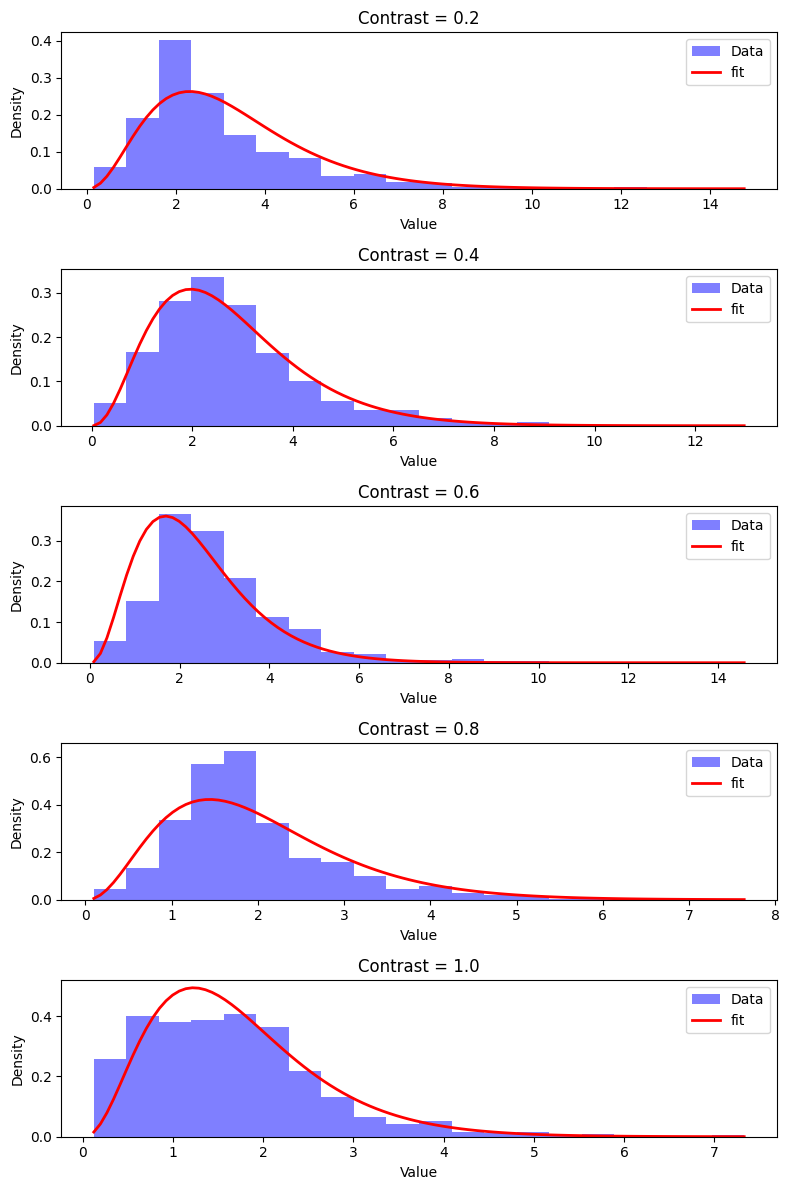

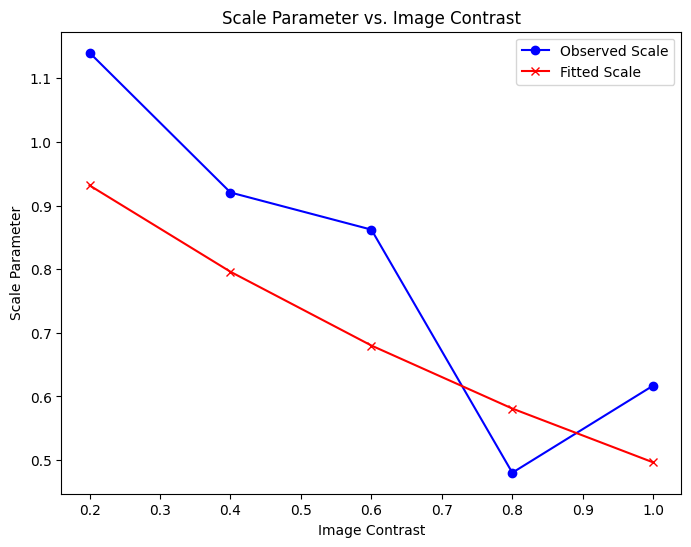

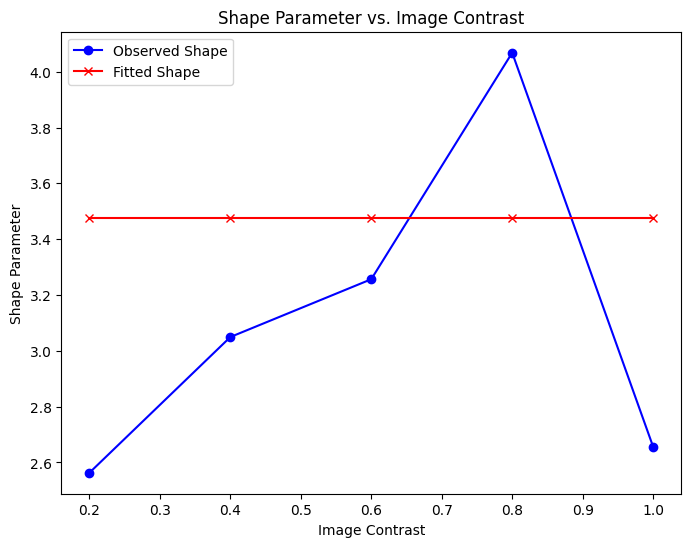

In [ ]:

# @title Gamma regression with binocular rivalry data {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm
from scipy.special import gamma as gammafunc
from scipy.stats import gamma as gammadist

def RivalryData():

    sample_size = np.zeros(5,dtype='int')

    sample_size[0] = 740;

    sample_0 = ([5.5853, 3.9241, 5.1557, 1.2603, 4.2964, 2.5778, 1.4178, 1.6756, 1.9620, 4.7117, 2.3630, 2.1052, 3.3941, 1.9763, 1.0025, 0.6731, 2.2485, 2.6352, 2.7067, 2.7497, 1.3462, 1.6899, 1.3605, 6.3730, 1.2747, 0.4296, 1.7902, 4.9552, 2.1482, 3.7665, 1.4178, 3.0505, 1.3032, 1.8474, 1.8045, 1.4465, 1.1027, 2.9072, 1.1027, 2.4924, 1.6494, 1.6127, 1.2095, 3.3354, 2.7856, 2.7490, 1.7962, 2.1992, 1.7594, 1.8326, 1.7958, 2.4191, 2.1992, 2.2358, 3.1155, 1.6860, 1.4296, 1.7958, 1.6862, 1.9793, 1.7594, 1.7593, 1.7227, 2.2358, 2.4924, 2.1992, 2.5657, 3.6286, 2.4191, 2.0892, 1.8693, 1.9793, 2.1992, 2.4191, 2.6392, 8.4669, 2.4191, 2.6757, 2.4924, 1.7960, 2.1992, 2.3459, 1.8328, 4.6183, 2.3825, 1.9794, 2.0892, 6.2677, 1.2462, 1.6860, 0.9896, 1.1363, 1.0996, 2.1991, 2.5291, 1.7227, 1.5394, 1.5394, 1.5394, 1.9426, 1.9793, 2.5291, 4.4717, 2.0892, 4.1783, 4.6183, 7.6972, 3.2621, 2.0526, 2.0893, 3.8486, 2.7121, 2.3091, 3.1888, 4.3984, 2.4924, 1.3561, 1.3195, 1.7593, 1.7593, 1.2096, 1.7228, 1.4295, 8.2836, 2.3824, 1.6860, 5.1681, 2.7122, 1.8327, 2.3091, 2.0159, 1.7227, 1.5394, 1.4294, 1.7594, 2.0157, 2.0526, 1.6127, 1.7594, 1.7961, 1.5394, 1.6860, 1.3195, 1.6860, 1.6494, 1.5394, 1.7960, 2.0892, 3.6651, 6.2308, 5.7912, 4.1785, 2.0892, 2.0892, 1.7593, 1.7593, 1.6860, 1.6128, 2.7490, 1.7593, 1.4661, 1.8693, 1.8693, 2.1992, 2.7856, 1.0263, 1.1731, 0.9896, 1.8694, 1.1729, 1.7593, 2.6390, 1.6494, 1.4296, 1.8326, 1.6494, 1.7592, 1.9794, 3.2621, 1.6494, 1.3195, 1.4295, 1.3930, 1.6494, 4.9114, 1.7593, 1.4295, 1.4294, 1.2096, 2.5290, 1.6860, 1.0263, 0.9530, 1.1729, 1.6494, 1.6127, 1.6129, 1.3928, 1.7593, 1.7593, 4.2884, 1.5028, 1.7960, 2.9689, 1.5397, 2.5291, 1.6494, 2.0526, 2.7490, 4.5450, 3.8486, 2.8589, 3.3721, 3.5899, 6.8561, 4.9481, 3.2017, 7.3412, 5.2068, 4.7540, 7.3736, 3.6221, 5.7242, 1.4877, 5.6919, 1.6170, 1.6494, 3.6221, 9.1199, 2.4255, 1.8434, 2.0698, 1.6494, 6.1123, 1.5847, 4.6570, 6.4034, 2.2315, 3.7191, 5.6272, 3.4604, 3.8808, 2.1991, 3.4604, 4.3336, 2.4255, 2.6196, 1.0672, 3.8808, 5.1421, 3.9132, 3.8485, 5.0127, 6.0476, 8.1174, 3.1370, 1.4553, 4.4306, 1.8434, 4.7217, 4.7540, 3.5251, 3.3310, 2.4255, 3.9132, 2.0372, 1.3583, 0.6792, 2.6519, 2.1991, 3.4281, 1.1644, 2.1021, 1.7787, 7.6970, 1.4876, 0.2587, 2.0374, 2.8136, 3.0076, 3.7838, 4.1395, 3.0723, 2.8460, 1.6303, 1.5397, 1.0718, 3.1399, 3.6683, 6.0836, 2.5662, 1.1171, 3.9853, 1.6757, 1.8115, 0.3321, 1.7209, 4.3476, 2.1134, 3.3211, 4.0759, 3.9853, 2.6871, 2.5814, 2.9890, 3.4871, 2.0077, 0.2264, 1.9474, 2.8078, 1.7662, 0.6340, 2.4757, 1.7209, 5.9176, 2.0832, 4.4382, 2.1738, 2.0379, 4.4231, 1.5247, 2.5814, 3.6683, 4.8321, 1.9329, 3.9480, 3.5162, 2.2002, 1.9534, 7.9165, 4.6882, 0.9253, 1.4805, 3.3517, 1.8095, 1.6861, 6.4977, 0.8636, 3.7218, 4.1330, 2.5497, 1.9329, 5.4902, 2.7142, 1.6861, 5.7780, 3.5367, 4.3798, 0.7197, 3.5573, 3.0844, 3.3517, 0.5132, 3.7289, 0.6414, 5.4565, 9.8525, 6.7308, 3.0532, 2.4460, 1.7533, 2.0783, 1.1289, 1.5138, 0.1539, 1.4368, 0.2993, 5.2170, 4.3019, 3.0447, 0.3678, 4.3789, 0.6928, 3.1559, 1.5037, 2.3630, 1.4178, 2.0480, 1.2889, 0.6874, 3.3226, 1.0311, 3.2939, 1.6326, 2.0623, 1.4608, 4.3107, 2.4919, 3.5660, 3.0361, 0.4726, 6.0579, 4.2105, 1.8904, 1.8904, 0.6445, 2.4346, 1.2030, 2.6924, 5.6569, 2.5922, 2.7927, 3.3942, 0.8593, 1.4751, 0.1575, 1.2603, 1.7329, 0.9882, 3.2223, 1.3195, 2.3458, 1.7593, 2.3091, 6.6709, 6.4509, 3.6287, 5.0213, 3.1888, 3.7752, 2.4193, 2.6024, 3.9585, 2.1992, 2.2725, 2.7123, 2.4557, 2.3826, 2.8223, 2.4923, 2.1992, 2.0892, 1.9060, 2.3092, 1.9793, 2.3091, 2.3092, 5.2781, 2.0526, 1.7593, 2.3091, 3.7386, 2.7490, 2.6390, 2.5289, 2.0892, 1.9793, 2.3091, 2.2358, 1.9426, 2.7490, 1.8692, 2.7489, 2.6757, 3.8486, 3.1887, 2.1992, 7.7338, 1.7594, 2.1625, 2.0526, 2.8589, 1.5028, 2.9689, 2.5287, 9.4198, 5.0581, 3.0789, 3.5553, 4.7283, 2.7856, 2.2725, 5.2047, 4.0685, 5.7545, 4.5083, 4.1784, 12.4254, 13.5983, 5.0948, 6.5243, 5.8278, 3.3353, 2.9322, 3.2257, 3.8486, 14.7712, 10.4095, 2.8956, 0.6964, 1.0630, 4.0685, 1.9793, 1.3562, 1.6127, 3.5553, 1.7592, 2.0892, 2.4191, 3.1888, 2.4191, 1.9794, 2.4558, 4.5083, 5.2781, 2.4191, 1.8693, 2.1993, 2.6757, 2.1626, 3.0789, 3.4454, 2.8956, 3.5187, 2.0891, 4.6916, 2.6024, 4.8382, 2.7123, 2.0892, 3.0788, 0.9530, 1.6496, 2.4193, 2.0159, 2.8956, 3.1522, 2.3091, 6.3043, 5.5713, 4.6183, 3.7386, 2.4923, 4.4716, 2.0892, 2.8589, 5.0215, 2.7490, 2.9689, 2.7123, 0.8797, 1.3195, 1.8691, 3.8486, 1.6860, 1.6494, 1.6860, 2.7123, 2.1992, 1.9058, 1.8693, 1.4296, 1.9060, 2.4190, 2.1992, 1.8693, 1.6860, 1.4661, 1.7592, 2.0160, 7.3673, 2.1992, 1.4662, 1.9426, 4.7283, 6.1211, 5.4613, 3.8486, 2.4558, 2.9689, 2.1259, 2.5291, 3.3352, 6.3776, 2.6390, 2.4191, 3.6653, 2.1259, 2.8223, 2.4191, 6.5973, 12.2054, 7.9537, 2.3458, 3.2621, 9.5298, 4.5083, 7.8437, 3.6867, 2.0374, 1.7140, 6.5004, 2.5225, 1.7140, 3.2987, 7.2442, 6.1123, 6.4034, 2.0051, 8.5378, 5.1421, 4.8510, 3.7838, 2.6843, 1.0672, 2.8783, 1.5200, 1.7140, 0.3234, 7.0825, 2.4902, 3.3957, 5.3038, 1.1966, 6.2093, 4.7540, 3.9132, 1.4553, 3.9778, 3.7515, 2.1345, 1.1643, 5.2068, 5.2391, 2.4902, 3.1370, 7.2766, 7.5028, 3.2987, 5.5302, 3.3633, 7.1795, 4.5600, 4.6893, 2.7489, 3.6868, 4.5600, 2.6519, 1.7140, 1.3260, 1.1966, 2.5225, 1.9081, 1.2613, 1.8757, 2.2315, 4.2689, 1.4553, 1.8111, 2.0373, 2.1345, 4.4953, 4.3659, 3.0400, 4.3659, 4.5600, 5.0774, 3.1047, 2.3283, 3.1852, 2.0077, 0.5887, 2.1436, 0.4076, 2.8682, 4.7401, 3.9098, 2.5059, 1.9474, 2.4002, 2.8984, 2.9890, 2.3248, 3.6382, 2.2493, 3.2909, 5.2383, 2.5361, 3.1097, 1.5851, 2.7927, 0.6944, 2.3097, 0.4982, 2.7927, 3.6230, 3.0041, 2.5210, 2.4002, 2.1134, 2.9286, 2.4757, 0.5887, 2.7022, 0.3774, 2.7776, 2.7965, 3.6807, 0.5552, 1.5422, 1.4188, 7.1763, 4.1947, 4.1330, 1.6861, 2.0974, 2.7759, 2.8582, 1.8506, 0.9870, 2.5497, 2.1590, 7.3613, 3.0638, 4.6882, 2.2619, 4.9966, 2.4058, 4.2564, 4.2564, 4.8116, 2.7348, 2.2493, 2.6427, 4.3618, 3.5835, 3.0618, 2.4888, 1.7960, 0.7783, 1.1460, 0.8125, 1.8901, 5.2170, 1.6421, 3.0789, 2.6513, 1.4112, 2.3177, 1.0349]);

    sample_size[1] = 764;

    sample_1 = np.array([2.3487, 5.2703, 0.0430, 1.6326, 3.3082, 5.1557, 2.0480, 4.1675, 3.9813, 2.6638, 0.7017, 3.3369, 3.3512, 6.5019, 1.2603, 3.9097, 6.8313, 0.9166, 6.9602, 3.5087, 3.6806, 5.5710, 0.6015, 0.7304, 5.5710, 0.8736, 0.1718, 2.2341, 3.2366, 2.1339, 3.4371, 1.2889, 3.7808, 2.1768, 1.0629, 1.3196, 1.3195, 1.8327, 1.7594, 2.0526, 4.1785, 1.9426, 2.1992, 5.4979, 2.2725, 4.1784, 2.6024, 4.9481, 3.1155, 2.6390, 2.7490, 2.1992, 2.8589, 4.6549, 3.8852, 3.1888, 3.2988, 2.3458, 5.4980, 3.1155, 2.4191, 3.3354, 1.1362, 3.2988, 2.2725, 1.5761, 5.0215, 1.9059, 2.6390, 4.4717, 2.4924, 2.7490, 3.4087, 2.5657, 7.9904, 3.0421, 2.0526, 1.9793, 1.0996, 1.8327, 1.6860, 1.7960, 1.8693, 1.8327, 2.0159, 2.0159, 2.3458, 1.7960, 2.3092, 2.8589, 2.1259, 3.3354, 2.0526, 2.2358, 2.8589, 2.3458, 2.9322, 3.0422, 2.8956, 2.8589, 1.7593, 2.3091, 2.0892, 2.6390, 1.8693, 1.8693, 2.4558, 2.6390, 3.2988, 2.7490, 3.1888, 3.5920, 6.1577, 1.9793, 2.1992, 2.3091, 2.5291, 1.9426, 1.8693, 1.8693, 1.0996, 1.2828, 1.4661, 1.3562, 1.8693, 1.8693, 1.6858, 1.6860, 1.5761, 1.6860, 1.8693, 1.8327, 1.6127, 1.6127, 1.7593, 2.8956, 2.3091, 2.2358, 2.3458, 2.7491, 1.8324, 2.4558, 2.2358, 1.7227, 1.9793, 1.7594, 2.1992, 3.1888, 2.1992, 2.4190, 2.7490, 3.7386, 4.2518, 1.4295, 1.7227, 4.3984, 2.4188, 2.5291, 2.2361, 1.7593, 1.7227, 3.2988, 8.9433, 1.3928, 1.6494, 1.5028, 1.4295, 1.4295, 1.3928, 1.5394, 1.4295, 1.4661, 1.2829, 1.8693, 2.6390, 2.1625, 1.7227, 2.0892, 2.3091, 1.5761, 1.3928, 2.0892, 1.7960, 1.7593, 2.0159, 2.7856, 1.9793, 1.9793, 1.9426, 2.4924, 2.1625, 2.2358, 3.0788, 2.2358, 1.8327, 2.3092, 1.8326, 1.6861, 1.7960, 2.3825, 1.4295, 2.3458, 2.3091, 2.4924, 2.4191, 3.3354, 2.7490, 2.7490, 2.1668, 3.8485, 3.0076, 1.4552, 2.0374, 1.7787, 6.5004, 0.9055, 2.2315, 4.2689, 3.4604, 4.4306, 3.0077, 3.3310, 3.7838, 2.3285, 6.6944, 3.5898, 4.3659, 5.8859, 3.5574, 0.5821, 1.0672, 1.2613, 1.2289, 2.3932, 2.0374, 2.9106, 0.8085, 1.2936, 3.9455, 3.5898, 3.0723, 2.4902, 2.7166, 2.1021, 1.5847, 2.8136, 1.9081, 2.1668, 2.7489, 2.0374, 2.2962, 3.6868, 2.7166, 2.5549, 1.1644, 0.9379, 1.7142, 5.4331, 3.0723, 0.9379, 1.5200, 1.7464, 1.7787, 2.1021, 2.6196, 1.4553, 2.9430, 3.1370, 4.3983, 0.8732, 4.2689, 3.8808, 3.1047, 4.0749, 1.2613, 0.8732, 4.6893, 1.0996, 1.2613, 2.1021, 0.8732, 2.7489, 1.6170, 3.2340, 2.5227, 0.3234, 1.2613, 4.0749, 2.7813, 1.9404, 1.1643, 1.8111, 4.6247, 2.5549, 2.6719, 3.6834, 4.3929, 2.3549, 3.3965, 1.8719, 2.0228, 2.4756, 3.9400, 1.1926, 0.9510, 2.9739, 3.5022, 0.4830, 5.2986, 5.3892, 2.2342, 1.6304, 1.3133, 1.3888, 1.2982, 0.4982, 1.6304, 1.5398, 1.2681, 4.1665, 6.0685, 2.4908, 3.7136, 1.0416, 1.2954, 4.5032, 1.8506, 2.3235, 0.6580, 4.3387, 4.2564, 1.0898, 0.7608, 1.9329, 3.0021, 1.3777, 0.9664, 2.5292, 0.8431, 2.3235, 1.3777, 4.8527, 1.6244, 0.9048, 0.2879, 3.3311, 1.4805, 1.6244, 3.0844, 2.2617, 3.2283, 1.3982, 2.6320, 1.0076, 3.3928, 0.2468, 4.7499, 0.8842, 2.5292, 3.5367, 2.7142, 2.4058, 3.4339, 0.5140, 3.8572, 10.9985, 4.3190, 5.0289, 0.3592, 1.6421, 3.0276, 3.3697, 1.5908, 2.9250, 5.4650, 3.2927, 5.6960, 1.5737, 2.8565, 3.8572, 3.1986, 2.8480, 2.0909, 3.1937, 2.5635, 3.0934, 3.0075, 3.1221, 2.2198, 2.2055, 2.5062, 0.6731, 1.9763, 1.4608, 0.6874, 3.1364, 3.0361, 0.5988, 1.1743, 1.0455, 2.4060, 1.0455, 0.9882, 0.9452, 2.4060, 2.1766, 1.2460, 1.5467, 0.2148, 2.1482, 0.5156, 1.8188, 0.7697, 1.6860, 2.0525, 1.1362, 2.4191, 1.9426, 4.7282, 2.1259, 2.4191, 2.5657, 2.6390, 1.5761, 3.6287, 1.5394, 3.6287, 2.1625, 3.8486, 2.3458, 2.3824, 6.8175, 4.7649, 2.3824, 2.6390, 1.7227, 1.1729, 2.6390, 3.1522, 2.3091, 3.5920, 4.6183, 2.8589, 6.4143, 3.2621, 2.8956, 3.3721, 3.1155, 3.1155, 2.7490, 5.1681, 2.6390, 2.3091, 5.4247, 1.7960, 2.0892, 1.4661, 1.8693, 1.8326, 1.9793, 2.3091, 2.0892, 2.3824, 2.1625, 2.2725, 2.3824, 3.4087, 3.0789, 4.5816, 2.9689, 3.6653, 3.9585, 3.5920, 12.9752, 2.8956, 2.5291, 5.0215, 4.9482, 1.8693, 1.0996, 3.8486, 4.0685, 4.0685, 2.6757, 3.7019, 4.3984, 3.0788, 6.5976, 4.8749, 5.4980, 3.3354, 6.3410, 4.7282, 8.7967, 8.5402, 3.1155, 3.6286, 0.9896, 1.6861, 1.8693, 1.9426, 2.1625, 2.5291, 2.0894, 2.8223, 6.4509, 2.9322, 2.1625, 2.6757, 2.4558, 3.2988, 3.6287, 7.2573, 4.9482, 4.4717, 6.4876, 2.0526, 3.1522, 6.0845, 3.1888, 4.6916, 4.1785, 2.4557, 4.5083, 5.8278, 2.6757, 2.1992, 2.1260, 3.8119, 3.4820, 5.4980, 5.3880, 2.0892, 2.6393, 3.2988, 4.4350, 4.0315, 2.2358, 0.7697, 4.5083, 3.0422, 0.8064, 2.3091, 3.5554, 2.3091, 2.3091, 3.0789, 5.1681, 2.4924, 6.2677, 9.0166, 2.7490, 2.3091, 2.0159, 2.7856, 4.2151, 3.0422, 7.0374, 3.9585, 2.7856, 2.6024, 6.3776, 2.0892, 2.6024, 4.2517, 2.3091, 2.3458, 2.5657, 4.8749, 2.5290, 3.0789, 5.3513, 8.0270, 3.2988, 2.6757, 1.6494, 4.0684, 3.5187, 6.3776, 3.4087, 3.7020, 7.6238, 6.8541, 2.8223, 4.4717, 2.5291, 1.5847, 1.1319, 0.9055, 2.1345, 1.4876, 1.8111, 2.1668, 1.4876, 1.9404, 2.6842, 4.4628, 2.8459, 2.8459, 2.6519, 2.8459, 3.6221, 1.8434, 2.4579, 2.4578, 3.5898, 3.3957, 3.4927, 0.9702, 1.2288, 0.9702, 2.4255, 0.8408, 3.0076, 1.0672, 1.1642, 2.3285, 1.2289, 2.7489, 2.5549, 2.4255, 1.2936, 1.4230, 1.4553, 2.1345, 1.3583, 1.2613, 2.5872, 1.2613, 1.9081, 0.9702, 1.0672, 2.1991, 2.8783, 3.5898, 2.8136, 0.5820, 1.4877, 2.5225, 3.3957, 6.7915, 2.8459, 2.0698, 3.6868, 2.8136, 1.5847, 2.8459, 2.5226, 2.8136, 0.2911, 4.5600, 2.7166, 2.8783, 3.0076, 3.5251, 3.7191, 4.1396, 2.6196, 3.1047, 0.7762, 1.6493, 1.3583, 1.7787, 6.2740, 4.3013, 3.1047, 4.9480, 3.1370, 7.5999, 2.4578, 3.4281, 9.3140, 2.4579, 2.6196, 3.1370, 6.5004, 4.2042, 4.3336, 4.7540, 1.9404, 3.7136, 4.9816, 6.4761, 4.4231, 1.3133, 0.3019, 0.5284, 3.1852, 2.7474, 1.9323, 0.3623, 0.9963, 0.9360, 2.0379, 3.2154, 3.2154, 7.6385, 1.4945, 2.6116, 0.2264, 3.8192, 2.2342, 10.0085, 1.2680, 2.7474, 2.1285, 0.2566, 4.4533, 3.7438, 3.2305, 1.5398, 5.9327, 8.4386, 3.0796, 2.4002, 5.0583, 1.6039, 1.7478, 2.1590, 5.6341, 4.5854, 4.5443, 2.5497, 1.7272, 2.0357, 4.4003, 1.3982, 3.0844, 1.5422, 1.4805, 0.8019, 2.9404, 3.0021, 0.4729, 3.5162, 3.9068, 2.8377, 4.4415, 2.6937, 2.8993, 3.7012, 4.5648, 2.8787, 1.0898, 4.9350, 2.3852, 0.8636, 3.4339, 0.7402, 5.3282, 6.8848, 4.2591, 0.8467, 3.1986, 1.5138, 2.9848, 3.8315, 3.0276, 3.5236, 3.1302, 1.5822, 1.6677, 2.3605, 2.2579]);

    sample_size[2] = 776;

    sample_2 = np.array([3.1650, 3.2366, 2.7497, 0.6301, 4.2821, 2.4919, 3.4371, 3.8238, 1.8045, 2.2055, 3.3369, 2.0193, 0.6015, 1.4035, 1.2746, 3.6949, 2.0193, 2.2485, 3.0504, 2.8356, 6.1868, 0.8163, 0.5156, 2.4919, 0.4440, 5.9720, 3.7952, 3.8668, 4.5112, 3.5947, 5.3991, 3.7522, 4.4682, 1.6899, 5.5710, 3.1364, 1.6127, 1.8693, 1.8327, 1.9059, 1.7227, 1.9060, 1.6494, 2.6390, 2.6390, 3.0422, 3.1888, 3.0788, 2.8589, 2.7490, 3.7020, 2.6390, 2.9322, 1.9426, 2.6024, 2.5657, 1.5394, 1.8693, 1.9425, 2.0892, 2.0892, 2.8589, 2.2725, 4.9848, 2.7490, 2.6757, 7.2573, 2.2358, 3.5187, 3.4087, 3.4821, 4.1051, 2.4924, 3.2621, 5.7179, 8.8334, 3.6286, 1.2097, 1.3195, 1.9426, 1.5761, 1.8327, 1.7593, 1.8327, 1.7593, 1.5394, 2.2725, 2.7490, 2.5291, 2.0892, 2.0892, 2.6024, 2.5291, 1.7594, 2.4924, 1.6860, 1.6860, 1.7227, 1.9793, 2.0526, 2.1992, 1.9426, 1.8693, 1.5395, 1.6860, 2.6757, 2.1259, 1.7594, 1.9426, 2.3091, 2.0892, 2.0159, 3.4454, 3.9585, 4.6183, 2.1992, 1.6860, 2.3458, 2.7856, 1.9793, 2.6389, 1.2095, 1.2829, 1.6494, 1.6127, 2.1259, 1.5761, 1.4295, 1.9060, 2.1625, 3.5187, 1.7958, 1.9793, 1.5761, 1.4296, 2.0892, 1.6860, 2.6024, 2.9689, 1.7593, 6.4876, 3.1888, 3.1888, 3.0789, 2.3458, 3.0789, 1.8693, 1.6494, 2.1992, 4.4717, 2.3824, 1.7594, 2.3458, 1.9426, 2.8956, 2.1259, 1.9793, 2.6024, 1.8693, 2.6757, 4.1784, 1.9792, 2.6390, 1.2096, 2.7490, 3.2988, 3.6286, 2.4924, 2.3091, 1.5028, 1.6494, 1.9793, 1.6494, 1.5761, 1.5763, 1.5394, 1.3195, 1.5394, 2.1992, 2.1259, 1.7227, 2.1259, 2.1992, 3.1522, 2.7123, 2.9689, 2.9322, 2.3824, 2.5657, 1.4295, 2.4191, 2.4924, 1.3195, 3.8852, 1.3192, 1.6860, 1.5394, 1.6494, 2.5291, 3.4087, 2.6024, 2.7856, 2.1992, 1.4295, 1.7227, 1.8693, 1.9426, 1.7960, 2.4191, 2.3091, 2.4191, 2.1992, 3.6287, 1.8327, 2.8223, 1.7227, 1.5523, 2.3285, 2.2638, 1.7464, 2.0374, 2.6519, 4.4953, 3.3957, 4.4306, 2.7489, 2.5225, 1.2936, 2.2962, 3.2017, 4.2366, 1.9727, 3.1047, 1.9081, 1.0672, 1.4553, 4.5923, 4.6570, 4.2366, 4.1072, 2.2315, 3.1693, 1.9081, 1.5847, 0.9055, 2.6519, 6.6944, 3.2987, 3.5898, 3.6868, 0.1940, 2.2961, 1.2613, 3.6221, 2.2315, 3.2340, 2.1345, 4.2042, 5.1097, 2.5872, 3.6868, 4.0749, 0.7438, 0.9702, 2.7166, 14.5855, 6.0153, 5.8859, 9.7344, 6.9208, 4.8511, 6.0476, 9.0229, 4.5600, 4.5600, 6.3710, 4.4630, 4.9804, 0.6791, 0.2264, 0.7762, 0.5174, 1.6817, 0.8732, 2.5225, 0.5498, 4.1719, 1.6170, 2.7167, 2.7166, 1.5847, 1.1643, 6.4034, 1.0349, 1.8434, 1.1641, 2.3285, 1.0349, 1.9404, 1.4230, 1.5200, 1.7464, 0.8732, 0.9058, 0.8303, 0.7548, 1.2530, 0.8152, 2.1738, 2.5210, 3.9098, 1.9927, 0.4529, 2.0077, 3.8042, 2.0379, 2.8682, 2.1436, 4.4231, 1.2379, 0.3472, 3.1248, 4.7703, 0.7246, 3.7589, 0.8001, 1.6002, 4.1815, 1.7360, 1.9323, 4.5740, 3.7589, 3.7740, 3.9400, 3.1852, 4.9212, 2.9739, 2.2413, 3.3928, 0.9664, 3.8863, 4.8527, 2.1179, 2.9610, 2.6525, 1.2954, 2.0974, 1.6245, 1.6244, 7.5465, 2.2207, 2.4880, 1.5833, 0.4318, 1.8506, 3.0227, 1.3571, 3.2694, 2.4264, 3.7424, 1.6861, 2.7348, 2.1590, 2.9610, 1.6039, 2.8052, 4.1480, 4.2677, 2.2835, 4.4644, 1.4881, 4.1309, 2.9934, 0.3079, 2.8223, 3.6263, 1.6421, 1.1802, 4.5927, 2.1809, 3.5407, 1.1118, 2.0098, 2.8309, 1.4112, 1.9500, 1.6934, 3.2157, 3.0019, 1.4608, 2.9788, 3.2366, 2.5922, 2.1912, 3.5087, 1.5897, 2.8929, 1.6756, 2.7497, 1.9334, 1.2889, 2.6208, 2.0050, 3.4228, 2.7354, 1.3319, 1.8904, 3.4228, 2.6638, 3.0504, 2.7354, 0.5012, 2.1482, 3.2223, 1.7329, 2.4489, 0.0859, 2.3344, 3.2254, 1.6494, 1.6860, 1.7593, 1.6494, 5.0581, 2.4924, 2.5291, 2.5657, 2.7856, 3.2988, 3.9952, 3.4820, 5.8645, 2.6390, 3.2988, 3.3354, 3.6653, 2.4191, 4.5450, 3.1522, 3.0055, 1.8693, 1.8327, 0.7697, 2.0892, 1.7594, 3.0789, 2.4557, 2.4191, 2.1625, 2.1992, 3.1888, 4.5816, 1.6494, 2.5657, 2.9689, 3.1155, 2.3458, 4.0318, 2.6024, 3.7017, 2.0891, 3.0055, 3.6286, 2.7490, 2.3091, 2.4557, 3.1888, 2.1992, 2.0159, 3.0789, 2.3091, 3.1888, 2.8589, 4.9848, 5.2780, 2.3091, 3.9952, 5.0581, 5.1314, 2.7856, 2.8589, 3.2255, 4.5083, 7.7338, 6.4876, 3.6287, 4.5082, 4.3617, 4.9115, 3.2621, 2.4557, 3.9585, 2.3091, 2.4557, 4.6916, 4.8382, 3.5920, 3.7386, 2.7490, 2.3824, 8.5402, 3.7386, 3.4088, 5.6446, 1.5761, 1.8693, 2.1259, 2.5291, 1.8327, 2.0159, 2.2725, 1.9793, 2.9689, 2.6392, 2.0892, 5.1681, 2.0892, 1.8325, 4.1785, 5.3880, 3.5187, 2.0892, 3.6287, 2.9689, 2.6757, 2.7856, 2.6024, 5.0215, 3.4087, 2.0892, 2.1258, 1.9793, 2.5657, 1.8693, 2.4191, 2.9689, 3.2988, 8.6501, 2.0892, 2.6757, 4.3250, 2.7490, 2.3091, 2.1625, 2.7490, 0.6597, 0.9163, 2.2725, 1.6494, 2.5657, 1.9792, 1.0263, 1.4295, 1.7594, 2.0159, 2.4191, 4.0318, 5.1312, 3.4087, 3.2988, 3.6287, 3.7386, 2.6024, 2.3091, 3.8119, 2.7856, 3.2255, 3.5187, 2.4558, 2.4558, 2.5291, 2.7856, 2.7856, 3.1522, 3.6286, 3.1888, 11.5091, 1.8327, 1.8693, 2.5291, 2.4191, 2.1992, 8.7601, 3.0055, 3.2255, 3.9585, 3.9952, 2.8589, 3.1522, 2.8589, 3.1888, 2.9689, 3.6287, 2.6390, 2.6757, 3.8852, 4.0685, 1.1966, 1.3906, 1.4553, 1.6170, 1.5523, 2.2638, 3.2987, 1.7142, 4.5600, 1.1643, 5.4332, 4.2689, 2.9106, 2.8136, 4.4630, 1.4553, 3.0076, 3.0076, 3.5573, 2.1345, 8.1821, 4.3659, 3.7838, 5.9183, 1.5523, 1.9727, 2.8136, 1.6494, 1.5523, 3.5898, 3.2017, 5.3361, 3.4927, 1.2938, 4.4630, 1.9404, 1.2613, 3.5898, 1.0026, 3.0076, 1.5200, 3.2987, 2.8136, 3.4281, 1.0026, 2.8783, 1.0672, 3.8485, 4.9481, 4.1072, 2.0374, 4.2042, 0.7762, 8.0527, 4.0102, 5.1098, 4.4630, 5.5302, 3.1370, 4.5923, 4.3983, 1.9404, 8.6348, 5.6595, 1.4877, 2.6196, 5.2391, 3.8485, 2.3285, 2.2638, 9.9285, 0.6791, 0.9379, 0.9702, 1.3583, 0.8732, 1.9404, 3.6868, 2.9106, 3.4281, 2.6519, 9.1523, 3.7515, 1.3260, 2.2315, 2.8783, 2.8136, 1.4877, 1.0025, 2.1021, 2.6519, 2.1345, 1.2228, 1.2228, 1.2681, 2.2493, 0.8152, 2.2946, 2.9739, 3.5022, 2.4606, 2.5814, 0.4982, 3.7890, 4.6193, 1.4945, 1.2681, 2.8229, 1.5851, 2.8531, 2.8984, 2.6267, 4.3174, 1.9927, 2.4002, 2.7173, 2.5059, 1.8568, 1.8719, 3.8494, 5.6308, 3.8041, 4.6344, 2.8078, 5.8723, 0.6793, 0.4529, 4.8527, 3.7835, 3.3928, 3.5162, 6.1481, 1.4599, 1.3982, 1.9123, 3.2694, 2.5292, 3.6190, 0.9664, 7.5875, 6.2304, 3.4339, 4.6265, 4.9966, 4.6265, 2.2824, 6.6622, 3.8863, 2.4881, 3.6395, 3.3517, 2.1179, 2.7554, 3.5573, 2.9815, 2.1590, 4.1330, 1.8730, 2.4375, 0.2138, 3.5578, 2.1894, 1.5394, 1.0605, 1.4112, 2.1723, 4.0368, 1.4710, 1.1546, 0.8210, 2.0269, 0.5474, 1.5223, 1.0263, 0.7184, 1.7019, 1.4368, 2.7796, 1.4881]);

    sample_size[3] = 1159;

    sample_3 = np.array([0.5729, 2.5778, 3.8811, 1.0311, 2.7927, 2.2485, 0.9882, 2.9931, 0.6445, 1.8904, 3.2080, 3.3512, 0.8450, 3.4801, 1.6326, 1.9620, 2.0766, 1.2889, 2.3918, 1.0311, 1.7615, 1.5181, 2.2485, 4.0100, 0.9882, 2.3057, 6.1009, 5.1557, 5.4278, 0.9452, 1.3748, 6.1439, 2.1482, 2.8356, 3.7952, 2.1339, 1.5324, 2.7497, 1.0263, 1.2096, 1.4295, 1.3194, 1.3928, 1.4661, 1.2830, 1.3928, 1.6863, 1.7960, 1.5394, 1.7227, 1.4295, 1.5394, 1.5761, 1.6860, 1.5394, 1.5394, 1.6127, 1.7593, 1.8693, 1.4295, 1.4295, 1.3562, 1.5394, 1.8327, 1.3195, 1.2462, 1.4661, 1.5761, 1.5394, 1.6494, 1.5394, 1.7960, 1.8327, 1.2096, 1.6860, 3.5553, 1.7593, 1.5761, 1.5028, 1.7227, 1.6494, 1.5394, 1.4295, 1.3562, 1.7593, 1.8693, 1.6494, 1.7593, 1.9060, 2.0159, 1.9426, 1.9059, 2.0892, 1.6494, 1.9793, 1.8693, 1.8326, 1.8693, 1.8327, 2.0526, 1.5761, 1.9793, 1.8693, 1.4295, 1.5761, 1.8693, 1.5395, 0.7697, 0.7697, 1.2096, 1.0996, 1.0263, 1.5028, 1.0265, 1.1729, 1.3928, 1.0996, 1.2096, 1.4295, 1.3928, 1.0996, 1.2096, 1.3562, 1.4294, 1.1729, 1.4295, 1.0263, 1.5028, 3.4820, 1.5028, 1.4295, 1.3195, 1.3928, 1.3195, 1.6494, 1.2462, 1.6494, 1.4298, 1.3195, 1.7593, 1.7593, 1.4661, 1.8327, 1.5028, 1.5761, 1.7960, 1.6494, 1.7593, 1.4661, 0.6598, 1.5028, 1.2829, 1.5028, 1.1362, 0.6598, 1.5028, 1.1362, 1.5761, 1.3928, 1.1362, 1.3195, 1.7593, 2.1625, 1.8693, 1.9793, 1.9793, 1.9793, 1.9060, 1.9793, 2.0159, 1.3195, 1.4661, 1.2829, 0.8064, 1.0263, 0.8797, 1.0996, 1.0629, 1.0263, 1.0996, 1.0996, 1.3195, 1.5394, 1.4661, 1.2095, 1.2095, 1.0996, 1.3195, 1.2096, 1.2095, 1.2096, 1.6494, 1.6494, 1.3195, 0.9896, 1.3195, 1.5028, 1.2095, 1.3562, 1.3195, 1.5394, 1.9793, 1.2096, 1.2462, 1.3562, 1.2095, 1.2095, 1.0996, 1.2829, 1.0996, 2.3091, 1.2095, 1.1729, 1.3928, 1.5394, 1.7960, 1.0263, 0.8797, 1.4661, 1.2462, 1.6860, 1.4295, 2.1992, 3.0788, 1.6127, 1.9793, 1.5394, 0.8797, 2.7490, 1.0996, 0.8064, 1.2096, 1.4295, 1.2096, 0.5498, 1.3928, 1.1729, 2.0892, 2.1625, 1.4295, 1.9793, 1.0996, 1.1362, 1.3562, 1.2829, 1.2462, 1.5028, 1.4295, 1.0996, 1.5394, 1.5394, 1.3195, 1.4661, 1.2462, 1.4661, 1.5394, 1.4295, 1.2829, 1.2095, 1.2095, 1.0996, 1.3195, 1.6860, 1.6494, 1.7227, 1.6494, 1.4661, 1.5394, 1.7593, 1.6494, 1.4662, 1.5394, 1.3195, 1.5394, 1.9793, 1.9793, 2.7856, 1.7960, 0.8064, 1.7960, 2.0526, 1.8327, 1.7227, 1.4661, 1.5394, 1.5028, 1.3928, 1.6860, 1.3195, 1.5028, 1.5761, 1.6494, 1.5394, 1.6494, 1.7593, 1.7227, 1.7227, 1.6127, 1.7227, 1.7227, 1.9060, 1.9426, 1.7593, 2.3458, 1.9793, 1.4295, 1.7227, 1.5394, 2.0892, 2.0159, 2.0892, 1.5394, 1.7227, 2.0892, 1.6127, 1.9060, 1.9793, 1.8327, 1.9793, 2.1992, 1.6494, 1.9793, 1.9060, 2.1259, 2.0051, 2.1668, 1.4876, 1.6170, 3.7838, 1.4553, 0.9702, 3.0723, 2.2315, 3.0076, 1.7141, 2.5872, 2.1668, 1.3259, 3.8808, 1.8757, 1.9728, 0.6791, 2.1668, 2.3285, 1.3583, 2.2962, 1.8757, 2.1668, 3.1370, 2.7166, 3.1694, 1.0025, 1.4553, 0.8409, 1.5200, 1.5523, 1.8111, 2.2315, 1.9728, 1.4553, 2.1345, 1.3259, 2.7163, 2.5225, 1.3260, 2.2638, 1.6817, 1.2613, 1.9081, 4.1719, 2.6195, 2.5549, 2.2315, 2.7489, 1.5523, 1.1966, 3.2987, 2.2962, 2.6519, 3.2664, 1.3260, 2.7489, 3.2987, 3.2987, 4.5923, 3.4604, 2.6842, 2.4255, 0.7438, 1.0025, 3.2987, 3.7838, 2.8136, 4.5276, 3.1047, 4.9481, 2.2315, 1.4553, 1.0996, 1.7787, 0.7762, 1.2289, 1.5523, 1.9404, 1.9081, 3.1047, 3.0076, 1.7140, 0.9702, 3.6868, 2.6844, 4.1716, 0.8732, 3.7515, 1.1643, 2.5549, 2.0374, 2.0374, 3.0076, 1.3906, 2.8136, 2.9753, 3.9778, 1.6493, 1.6493, 2.7166, 2.3285, 2.1021, 3.3633, 2.0698, 2.1991, 3.2017, 2.7813, 1.4553, 5.2715, 3.2664, 4.3659, 2.9106, 1.9404, 2.6519, 3.1370, 4.7540, 1.6817, 4.6247, 4.2689, 2.7813, 0.9055, 0.3557, 0.6791, 0.4528, 0.7762, 0.9702, 1.1643, 1.6493, 1.3583, 2.2638, 1.0349, 1.0672, 1.4553, 2.1021, 1.2613, 0.9379, 0.7761, 0.8408, 3.9778, 1.1966, 1.0349, 2.4255, 2.7166, 1.8434, 2.3608, 0.9702, 2.0698, 1.8434, 3.1047, 2.8459, 1.1171, 1.5398, 2.1285, 3.1248, 1.7964, 3.2607, 1.6907, 2.4002, 1.3133, 2.9890, 1.9927, 2.2191, 2.5361, 1.4492, 0.5434, 1.3586, 3.1248, 2.1436, 3.0343, 0.2415, 1.2077, 0.5284, 0.7699, 0.3774, 1.2228, 3.0343, 0.4227, 1.6002, 4.9363, 6.1591, 1.5851, 0.6340, 0.6793, 1.4190, 0.2717, 0.9058, 1.3435, 2.2644, 2.4757, 0.6038, 2.9588, 2.6569, 1.1104, 0.9253, 1.1926, 1.2954, 3.2077, 3.1666, 1.1104, 1.5216, 1.0487, 2.1590, 1.6244, 1.3571, 3.1872, 2.0357, 1.4807, 0.3701, 1.7683, 3.1872, 3.2927, 1.4625, 2.3862, 0.8467, 3.4124, 2.3519, 2.8993, 1.8559, 1.7704, 1.8644, 0.6158, 0.9493, 0.9836, 0.7954, 1.1375, 1.6421, 3.2243, 2.8736, 2.1210, 2.8822, 3.9256, 1.4796, 1.1289, 1.2059, 1.1717, 1.7105, 0.8980, 1.0520, 1.1375, 1.8987, 0.3849, 0.5901, 0.9664, 0.9452, 3.4371, 1.3749, 2.0766, 1.8475, 0.3867, 1.9763, 1.5181, 3.4371, 2.3057, 1.3032, 1.1742, 1.1887, 2.1052, 1.9477, 0.6445, 0.8306, 0.6158, 0.2005, 1.8475, 2.6065, 4.6831, 1.2889, 2.6781, 1.3319, 1.2030, 1.8188, 3.9527, 2.4060, 4.2964, 1.1600, 2.8786, 1.4178, 0.6597, 1.1729, 1.5394, 1.8694, 1.7960, 1.8693, 1.8693, 1.7958, 1.5394, 1.7225, 1.5394, 2.3458, 1.8693, 2.1259, 2.0526, 1.8327, 1.9426, 1.6860, 2.4191, 1.9793, 1.8693, 2.0892, 2.3091, 2.5291, 2.4924, 3.9951, 3.5187, 1.7593, 2.0526, 2.1625, 1.7593, 1.9426, 1.9059, 2.0892, 2.3091, 5.4979, 2.9689, 4.5816, 0.7331, 1.9793, 2.6390, 1.7960, 1.7593, 2.0892, 1.7594, 1.7593, 1.8327, 1.6494, 1.8693, 1.7593, 1.8693, 1.9426, 2.1992, 1.9793, 2.5291, 2.4191, 1.8693, 2.6757, 2.5291, 2.0892, 1.7960, 2.0159, 1.3195, 1.6127, 2.3458, 2.3824, 1.8693, 2.0892, 1.8326, 0.9163, 1.3928, 1.2096, 1.6494, 1.7593, 1.8693, 1.8693, 1.8691, 1.7960, 1.7593, 1.7593, 1.7593, 2.0159, 1.7960, 2.2725, 1.8693, 2.2725, 2.0159, 1.9060, 1.5394, 1.7594, 2.2358, 2.0159, 4.2151, 2.1625, 2.0159, 2.3091, 2.5291, 1.7227, 2.4924, 2.8589, 1.6494, 2.4188, 2.0892, 1.7960, 1.9426, 2.3091, 2.1259, 1.9793, 2.2725, 3.9219, 2.6390, 2.1992, 2.9322, 1.6860, 2.2725, 3.9952, 1.9793, 3.9219, 3.0055, 2.0892, 2.2725, 3.0789, 2.5291, 2.9322, 2.4191, 2.6757, 2.3091, 2.8589, 2.3091, 2.4191, 2.7490, 2.4191, 2.9322, 2.3458, 2.5657, 3.9219, 2.3091, 2.4191, 0.8430, 1.8326, 1.7227, 1.6494, 1.4661, 1.8693, 1.5028, 1.6494, 1.7593, 1.5394, 1.6494, 1.5028, 2.0892, 1.8693, 1.7593, 1.9792, 1.5394, 1.4661, 1.8326, 1.6494, 1.4661, 1.3928, 1.9060, 1.6494, 1.5394, 1.7593, 1.7593, 1.6494, 2.6390, 1.7593, 1.5394, 2.0526, 2.0526, 1.8693, 1.7960, 2.4191, 1.7593, 1.8693, 1.7593, 1.7960, 1.9059, 1.5761, 1.6127, 1.7227, 1.5028, 1.3195, 1.5028, 1.3928, 1.3928, 1.5394, 1.5394, 1.7227, 1.5761, 2.3825, 1.5394, 1.9793, 1.0263, 2.4191, 1.7593, 2.1992, 1.9426, 2.4191, 2.4191, 2.1259, 1.5761, 1.6494, 2.8956, 1.7593, 2.1259, 1.7227, 1.3928, 1.4295, 1.8693, 2.1992, 2.3458, 2.1259, 1.7593, 2.7490, 1.4295, 1.3928, 1.5028, 1.6494, 1.5028, 1.5761, 1.3562, 1.3195, 0.9896, 2.0892, 1.5394, 1.3928, 1.5761, 1.7960, 1.6127, 2.0526, 1.7960, 1.7227, 1.8693, 1.7226, 1.8693, 1.6494, 2.0892, 2.1992, 2.3091, 2.0526, 2.2725, 1.5028, 2.5291, 3.7753, 1.5394, 2.1625, 2.6390, 1.9793, 1.5761, 1.8693, 2.2725, 3.9952, 2.0892, 1.7227, 1.8693, 2.0892, 1.6494, 1.9793, 1.3561, 1.4661, 1.7960, 1.5761, 2.0892, 1.5394, 1.6494, 1.5761, 1.8693, 1.4295, 1.4295, 1.4661, 1.4295, 1.8693, 1.9793, 1.9792, 1.7227, 1.4661, 1.6494, 1.5761, 1.7593, 2.1625, 1.9060, 2.0892, 1.8693, 1.6494, 1.9793, 1.7593, 1.7227, 2.7493, 1.3583, 2.4255, 1.6170, 1.5523, 2.6519, 1.7464, 2.1991, 2.5549, 1.0349, 1.7787, 2.9106, 2.1991, 1.5523, 4.5923, 1.2936, 3.4281, 3.3634, 3.3634, 2.0051, 1.6817, 2.5225, 2.4255, 2.6196, 2.1344, 3.0400, 3.7838, 3.4281, 0.9055, 1.5200, 1.2936, 4.8510, 1.0996, 2.2638, 1.0996, 1.7464, 2.1991, 1.2613, 3.2987, 2.1345, 2.1021, 1.5523, 2.0374, 4.8510, 1.7464, 2.1991, 0.9379, 0.1617, 2.3285, 2.1021, 1.9404, 2.6842, 2.7166, 1.1643, 1.8434, 2.6196, 2.9106, 2.0698, 1.1966, 3.9132, 1.9727, 3.5251, 1.6817, 0.6791, 1.2613, 2.8136, 1.6494, 2.5226, 3.5574, 1.3259, 3.0076, 1.8111, 2.2638, 3.5574, 3.2987, 3.6546, 4.0749, 4.0749, 2.4579, 3.0076, 3.2664, 0.9055, 1.1319, 1.0025, 1.6494, 1.3583, 2.4255, 1.6494, 1.7464, 2.8136, 2.1345, 2.0374, 2.8783, 3.7838, 4.0749, 3.5898, 1.0349, 3.1047, 0.8085, 2.6196, 0.5820, 5.0451, 4.5276, 3.2017, 2.0374, 2.0051, 4.8510, 6.5327, 0.6792, 1.3260, 3.0723, 2.7489, 2.7489, 2.1668, 2.9430, 0.8408, 3.1047, 1.3583, 1.5847, 2.3608, 0.0970, 4.4953, 3.2017, 2.9106, 1.1319, 3.0076, 3.2987, 2.8136, 4.2042, 3.3957, 1.1319, 2.5225, 2.8136, 2.9430, 2.2315, 0.3881, 0.8085, 0.3234, 0.5821, 0.7438, 1.0025, 1.0996, 1.2936, 0.5821, 0.8408, 0.9702, 1.0672, 0.4204, 0.9702, 1.1966, 2.7166, 2.1345, 2.8783, 4.0749, 1.0673, 2.7489, 1.6170, 1.2613, 2.3285, 2.4255, 1.7464, 2.3932, 1.4877, 3.5251, 2.7166, 1.5700, 1.0416, 3.7136, 3.0343, 4.4232, 3.8947, 3.2305, 2.5059, 3.0947, 1.1020, 1.6304, 3.8494, 1.9776, 1.5549, 1.1775, 0.4378, 0.9058, 0.6793, 0.4076, 1.0718, 1.3133, 3.3512, 1.9021, 0.4831, 1.0416, 1.3888, 1.4039, 1.4945, 1.6454, 5.2534, 4.2117, 7.6385, 1.3435, 1.0416, 1.4492, 1.3133, 1.3133, 1.3586, 1.6153, 0.7246, 3.7437, 0.9963, 0.6793, 1.0416, 0.9510, 0.9870, 2.4880, 0.9459, 1.4599, 7.0323, 7.3613, 5.3668, 1.4188, 2.1590, 3.3311, 2.8170, 0.6374, 3.5162, 4.0096, 4.3798, 1.8506, 5.0583, 5.1817, 4.6060, 0.7402, 0.6786, 1.3777, 1.0898, 0.8636, 0.4935, 0.8431, 0.3496, 1.1722, 1.0006, 1.6677, 1.0947, 2.8993, 0.6756, 1.1888, 2.4033, 1.4283, 0.8724, 0.5645, 2.1210, 0.5388, 0.4105, 1.6677, 1.3598, 0.6243, 1.4881, 1.0776, 3.3355, 4.9605, 1.8302, 3.0532, 1.1802, 1.4454, 2.0013, 0.9835, 1.1289, 2.6684, 1.5309, 1.6335]);

    sample_size[4] = 958;

    sample_4 = np.array([0.4296, 0.8163, 0.7590, 1.0311, 1.7186, 1.0168, 2.6208, 1.2030, 2.2341, 1.0311, 0.8163, 0.6015, 1.9620, 1.5753, 1.2030, 2.1768, 1.3462, 2.7783, 3.8381, 2.7497, 3.8524, 1.9763, 3.6519, 0.8593, 4.6401, 0.9022, 0.4726, 2.9788, 2.0623, 1.2030, 4.0959, 3.7808, 0.7733, 1.9763, 1.6756, 1.2460, 3.7665, 3.8811, 2.9502, 2.8356, 1.4894, 2.0480, 0.7161, 3.1937, 1.5037, 3.8668, 3.5230, 1.3195, 1.0263, 0.9896, 1.3195, 1.8327, 1.5394, 1.3928, 1.9793, 2.2725, 1.9793, 1.8693, 2.6024, 1.6127, 1.4295, 1.9060, 1.6127, 1.3562, 1.4295, 1.3928, 1.5394, 1.2095, 1.4661, 1.3562, 1.7593, 2.3091, 1.6860, 1.2462, 1.9060, 1.2828, 1.3195, 2.0526, 0.8797, 1.4295, 1.6860, 2.2725, 0.8797, 1.2095, 1.3193, 1.3562, 1.3928, 1.2097, 1.6127, 1.8693, 1.6860, 1.4295, 2.3091, 2.0159, 1.6860, 1.6494, 3.8486, 1.4661, 1.6494, 2.0159, 1.5394, 0.8797, 1.8327, 1.5394, 1.4294, 1.3195, 2.1259, 1.6494, 1.5394, 1.8693, 1.1729, 1.5394, 1.3195, 1.4295, 1.2096, 1.5028, 1.4295, 1.6494, 1.5394, 1.2095, 1.2096, 1.5028, 1.3928, 1.6860, 1.7960, 1.7593, 1.5395, 1.5761, 1.5394, 1.6494, 1.7225, 1.8326, 1.5761, 1.6127, 1.6860, 1.9793, 1.9426, 1.7960, 2.0892, 1.6857, 1.9793, 1.9793, 2.6390, 1.9426, 1.9792, 2.8585, 2.0526, 1.9792, 2.0892, 1.8693, 2.6390, 2.3091, 2.9689, 2.5291, 2.8589, 3.8486, 3.5187, 1.7593, 1.6494, 1.7960, 2.0892, 2.2358, 2.3824, 2.0892, 1.7960, 1.6860, 1.7593, 1.9792, 1.6857, 2.2358, 1.7593, 1.6494, 4.0318, 1.9793, 1.5394, 1.4661, 2.4924, 1.9792, 2.1992, 1.7960, 1.8693, 2.7490, 2.0159, 2.2725, 1.9793, 2.0892, 2.4191, 1.6494, 1.3561, 1.7593, 1.2462, 2.0892, 2.1992, 1.2829, 0.2199, 1.4295, 2.0159, 2.1259, 1.9426, 3.3354, 2.4557, 2.4191, 1.0263, 1.1362, 1.4661, 1.6127, 1.3195, 1.4661, 3.1888, 3.3720, 2.6757, 3.0055, 3.8852, 3.7020, 1.2462, 1.7960, 1.6494, 1.7227, 1.9059, 1.6127, 1.6494, 1.5394, 1.1362, 1.0629, 1.6860, 4.1051, 1.9793, 3.7386, 1.6494, 2.0526, 5.6079, 1.7593, 1.9793, 2.1259, 2.0526, 2.0892, 1.7591, 2.3091, 2.6024, 2.4191, 2.3458, 2.1259, 1.8693, 2.0892, 1.8693, 2.7490, 3.1888, 2.6390, 2.8589, 3.2988, 3.2988, 3.3354, 1.9793, 3.1522, 2.5291, 1.8693, 2.4924, 2.3091, 4.5449, 2.4191, 3.3721, 2.6756, 2.6390, 4.6183, 1.8757, 2.1668, 1.2613, 1.3259, 1.5847, 0.9702, 1.5523, 0.8732, 0.7115, 0.6792, 2.3932, 1.8757, 1.5200, 1.2289, 0.4851, 0.6468, 1.4553, 0.8732, 0.6468, 0.6468, 0.4851, 0.5174, 0.9379, 1.0349, 0.9055, 1.2613, 0.8085, 0.5498, 0.6467, 1.4877, 0.4204, 0.3234, 0.3234, 0.4851, 0.4851, 0.4851, 0.5821, 0.8408, 0.8409, 0.8085, 1.0672, 1.0349, 1.3259, 0.7115, 0.5175, 0.7438, 0.8409, 0.5498, 0.8085, 1.1319, 1.2289, 0.4204, 0.3558, 0.3234, 0.3881, 0.2911, 0.6468, 0.5821, 0.3234, 0.7761, 1.0672, 0.6145, 0.6145, 0.4528, 0.6791, 0.5498, 0.6468, 0.7762, 0.4528, 0.6145, 0.9702, 0.7115, 1.0025, 1.1020, 0.8907, 0.9058, 1.0416, 0.9058, 0.9510, 0.5435, 1.2983, 1.2681, 1.1775, 1.4039, 1.6454, 1.2379, 0.8605, 1.3133, 1.8115, 1.1775, 1.8568, 1.8719, 1.0567, 1.1171, 1.7661, 0.4831, 1.0869, 1.0869, 0.8454, 0.6038, 1.5247, 1.2530, 2.7022, 0.8152, 1.1473, 1.3586, 1.0567, 1.1775, 1.1473, 1.1473, 0.7095, 0.7850, 2.2191, 1.2228, 0.7699, 1.1473, 1.2077, 0.7095, 3.6381, 1.2379, 1.3133, 0.4680, 0.2264, 0.7397, 2.0379, 2.4455, 2.0832, 1.7813, 0.1510, 2.2191, 1.9474, 0.4982, 0.8605, 1.4341, 0.2717, 0.3019, 2.0379, 2.8531, 1.1322, 0.3701, 0.6786, 0.2056, 2.1385, 0.4729, 0.5963, 0.8225, 1.1104, 0.9322, 0.6414, 0.7868, 1.1802, 1.2914, 0.7954, 0.9237, 3.3697, 2.5230, 1.7533, 1.9842, 2.0954, 1.4026, 0.8552, 1.2059, 3.5664, 2.2921, 1.0006, 1.4112, 0.2993, 0.8553, 1.1118, 0.7184, 0.4533, 0.5388, 0.3506, 0.5987, 0.4875, 0.4362, 0.3507, 0.3849, 0.2908, 0.3507, 0.2993, 0.3592, 0.4618, 0.4105, 0.4105, 0.5303, 0.5901, 0.4618, 0.3592, 0.5474, 0.2822, 0.3335, 0.7441, 0.4704, 0.8809, 0.7441, 0.8895, 0.4447, 0.4362, 1.0434, 0.5729, 1.7759, 2.4490, 0.1289, 2.0336, 1.3605, 2.3057, 1.0025, 1.9763, 2.7927, 1.5037, 1.1600, 2.3773, 1.2460, 2.9216, 2.2914, 2.1625, 1.7615, 1.3748, 1.6040, 0.5156, 1.1600, 1.3748, 2.7783, 0.9309, 0.9452, 2.8786, 0.8163, 1.0741, 0.4726, 0.7734, 2.5492, 1.8475, 1.9047, 0.9309, 0.7304, 2.1482, 0.3437, 1.7329, 1.6613, 1.2889, 1.8045, 1.7329, 1.5394, 1.7593, 1.6127, 2.4191, 1.7960, 1.8693, 1.5761, 1.7593, 1.7960, 1.7593, 2.3091, 2.5657, 2.1259, 1.7593, 1.9793, 1.8693, 2.4191, 2.2725, 2.1259, 2.1992, 1.7594, 1.9793, 2.8223, 2.0892, 1.9426, 2.0892, 2.0892, 1.7227, 1.8694, 1.9792, 2.7856, 1.5394, 3.4454, 4.9115, 6.2676, 2.2358, 1.9426, 1.8693, 1.9795, 1.9793, 1.9793, 2.0159, 2.0891, 1.5761, 2.4191, 1.9060, 2.0526, 1.5761, 1.9793, 2.2725, 2.3091, 2.3824, 2.6390, 2.1625, 2.1992, 1.6494, 1.2095, 2.1259, 1.6494, 1.7594, 1.9793, 3.7386, 3.5920, 2.7490, 2.7856, 0.9163, 2.1992, 2.3091, 2.2358, 2.6023, 2.4557, 2.8589, 3.0789, 3.2988, 2.7856, 2.0526, 2.8222, 1.7960, 2.3091, 2.3824, 3.9219, 3.7752, 2.4923, 3.1521, 4.1784, 2.7858, 3.1155, 3.0788, 2.4191, 0.4398, 1.9426, 2.0159, 2.4191, 2.5290, 2.8226, 2.9322, 2.6390, 2.1992, 2.7856, 2.3091, 2.5295, 3.5920, 2.4191, 2.4191, 2.6390, 1.3195, 1.8693, 2.6390, 2.6390, 3.4087, 3.2988, 2.6390, 2.8589, 2.5291, 1.5761, 2.2725, 7.0007, 3.1888, 4.2151, 2.3091, 1.1362, 3.6653, 1.6127, 1.8326, 1.8693, 1.8697, 2.3824, 2.0526, 1.7593, 2.4557, 2.3091, 1.5394, 1.9793, 1.5394, 2.1259, 2.1625, 1.9793, 2.0526, 2.0892, 0.8797, 1.4295, 1.6494, 1.8693, 5.1314, 2.0526, 1.3195, 1.6127, 1.7594, 1.3928, 2.0892, 1.7960, 1.9426, 4.9481, 2.7123, 1.2829, 5.6079, 1.9793, 1.7227, 1.9426, 3.0788, 4.6183, 2.1625, 1.8693, 0.9530, 2.3458, 1.6860, 2.0526, 3.1521, 3.8852, 5.8278, 3.0422, 7.3306, 2.5290, 2.7490, 1.8327, 1.6127, 1.5761, 2.4191, 1.9793, 1.9793, 1.7593, 1.8693, 3.0789, 2.3091, 5.2780, 2.9322, 1.7960, 2.3824, 2.4557, 3.3354, 2.1992, 2.1625, 2.1992, 2.6390, 1.9059, 2.3094, 3.8119, 3.3354, 2.6390, 2.9689, 2.1625, 2.0892, 1.8693, 2.8589, 3.5187, 2.4191, 2.6390, 2.7490, 2.9689, 3.8486, 2.1992, 4.1051, 1.9059, 1.8326, 3.0055, 1.5028, 2.9322, 2.6757, 5.1681, 5.3880, 4.8382, 3.0055, 1.9404, 3.8808, 1.0996, 2.0374, 1.4877, 1.8757, 1.1642, 1.2613, 2.9106, 1.2289, 1.5523, 1.9404, 1.5523, 1.3260, 1.5200, 0.9379, 1.3260, 1.2289, 0.7115, 0.6792, 0.3881, 0.3234, 0.9702, 1.0349, 1.7464, 1.3583, 0.5821, 0.4852, 0.6468, 0.5498, 0.3232, 0.7762, 0.5821, 0.8732, 0.1940, 1.1642, 1.0025, 1.0025, 1.0349, 1.1319, 1.0026, 1.0025, 0.6791, 0.4851, 0.8732, 0.7115, 0.7762, 1.1642, 1.4877, 0.3881, 0.3557, 0.3234, 0.1940, 0.3557, 0.3881, 0.4851, 0.5821, 0.6145, 0.7115, 0.7762, 0.7115, 0.7762, 1.1642, 1.1642, 0.9055, 0.6791, 0.5821, 0.6791, 1.1643, 0.6791, 0.5175, 0.7762, 0.6467, 1.0672, 0.9055, 0.8732, 0.9379, 1.4553, 0.3881, 0.3234, 0.3557, 0.2264, 0.2587, 0.3557, 0.2911, 0.4851, 0.4851, 0.4204, 0.4204, 0.5174, 0.7438, 0.6791, 0.6791, 0.4851, 0.8408, 0.4204, 0.7115, 0.8732, 0.7115, 0.7438, 0.4204, 0.9702, 0.6340, 1.2982, 0.9963, 1.1171, 0.8303, 1.0416, 2.0983, 0.5585, 0.9963, 1.2378, 1.7058, 1.3284, 2.0228, 1.7662, 0.7246, 0.9661, 2.0077, 1.7813, 1.4492, 0.6642, 1.4341, 1.7662, 0.8605, 1.4039, 0.9661, 1.5548, 1.7662, 1.2228, 0.9359, 1.5700, 3.0343, 0.9661, 0.8906, 0.7699, 0.8605, 1.3133, 0.3472, 1.0869, 1.4039, 0.8001, 1.1322, 1.1926, 0.8605, 0.7246, 1.3436, 0.4831, 1.3888, 1.7209, 0.9058, 3.0343, 1.4341, 1.0566, 1.3435, 1.3435, 1.9021, 1.8115, 2.5663, 1.1624, 2.7475, 0.9510, 1.3133, 1.3435, 0.8756, 0.3321, 2.9135, 0.9510, 0.2879, 1.0281, 0.4935, 0.6169, 0.5550, 0.3701, 1.5627, 0.4524, 0.6786, 0.1234, 0.8296, 0.9322, 1.2829, 1.1032, 1.5908, 1.8302, 1.4625, 1.1033, 1.3000, 1.9243, 0.7697, 1.0520, 1.3598, 0.4105, 1.9329, 0.9066, 1.0520, 1.0947, 1.1717, 0.6842, 0.7099, 0.5645, 0.4704, 0.5388, 0.4618, 0.5131, 0.4191, 0.4704, 0.2053, 0.2309, 0.2566, 0.4105, 0.4020, 0.3849, 0.5559, 0.3335, 0.7099, 0.5730, 0.5559, 0.1882, 0.5901, 0.5730, 0.7441, 0.5901, 0.6158, 0.5388, 0.7184, 0.7441, 0.8980, 0.9493, 0.3849])

    shape_param = 3.4752;

    return shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4

# Define negative log-likelihood for Gamma distribution
def neg_log_likelihood(alpha, X, y, shape_param):
        natparam = X @ alpha
        log_likelihood = -y * natparam + shape_param * np.log(natparam);
        return -np.sum(log_likelihood)

def fit_and_show_binocular_rivalry_data():

    (shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4) = RivalryData()

    # data vector
    Nset = 5
    Nsample = np.sum(sample_size)

    y = np.concatenate((sample_0, sample_1, sample_2, sample_3, sample_4))

    # design matrix
    n0 = np.ones(sample_size[0])
    n1 = np.ones(sample_size[1])
    n2 = np.ones(sample_size[2])
    n3 = np.ones(sample_size[3])
    n4 = np.ones(sample_size[4])

    nn = np.concatenate((n0, n1, n2, n3, n4))

    contrasts = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
    c0 = contrasts[0]*n0
    c1 = contrasts[1]*n1
    c2 = contrasts[2]*n2;
    c3 = contrasts[3]*n3;
    c4 = contrasts[4]*n4;

    cc = np.concatenate((c0, c1, c2, c3, c4))

    nn = np.reshape(nn, (Nsample, 1))
    cc = np.reshape(cc, (Nsample, 1))

    X = np.concatenate( (nn, cc), axis=1)

    print( X.shape )

    # Fit GLM with Gamma distribution and log link
    glm_model = sm.GLM( y, X, family=sm.families.Gamma(link=sm.families.links.Log()))

    glm_result = glm_model.fit()

    print("GLM Fit Summary:")
    print(glm_result.summary())

    alpha0, alpha1 = glm_result.params

    print("Estimated parameters:", alpha0, alpha1)

    # Split samples back into sets to get shape and scale parameters
    start_idx = 0
    scale_obs = np.zeros(Nset)
    shape_obs = np.zeros(Nset)
    for i in range(Nset):

        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Observed scale parameter
        scale_obs[i] = np.var(ysample) / np.mean(ysample);

        # Observed shape parameter
        shape_obs[i] = np.mean(ysample)**2 / np.var(ysample);

    # Gamma shape = mean^2 / variance
    shape_est = shape_param;

    # Gamma scale = mean / shape = variance / mean
    scale_ests = np.exp(alpha0 + alpha1 * contrasts) / shape_est
    shape_ests = np.full( Nset, shape_est)

    # Visualize results
    fig, axes = plt.subplots(Nset, 1, figsize=(8, 12), sharex=False)
    start_idx = 0
    for i in range(Nset):
        # Split samples back into sets
        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Plot histogram of data
        ax = axes[i]
        ax.hist(ysample, bins=20, density=True, alpha=0.5, color='b', label='Data')

        # Plot fitted Gamma PDF
        x_range = np.linspace(min(ysample), max(ysample), 100)
        pdf_fit = gammadist.pdf(x_range, a=shape_est, scale=scale_ests[i])
        ax.plot(x_range, pdf_fit, 'r-', lw=2, label='fit')

        ax.set_title(f'Contrast = {contrasts[i]:.1f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Plot scale vs. contrast
    plt.figure(figsize=(8, 6))
    plt.plot(contrasts, scale_obs, 'bo-', label='Observed Scale')
    plt.plot(contrasts, scale_ests, 'rx-', label='Fitted Scale')
    plt.xlabel('Image Contrast')
    plt.ylabel('Scale Parameter')
    plt.title('Scale Parameter vs. Image Contrast')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(contrasts, shape_obs, 'bo-', label='Observed Shape')
    plt.plot(contrasts, shape_ests, 'rx-', label='Fitted Shape')
    plt.xlabel('Image Contrast')
    plt.ylabel('Shape Parameter')
    plt.title('Shape Parameter vs. Image Contrast')
    plt.legend()
    plt.show()


# run the function
fit_and_show_binocular_rivalry_data()



# **6. Poisson regression**

A final useful member of the exponential family is the Poisson distribution, also known as the **law of rare events**. It applies to events that occur independently with a certain average rate, and specifies the probability that we observe $0$, $1$, $2$, $\ldots$ events during a given period. The distribution ranges over all positive integers, from zero to infinity.
In other words, the Poisson distribution is the limiting case of a Binomial distribution when the number of Bernoulli trials goes to infinity.

<br>

A common application of Poisson regression are situations with truncated normal distributions.



# Galaxy count example

In this example, we are given the redshift (distance) $r$ and the magnitude (dimness) $m$ of galaxies that are observable in small portion of the sky. A total of $486$ galaxies are sorted into $15$ redshift bins and $18$ magnitude bins, so $270$ bins total.

<br>

We assume that observed counts are Poisson distributed about an expectation.
We hypothesize that the logarithm of this expectation is a polynomial function of $r$ and $m$, so that the expectation itself is a multivariate normal function of $r$ and $m$.

<br>

Specifically, we assume that expectation $\lambda(r,m)$ is

$$
\lambda(r,m) = \alpha_1 r + \alpha_2 m + \alpha_3 r^2 + \alpha_4 r m + \alpha_5 m^2
$$

Our goal is to fit the parameter vector $(\alpha_1, \alpha_2, \alpha_3, \alpha_4, \alpha_5)$.


<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_galaxy_count.png" width="600">

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_galaxy_density.png" width="600">




# Practicalities

Let $\bf r$ be a $(15\times 18 \to 270\times 1)$ vector of 18 sets of bin numbers $r=1,2,\ldots,15$ and $\bf m$ the  $(15\times 18 \to 270\times 1)$ vector of 15 sets of bin numbers $m=1,2,\ldots,18$. Then we can define a design matrix

$$
\bf X = \left[\begin{array}{ccccc} {\bf r} & {\bf m} & {\bf r}^2 & {\bf r m} & {\bf m}^2 \end{array}\right]
$$

for five unknown parameters ${\boldsymbol\alpha} = [\alpha_1, \alpha_2, \alpha_3, \alpha_4, \alpha_5]$.

<br>

The natural parameter of the Poisson distribution is $\log \mu$, which we fit as

$$
\boldsymbol\lambda (\boldsymbol \alpha) = \log \boldsymbol\mu(\boldsymbol \alpha) = {\bf X} \cdot \boldsymbol \alpha
$$

<br>

The Poisson distribution with natural parameter $\lambda = \log\mu$ is defined as

$$
f_{\mu}(y) = \frac{\mu^y \, e^{-\mu}}{y!} = \frac{e^{y\log\mu-\mu}}{y!} \quad \stackrel{\mu=e^\lambda}{=} \quad \frac{e^{y \lambda - e^\lambda}}{y!}
$$

and the (parameter-dependent part of the) log likelihood of observations, given parameters $\boldsymbol\alpha$, is

$$
LL(\boldsymbol\alpha) = \sum_i \left[ y_i \lambda_i - e^{\lambda_i}\right]
$$

The **negative** log-likelihood is what we want to **minimize**.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  270
Model:                            GLM   Df Residuals:                      265
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -319.81
Date:                Wed, 16 Apr 2025   Deviance:                       233.49
Time:                        15:12:59   Pearson chi2:                     225.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9172
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.3478      0.064     -5.415      0.0

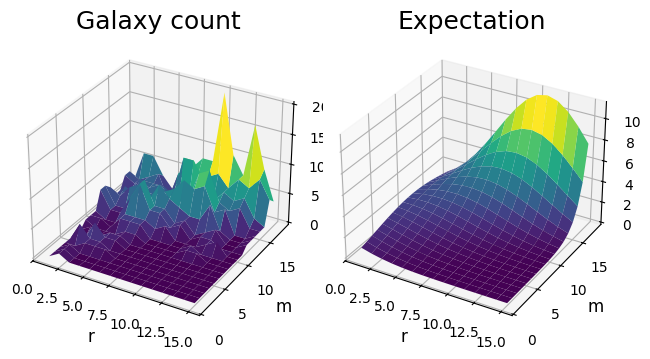

In [ ]:
# @title Poisson regression, galaxy count example {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import statsmodels.api as sm

# define data
Nr = 15;
Nm = 18;

yarray = np.array([
    [1, 6, 6, 3, 1, 4, 6, 8, 8, 20, 10, 7, 16, 9, 4],
    [3, 2, 3, 4, 0, 5, 7, 6, 6, 7, 5, 7, 6, 8, 5],
    [3, 2, 3, 3, 3, 2, 9, 9, 6, 3, 5, 4, 5, 2, 1],
    [1, 1, 4, 3, 4, 3, 2, 3, 8, 9, 4, 3, 4, 1, 1],
    [1, 3, 2, 3, 3, 4, 5, 7, 6, 7, 3, 4, 0, 0, 1],
    [3, 2, 4, 5, 3, 6, 4, 3, 2, 2, 5, 1, 0, 0, 1],
    [4, 1, 1, 4, 7, 3, 3, 1, 2, 0, 1, 2, 0, 0, 1],
    [4, 1, 1, 4, 7, 3, 3, 1, 2, 0, 1, 1, 0, 0, 0],
    [1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 0, 1, 2, 0, 0],
    [1, 1, 0, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

rrange = np.arange(1,Nr+1)
mrange = np.arange(Nm,0,-1)

rarray = np.tile( rrange, (18, 1) )
marray = np.tile( mrange, (15, 1) ).T


# flatten arrays

y = yarray.reshape(-1,1)
r = rarray.reshape(-1,1)
m = marray.reshape(-1,1)


# design matrix

X = np.hstack((r, m, r**2, r*m, m**2))

# Fit GLM with Poisson distribution, using STATSMODELS
model = sm.GLM(y, X, family=sm.families.Poisson(sm.families.links.Log()))
results = model.fit()

# Print summary of the model
print(results.summary())

alpha_sm = results.params

# Poisson regression by hand
# Define negative log-likelihood for Poisson distribution
def neg_log_likelihood(alpha, X, y):
    natparam = X @ alpha
    log_likelihood = y * natparam - np.exp(natparam)
    return -np.sum(log_likelihood)

# Initial guess
alpha_init = np.zeros(5)

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, alpha_init, args=(X, y), method='BFGS')

alpha_fit = results.params;

lambda_fit = X @ alpha_fit
mu_fit  = np.exp(lambda_fit)

y_fit = mu_fit.reshape(Nm,Nr)

# Compare parameter fits

print("Fitted params (sm):", alpha_sm)
print("Fitted params (LL):", alpha_fit)


# Visualize results
fig = plt.figure()

# Plot 1: Original counts
ax0 = fig.add_subplot(121, projection='3d')

ax0.plot_surface(rarray, marray, yarray, cmap='viridis')  # You can change colormap

ax0.set_xlabel('r', fontsize=12)
ax0.set_ylabel('m', fontsize=12)
ax0.set_title('Galaxy count', fontsize=18)

# Plot 2: Logistic fit
ax1 = fig.add_subplot(122, projection='3d')

ax1.plot_surface(rarray, marray, y_fit, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title('Expectation', fontsize=18)

plt.tight_layout()
plt.show()


# **Summary:**

**1. Linear regression**

**2. Ridge regression**

**3. Logistic regression**

**4. Generalized linear models**

**5. Gamma regression**

**6. Poisson regression**


# **Following lectures**

**Lecture 6: Bayes and bootstrap (Jochen Braun)**

**Lecture 7: Bootstrapping examples (Stepan Aleshin)**

**Lecture 8: GLM examples (Stepan Aleshin)**

**Lecture 9: Linear discriminant analysis (Jochen Braun)**

**Lecture 10: Multivariate LDA (Jochen Braun)**



